## Process Des Moines Lobe (DML) Landsat Panels to get NDVI values, plot histograms to check if values are as expected.

## 🌾 Landsat–Crop Data Integration for NDVI and Yield Analysis  
**Project:** NASA–UMRB Legacy Wetlands / Cropland Productivity Assessment  
**Author:** Kimberly Van Meter  
**Date:** October 2025  

---

### Overview

This notebook develops a reproducible, multi-stage workflow to quantify relationships between **satellite-derived vegetation indices** and **county-level crop yields** across the U.S. Upper Midwest.  
The analysis leverages **Landsat Surface Reflectance (SR)** data, **USDA Cropland Data Layer (CDL)** mosaics, and **USDA-NASS yield statistics** to connect remotely sensed greenness with agricultural productivity.

The workflow proceeds in three main phases:

1. **NDVI Computation and Seasonal Exploration**  
   - Generate NDVI from Landsat 5/7/8/9 SR imagery (May–September) using red and NIR bands.  
   - Summarize seasonal NDVI distributions to evaluate data quality and vegetation phenology.

2. **Cloud-Masked, QA-Filtered NDVI Products**  
   - Apply `QA_PIXEL` and `QA_RADSAT` masks to remove clouds, cirrus, shadows, snow, and sensor saturation.  
   - Produce monthly, spatially consistent NDVI mosaics suitable for quantitative analysis.

3. **Crop-Specific Masking and Yield Linkages**  
   - Align annual CDL mosaics with the NDVI grid.  
   - Create binary masks for **corn** and **soybean** pixels (and combined row-crop masks).  
   - Aggregate NDVI by crop and county, merge with NASS yield data, and explore NDVI–yield relationships.

---

### Goals

- Develop an **aligned, QA-filtered dataset** linking Landsat NDVI and county-level yields.  
- Examine how vegetation greenness metrics (mean, median, and high-percentile NDVI) vary by crop, year, and county.  
- Build a foundation for predictive models of yield based on remotely sensed vegetation indices and climate covariates.

---

### Expected Outcomes

By the end of this workflow, we will have:

- Annual, QA-masked NDVI rasters (2010–2021) for the Upper Midwest.  
- Corresponding corn and soybean crop masks aligned to NDVI pixels.  
- County-level datasets combining NDVI metrics and observed yields.  
- Diagnostic visualizations and exploratory models linking NDVI to agricultural performance.

---

This integrated approach will provide a spatially explicit, time-resolved view of crop productivity dynamics and support ongoing research on **wetland–agriculture interactions**, **landscape resilience**, and **nutrient legacy effects** within the NASA-UMRB Legacy Wetlands project.


### One-time path + I/O helpers

In [1]:
# ----- CONFIG: roots -----
from pathlib import Path
import os, sys, time, shutil
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

# Source (read-only): Google Drive
SRC_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))

# Destination (read/write): Conowingo
DST_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
DST_ROOT.mkdir(parents=True, exist_ok=True)

# Subfolders — READ from SRC, WRITE to DST
LANDSAT_SRC   = SRC_ROOT / "Landsat"    # read-only
CDL_SRC       = SRC_ROOT / "DML_2023" / "Cropscape" / "Upper_Midwest_006"  # read-only

NDVI_DST      = DST_ROOT / "NDVI"       # write
CROPMASK_DST  = DST_ROOT / "CropMasks"  # write
STAGE_CACHE   = DST_ROOT / ".stage_cache"  # local read-through cache for big sources
STAGE_CACHE.mkdir(parents=True, exist_ok=True)

# Reference grid lives on DST (so everything aligns to what we write)
REFERENCE_MASK_YEAR = 2016
REFERENCE_MASK_PATH = CROPMASK_DST / f"{REFERENCE_MASK_YEAR}" / f"CDL_{REFERENCE_MASK_YEAR}_corn_mask_uint8.tif"

# GDAL/Rasterio env for speed
GDAL_THREADS = "4"
GDAL_WARP_MB = 512  # working cache during warps

def log(msg):
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

def _human(n):
    for u in ["B","KB","MB","GB","TB"]:
        if n < 1024 or u == "TB":
            return f"{n:.1f} {u}" if u!="B" else f"{n} {u}"
        n /= 1024

def stage_src(src_path: Path) -> Path:
    """
    Ensure a source file is local. Copies once to STAGE_CACHE (same filename) with progress.
    Returns the local staged path. If src_path is already on a local (non-CloudStorage) volume,
    we just return src_path.
    """
    src_path = Path(src_path)
    s = str(src_path)
    if not src_path.exists():
        raise FileNotFoundError(f"Missing source file: {src_path}")
    # if it's already on Conowingo or elsewhere local, just use it directly
    if "/CloudStorage/GoogleDrive" not in s and "/My Drive/" not in s:
        return src_path

    dst = STAGE_CACHE / src_path.name
    try:
        src_sz = src_path.stat().st_size
    except Exception:
        # Drive placeholder can throw; try copy anyway to trigger hydration
        src_sz = None

    if dst.exists():
        # If we can compare sizes and they match, reuse cache
        if src_sz is None or dst.stat().st_size == src_sz:
            return dst

    # Chunked copy with progress
    log(f"Staging → {dst.name}")
    chunk = 16 * 1024 * 1024
    copied = 0; t0 = time.time()
    with open(src_path, "rb") as fi, open(dst, "wb") as fo:
        while True:
            buf = fi.read(chunk)
            if not buf: break
            fo.write(buf)
            copied += len(buf)
            if src_sz:
                pct = 100.0 * copied / src_sz
                rate = (copied/1024/1024) / max(time.time()-t0, 1e-6)
                print(f"\r  {pct:5.1f}%  {_human(copied):>8} / {_human(src_sz):<8}  ~{rate:5.1f} MB/s", end="")
            else:
                print(f"\r  {_human(copied)} copied…", end="")
            sys.stdout.flush()
    print()
    try:
        shutil.copystat(src_path, dst)
    except Exception:
        pass
    log(f"Staged: {dst.name}")
    return dst

def get_ref_profile():
    if not REFERENCE_MASK_PATH.exists():
        raise FileNotFoundError(f"Reference mask not found on DST: {REFERENCE_MASK_PATH}")
    with rasterio.open(REFERENCE_MASK_PATH) as ds:
        return {
            "driver":"GTiff","height":ds.height,"width":ds.width,"count":1,
            "dtype":"uint8","crs":ds.crs,"transform":ds.transform,
            "compress":"lzw","tiled":True,"blockxsize":512,"blockysize":512,
            "nodata":255,"BIGTIFF":"YES",
        }


### 🛰️ Step 1: Generate Crop-Specific Binary Masks (Corn and Soybean)

In this step, we prepare crop-scale data layers from the **USDA Cropland Data Layer (CDL)** mosaics so they align with the Landsat-based **NDVI** datasets generated earlier.  
Each CDL raster is categorical, containing integer class codes that represent land cover and crop types.

We will:

1. **Locate and reproject** each annual CDL mosaic (2010–2021) to exactly match the spatial reference, grid, and extent of the corresponding **July NDVI** raster for the same year.  
   - This ensures that NDVI and crop data are pixel-aligned for subsequent analyses.

2. **Extract binary masks** for the dominant agricultural crops of interest:  
   - 🌽 **Corn** → `CDL code = 1`  
   - 🌱 **Soybeans** → `CDL code = 5`  
   Pixels of the target crop are assigned a value of `1`; all other valid pixels are assigned `0`; nodata areas are coded as `255`.

3. **(Optional)** Generate a combined *row-crop* mask where any pixel classified as either corn or soybeans is marked as `1`.

4. **Export the masks** as tiled, LZW-compressed GeoTIFFs (`uint8`) to a standardized output folder.  
   These will serve as crop-specific spatial filters for computing county-level NDVI statistics in later steps.

---

✅ **Output:**  
For each year (2010–2021), the script produces:
- `CDL_<year>_corn_mask_uint8.tif`  
- `CDL_<year>_soy_mask_uint8.tif`  
- *(optional)* `CDL_<year>_cornORsoy_mask_uint8.tif`

These annual, crop-specific masks are perfectly aligned with NDVI scenes and ready for quantifying **NDVI–yield relationships** across counties and years.


In [3]:
#!/usr/bin/env python3
# make_cdl_crop_masks_bootstrap_ref.py
# 1) Make 2016 corn mask first (defines the fixed grid)
# 2) Reproject all other years to that grid and write masks (corn, soy, optional combined)
# Outputs ONLY to Conowingo.
# Author: Kimberly Van Meter
# Date: 2025-11-08

from pathlib import Path
import csv, time
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
import os

# =====================
# USER SETTINGS
# =====================
YEARS = [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
REF_YEAR = 2016  # bootstrap fixed grid from this year’s CDL

# CDL source (read-only)
CDL_DIR = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "DML_2023/Cropscape/Upper_Midwest_006/"

# OUTPUTS (Conowingo only)
OUT_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "CropMasks"

# CDL class codes
CDL_CODES = {"corn": 1, "soybeans": 5}

# nodata + flags
MASK_NODATA = 255
WRITE_COMBINED_ROW_CROPS = True

# performance
NUM_THREADS = 8
WARP_MEM_MB = 1024  # MB

# =====================
# HELPERS
# =====================
def log(msg: str) -> None:
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

def find_cdl(year: int) -> Path:
    p = CDL_DIR / f"CDL_{year}_006" / f"CDL_{year}_006.tif"
    if p.exists():
        return p
    ydir = CDL_DIR / f"CDL_{year}_006"
    for q in sorted(ydir.glob("*.tif")):
        return q
    raise FileNotFoundError(f"No CDL .tif found for {year} under {CDL_DIR}")

def make_binary(cdl: np.ndarray, code: int) -> np.ndarray:
    out = np.full_like(cdl, MASK_NODATA, dtype=np.uint8)
    valid = cdl != MASK_NODATA
    out[valid] = (cdl[valid] == code).astype(np.uint8)
    return out

def write_tif(path: Path, arr: np.ndarray, prof: dict, desc: str, year: int) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(arr, 1)
        dst.update_tags(
            CREATED_BY="make_cdl_crop_masks_bootstrap_ref.py",
            DESC=desc,
            YEAR=str(year),
            CDL_CORN=str(CDL_CODES["corn"]),
            CDL_SOY=str(CDL_CODES["soybeans"]),
        )
        dst.build_overviews([2, 4, 8, 16, 32], Resampling.nearest)
        dst.update_tags(ns="rio_overview", resampling="nearest")

def profile_from_src_like_uint8(src) -> dict:
    return {
        "driver": "GTiff",
        "height": src.height,
        "width": src.width,
        "count": 1,
        "dtype": "uint8",
        "crs": src.crs,
        "transform": src.transform,
        "compress": "lzw",
        "tiled": True,
        "blockxsize": 512,
        "blockysize": 512,
        "nodata": MASK_NODATA,
        "BIGTIFF": "YES",
    }

def reproject_to_profile(src_path: Path, ref_prof: dict) -> np.ndarray:
    with rasterio.open(src_path) as src:
        same_grid = (
            src.crs == ref_prof["crs"]
            and src.transform == ref_prof["transform"]
            and src.width == ref_prof["width"]
            and src.height == ref_prof["height"]
        )
        if same_grid:
            arr = src.read(1)
            nd = src.nodata if src.nodata is not None else 0
            out = arr.astype(np.uint16, copy=False)
            out[(out == nd) | (out == 255) | (out < 0)] = MASK_NODATA
            return out.astype(np.uint8, copy=False)

        dst = np.full((ref_prof["height"], ref_prof["width"]), MASK_NODATA, dtype=np.uint8)
        src_nd = src.nodata if src.nodata is not None else 0
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_prof["transform"],
            dst_crs=ref_prof["crs"],
            dst_width=ref_prof["width"],
            dst_height=ref_prof["height"],
            resampling=Resampling.nearest,
            src_nodata=src_nd,
            dst_nodata=MASK_NODATA,
            num_threads=NUM_THREADS,
            warp_mem_limit=WARP_MEM_MB * 1024 * 1024,
        )
        dst[(dst == 255) | (dst.astype(np.int32) < 0)] = MASK_NODATA
        return dst

# =====================
# MAIN
# =====================
def main():
    OUT_ROOT.mkdir(parents=True, exist_ok=True)

    # --- Step 1: Ensure the reference grid exists by building the 2016 corn mask first ---
    ref_corn_path = OUT_ROOT / f"{REF_YEAR}" / f"CDL_{REF_YEAR}_corn_mask_uint8.tif"
    if ref_corn_path.exists():
        # Load its profile as the fixed grid
        with rasterio.open(ref_corn_path) as ref_ds:
            ref_prof = profile_from_src_like_uint8(ref_ds)
        log(f"Using existing reference grid from {ref_corn_path}")
    else:
        # Build corn mask on the native 2016 CDL grid (no reprojection) → defines fixed grid
        log(f"Reference corn mask not found. Bootstrapping from {REF_YEAR} CDL …")
        cdl_ref_path = find_cdl(REF_YEAR)
        with rasterio.open(cdl_ref_path) as src:
            ref_prof = profile_from_src_like_uint8(src)
            arr = src.read(1)
            nd = src.nodata if src.nodata is not None else 0
            arr_u = arr.astype(np.uint16, copy=False)
            arr_u[(arr_u == nd) | (arr_u == 255) | (arr_u < 0)] = MASK_NODATA
            cdl_ref = arr_u.astype(np.uint8, copy=False)

        corn_ref = make_binary(cdl_ref, CDL_CODES["corn"])
        write_tif(
            ref_corn_path,
            corn_ref,
            ref_prof,
            "1=corn, 0=other, 255=nodata (reference grid)",
            REF_YEAR,
        )
        log(f"[OK] Wrote reference mask → {ref_corn_path}")

        # Optionally also write soy/combined for ref year now (handy for completeness)
        ref_dir = ref_corn_path.parent
        soy_ref = make_binary(cdl_ref, CDL_CODES["soybeans"])
        write_tif(
            ref_dir / f"CDL_{REF_YEAR}_soy_mask_uint8.tif",
            soy_ref,
            ref_prof,
            "1=soybeans, 0=other, 255=nodata",
            REF_YEAR,
        )
        if WRITE_COMBINED_ROW_CROPS:
            combo = np.full_like(cdl_ref, MASK_NODATA, dtype=np.uint8)
            valid = cdl_ref != MASK_NODATA
            combo[valid] = (
                (cdl_ref[valid] == CDL_CODES["corn"])
                | (cdl_ref[valid] == CDL_CODES["soybeans"])
            ).astype(np.uint8)
            write_tif(
                ref_dir / f"CDL_{REF_YEAR}_cornORsoy_mask_uint8.tif",
                combo,
                ref_prof,
                "1=corn or soy, 0=other, 255=nodata",
                REF_YEAR,
            )

    # --- Step 2: Generate masks for all years on the fixed grid ---
    qc_rows = [["year", "corn_pct", "soy_pct", "valid_pct"]]

    with rasterio.Env(GDAL_NUM_THREADS=str(NUM_THREADS), GDAL_CACHEMAX=WARP_MEM_MB):
        for year in YEARS:
            out_dir = OUT_ROOT / f"{year}"
            corn_path = out_dir / f"CDL_{year}_corn_mask_uint8.tif"
            soy_path = out_dir / f"CDL_{year}_soy_mask_uint8.tif"
            combo_path = out_dir / f"CDL_{year}_cornORsoy_mask_uint8.tif"

            # --- Skip year if everything we need is already there ---
            have_corn = corn_path.exists()
            have_soy = soy_path.exists()
            have_combo = (not WRITE_COMBINED_ROW_CROPS) or combo_path.exists()

            if have_corn and have_soy and have_combo:
                log(f"[{year}] All masks already exist. Skipping.")
                continue

            # --- Otherwise, do the usual work ---
            cdl_path = find_cdl(year)
            log(f"[{year}] Reprojecting {cdl_path.name} → fixed grid (defined by {REF_YEAR}) …")
            cdl_on_grid = reproject_to_profile(cdl_path, ref_prof)

            corn = make_binary(cdl_on_grid, CDL_CODES["corn"])
            soy = make_binary(cdl_on_grid, CDL_CODES["soybeans"])

            out_dir.mkdir(parents=True, exist_ok=True)

            # For REF_YEAR corn, keep your existing 'don't overwrite' behavior
            if not (year == REF_YEAR and corn_path.exists()):
                write_tif(
                    corn_path,
                    corn,
                    ref_prof,
                    "1=corn, 0=other, 255=nodata",
                    year,
                )
            if not soy_path.exists():
                write_tif(
                    soy_path,
                    soy,
                    ref_prof,
                    "1=soybeans, 0=other, 255=nodata",
                    year,
                )

            if WRITE_COMBINED_ROW_CROPS:
                combo = np.full_like(cdl_on_grid, MASK_NODATA, dtype=np.uint8)
                valid = cdl_on_grid != MASK_NODATA
                combo[valid] = (
                    (cdl_on_grid[valid] == CDL_CODES["corn"])
                    | (cdl_on_grid[valid] == CDL_CODES["soybeans"])
                ).astype(np.uint8)
                if not combo_path.exists():
                    write_tif(
                        combo_path,
                        combo,
                        ref_prof,
                        "1=corn or soy, 0=other, 255=nodata",
                        year,
                    )

            # QC
            valid = cdl_on_grid != MASK_NODATA
            valid_pct = 100.0 * (valid.mean() if valid.any() else 0.0)
            corn_pct = 100.0 * ((corn[valid] == 1).mean() if valid.any() else 0.0)
            soy_pct = 100.0 * ((soy[valid] == 1).mean() if valid.any() else 0.0)
            log(
                f"[QC] {year}: valid={valid_pct:.2f}% | "
                f"corn={corn_pct:.2f}% | soy={soy_pct:.2f}%"
            )
            qc_rows.append(
                [year, f"{corn_pct:.3f}", f"{soy_pct:.3f}", f"{valid_pct:.3f}"]
            )

    qc_csv = OUT_ROOT / "cropmask_qc_summary.csv"
    with open(qc_csv, "w", newline="") as f:
        csv.writer(f).writerows(qc_rows)
    log(f"[QC] Wrote summary → {qc_csv}")

if __name__ == "__main__":
    main()


[2025-11-19 11:55:23] Using existing reference grid from /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/CropMasks/2016/CDL_2016_corn_mask_uint8.tif
[2025-11-19 11:55:23] [2003] Reprojecting CDL_2003_006.tif → fixed grid (defined by 2016) …
[2025-11-19 11:55:34] [QC] 2003: valid=34.19% | corn=20.78% | soy=16.32%
[2025-11-19 11:55:34] [2004] Reprojecting CDL_2004_006.tif → fixed grid (defined by 2016) …
[2025-11-19 11:55:50] [QC] 2004: valid=34.17% | corn=21.16% | soy=16.61%
[2025-11-19 11:55:50] [2005] Reprojecting CDL_2005_006.tif → fixed grid (defined by 2016) …
[2025-11-19 11:56:06] [QC] 2005: valid=34.25% | corn=20.26% | soy=15.96%
[2025-11-19 11:56:06] [2006] Reprojecting CDL_2006_006.tif → fixed grid (defined by 2016) …
[2025-11-19 11:56:22] [QC] 2006: valid=59.99% | corn=18.10% | soy=15.36%
[2025-11-19 11:56:22] [2007] Reprojecting CDL_2007_006.tif → fixed grid (defined by 2016) …
[2025-11-19 11:56:37] [QC] 2007: valid=59.99% | corn=19.03% | soy=11.94%
[2025-11-19 11:56:37] [2008] 

### Visualizing Annual Corn and Soy Crop Masks for Iowa

This script generates a two-panel figure to visualize **annual crop mask rasters** for Iowa, showing the spatial distribution of **corn** and **soybean** areas for a selected year.  

The script reads the 30 m **corn** and **soybean** mask GeoTIFFs produced from the USDA Cropland Data Layer (CDL) and overlays them with Iowa’s state and county boundaries for context.

---

#### **Processing Steps**

1. **Load Yearly Crop Masks**
   - Reads the annual corn and soybean mask rasters from the project’s `CropMasks/<year>/` directory.  
   - Each raster is a binary (0/1) mask where pixels equal to 1 represent the target crop (corn or soy).

2. **Build RGB Composite**
   - Combines the two binary masks into a single RGB visualization:
     - **Yellow:** Corn  
     - **Green:** Soybeans  
     - **Purple:** Other (non-corn, non-soy)  
   - Transparent areas represent `NoData` pixels outside the state extent.

3. **Load Geographic Boundaries**
   - Loads the Iowa state and county shapefiles (local or Census TIGER/Line 2018 boundary data).  
   - Reprojects boundaries to match the raster CRS for accurate overlay.

4. **Plot Panels**
   - **Left Panel:**  
     Displays the detailed corn/soy mask with county and state boundaries for spatial reference.  
     A legend identifies the crop color classes.
   - **Right Panel:**  
     Provides statewide context showing the raster’s geographic footprint (red box) within Iowa.

5. **Output**
   - Displays a side-by-side visualization suitable for quick inspection or inclusion in figures documenting the crop mask generation process.

---

#### **Purpose**

This visualization allows rapid verification that:
- Crop masks are correctly aligned to the Iowa extent.  
- Corn and soybean distributions are consistent with expected spatial patterns.  
- Raster footprints and boundaries match across years.

It serves as a **visual QA step** in the Legacy Wetlands workflow to confirm spatial consistency of the annual CDL-based crop mask layers.


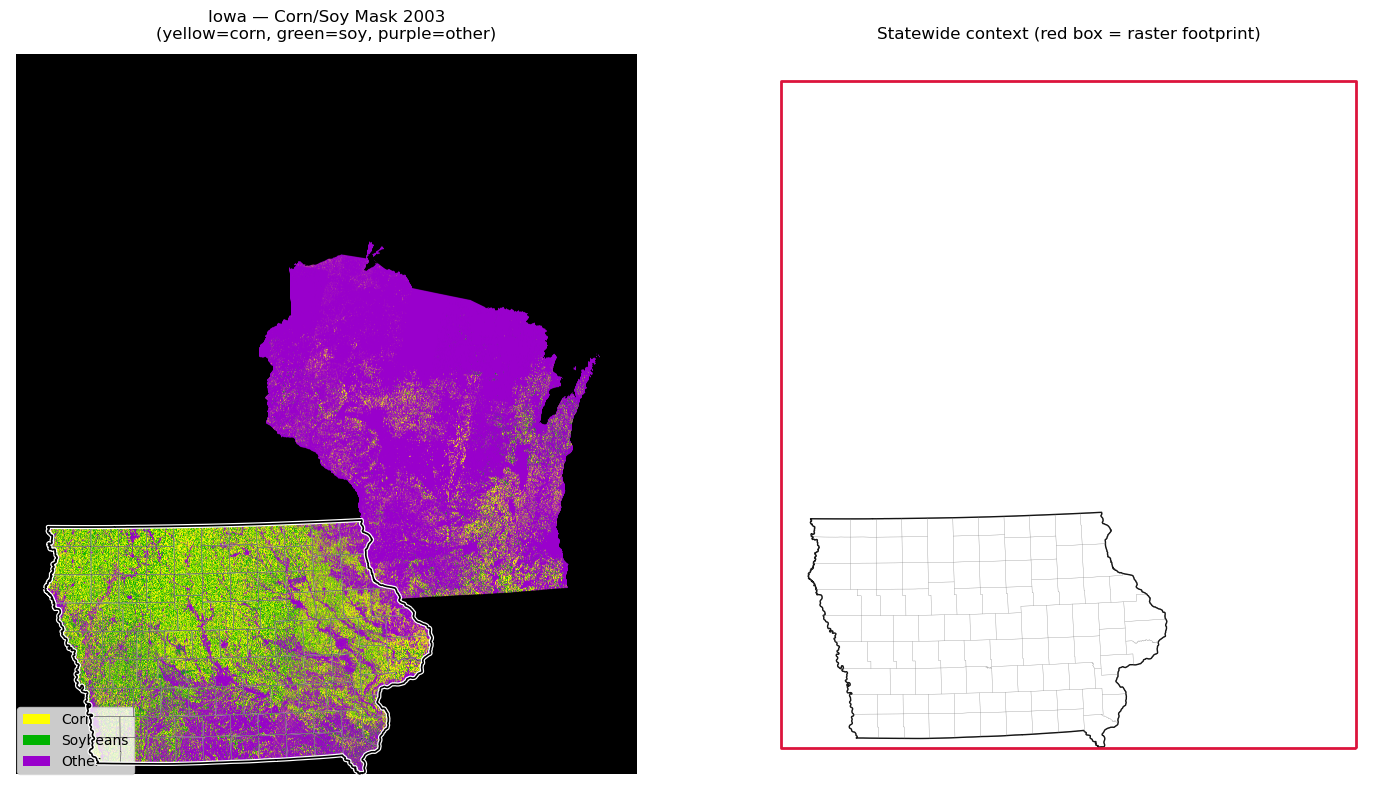

In [1]:
# --- Visualize corn/soy crop masks for a selected YEAR with Iowa context ---

from pathlib import Path
import numpy as np
import rasterio
from rasterio.plot import plotting_extent
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ============ USER SETTINGS ============
YEAR = 2003  # <-- change to any processed year
CROPMASK_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "CropMasks"

# Optional: if you have a local Iowa state/county file, set paths here (else it will download TIGER cartography)
IOWA_STATE_PATH  = Path('$DML_NDVI_DATA_ROOT/Shapefiles/cb_2018_us_state_500k/cb_2018_us_state_500k.shp')
IOWA_COUNTY_PATH = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "Shapefiles/cb_2018_us_county_500k/cb_2018_us_county_500k.shp"
# ======================================

# Colors
CLR_CORN   = (1.0, 1.0, 0.0)   # yellow
CLR_SOY    = (0.0, 0.7, 0.0)   # green
CLR_OTHER  = (0.6, 0.0, 0.8)   # purple

# Load masks
year_dir = CROPMASK_ROOT / f"{YEAR}"
corn_path = year_dir / f"CDL_{YEAR}_corn_mask_uint8.tif"
soy_path  = year_dir / f"CDL_{YEAR}_soy_mask_uint8.tif"

if not corn_path.exists() or not soy_path.exists():
    raise FileNotFoundError(f"Missing corn/soy masks for {YEAR} under {year_dir}")

with rasterio.open(corn_path) as ds:
    corn   = ds.read(1)
    nodata = ds.nodata
    r_crs  = ds.crs
    extent = plotting_extent(ds)  # (minx, maxx, miny, maxy)

with rasterio.open(soy_path) as ds:
    soy = ds.read(1)

# Build RGB + alpha (transparent where nodata)
rgb = np.zeros((corn.shape[0], corn.shape[1], 3), dtype="float32")
valid    = (corn != nodata) & (soy != nodata)
is_corn  = (corn == 1) & valid
is_soy   = (soy  == 1) & valid
is_other = (~is_corn & ~is_soy) & valid

rgb[is_corn]  = CLR_CORN
rgb[is_soy]   = CLR_SOY
rgb[is_other] = CLR_OTHER

alpha = np.zeros(corn.shape, dtype="float32")
alpha[valid] = 1.0

# Iowa boundaries (state + counties)
def load_iowa_layers():
    if IOWA_STATE_PATH and Path(IOWA_STATE_PATH).exists():
        iowa = gpd.read_file(IOWA_STATE_PATH)
        # If this is a US states layer, filter to Iowa
        if "NAME" in iowa.columns:
            iowa = iowa[iowa["NAME"].str.lower().eq("iowa")].copy()
    else:
        # Census cartographic boundary 1:500k (small, quick)
        states_url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip"
        iowa = gpd.read_file(states_url)
        iowa = iowa[iowa["NAME"].str.lower().eq("iowa")].copy()

    if IOWA_COUNTY_PATH and Path(IOWA_COUNTY_PATH).exists():
        counties = gpd.read_file(IOWA_COUNTY_PATH)
        # If full US counties provided, filter to Iowa by FIPS or NAME
        if "STATEFP" in counties.columns:
            counties = counties[counties["STATEFP"] == "19"].copy()
        elif "STATE_NAME" in counties.columns:
            counties = counties[counties["STATE_NAME"].str.lower().eq("iowa")].copy()
    else:
        counties_url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_500k.zip"
        counties = gpd.read_file(counties_url)
        counties = counties[counties["STATEFP"] == "19"].copy()  # 19 = Iowa

    return iowa, counties

iowa, iowa_cnt = load_iowa_layers()
# Ensure CRS matches raster
if iowa.crs is None:
    iowa = iowa.set_crs("EPSG:4326", allow_override=True)
iowa = iowa.to_crs(r_crs)
iowa_cnt = iowa_cnt.to_crs(r_crs)

# Raster footprint polygon
rast_bbox = box(extent[0], extent[2], extent[1], extent[3])
rast_gdf  = gpd.GeoDataFrame(geometry=[rast_bbox], crs=r_crs)

# Figure: Left detailed panel (raster + counties + state border), Right statewide context (red footprint)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# (A) Detailed raster panel
ax1.imshow(rgb, extent=extent, origin="upper", zorder=1)
# County boundaries for internal context
iowa_cnt.boundary.plot(ax=ax1, linewidth=0.4, edgecolor="white", alpha=0.9, zorder=5)
iowa_cnt.boundary.plot(ax=ax1, linewidth=0.2, edgecolor="black", alpha=0.9, zorder=6)
# State border (double stroke)
iowa.boundary.plot(ax=ax1, linewidth=3.0, edgecolor="white", zorder=7)
iowa.boundary.plot(ax=ax1, linewidth=1.2, edgecolor="black", zorder=8)

# Small padding so state border is visible even if footprint touches edges
padx = 0.01 * (extent[1] - extent[0])
pady = 0.01 * (extent[3] - extent[2])
ax1.set_xlim(extent[0] - padx, extent[1] + padx)
ax1.set_ylim(extent[2] - pady, extent[3] + pady)
ax1.set_title(f"Iowa — Corn/Soy Mask {YEAR}\n(yellow=corn, green=soy, purple=other)")
ax1.set_axis_off()

# Legend (manual)
legend_patches = [
    Patch(facecolor=CLR_CORN,   edgecolor='none', label='Corn'),
    Patch(facecolor=CLR_SOY,    edgecolor='none', label='Soybeans'),
    Patch(facecolor=CLR_OTHER,  edgecolor='none', label='Other'),
]
ax1.legend(handles=legend_patches, loc="lower left", frameon=True)

# (B) Statewide context with raster footprint
iowa.plot(ax=ax2, facecolor="none", edgecolor="black", linewidth=1.0)
iowa_cnt.boundary.plot(ax=ax2, linewidth=0.2, edgecolor="gray", alpha=0.6)
rast_gdf.boundary.plot(ax=ax2, edgecolor="crimson", linewidth=2.0)
ax2.set_title("Statewide context (red box = raster footprint)")
ax2.set_aspect("equal")
ax2.set_axis_off()

plt.tight_layout()
plt.show()


### 🛰️ Step 2: Generate Statewide Monthly NDVI MAX Mosaics

This script processes **Landsat Collection 2 Level-2 Surface Reflectance** scenes to produce statewide, grid-aligned **monthly maximum NDVI composites** for July and August (or other months, as configured).  

Each mosaic is snapped exactly to the **2016 CDL corn mask grid**, ensuring consistent alignment with crop and land-use datasets.

#### **Workflow Summary**

1. **Locate and Read Scenes**
   - Scans Landsat scene directories by year (`YYYY`) and month (`MM`) under the regional root (e.g., `.../Landsat/Iowa/2016/2016_07_Landsat_SCENES/`).
   - Supports both *L2SP* (`*_red.TIF`, `*_nir08.TIF`) and *ARD* (`_SR_B3/B4/B5.TIF`) naming conventions.
   - Optionally reads QA_PIXEL bands for cloud/shadow masking.

2. **Compute Per-Scene NDVI**
   - Converts red and NIR bands to surface reflectance using USGS scaling factors (`SR_SCALE = 0.0000275`, `SR_OFFSET = -0.2`).
   - Calculates NDVI = (NIR − RED) / (NIR + RED) for each pixel.
   - Writes each per-scene NDVI raster (`float32`, `tiled`, `deflate`-compressed) to a temporary folder:
     ```
     /analysis/NDVI/{YEAR}/{YEAR}_{MONTH}_MAX/scenes_ndvi/
     ```

3. **Create Monthly MAX Mosaic**
   - All per-scene NDVI rasters for the month are resampled using `WarpedVRT` to **exactly match the 2016 CDL reference grid**.
   - A mosaic is created using pixel-wise maximum values across scenes (`method="max"`), yielding a cloud-minimized composite.
   - The output statewide mosaic is saved as:
     ```
     /NDVI/{YEAR}/{YEAR}_{MONTH}_MAX/NDVI_{YEAR}_{MONTH}_MAX_MOSAIC.tif
     ```
   - Overviews (pyramids) are built for faster visualization.

4. **Output Details**
   - Output CRS: matches 2016 CDL grid (Albers Equal Area, EPSG:5070).
   - Output type: `float32`, NDVI range −1.0 to +1.0.
   - Compression: `DEFLATE` with internal tiling (512×512).
   - Optional QA filtering and nodata handling are built in.

#### **Purpose**

These mosaics provide **cloud-free monthly maximum NDVI layers** at statewide scale, aligned to CDL-based crop masks.  
They form the core remote sensing dataset for evaluating vegetation productivity and crop performance in the **Des Moines Lobe Legacy Wetlands** analysis.

**Author:** Kimberly Van Meter  
**Last Updated:** November 10, 2025


In [2]:

#!/usr/bin/env python3
# NDVI & EVI2 monthly MAX composites from Landsat L2 scenes (no panel layer) + statewide mosaics
# Author: Kimberly Van Meter 
# Updated: 2025-11-10 — supports "*_red.TIF/*_nir08.TIF" scene layout; snaps mosaics to 2016 CDL grid
# Updated: 2025-11-15 — adds EVI2 computation and mosaics (minimal changes)

from pathlib import Path
import re
import numpy as np
import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.vrt import WarpedVRT
from rasterio.warp import Resampling
import warnings
import os

# ---------------------
# USER SETTINGS
# ---------------------
REGION_LS   = "Iowa"
YEARS       = [2018]
MONTHS      = ["09"]
LANDSAT_DIR = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "Landsat"

# Outputs
NDVI_OUT_ROOT     = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI"
SCENES_OUT_SUBDIR = "scenes_ndvi"  # per-scene indices go here before mosaicking

# Reference grid (2016 CDL corn mask) — used to snap mosaic exactly
REF_MASK_PATH = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "CropMasks/2016/CDL_2016_corn_mask_uint8.tif"

# Surface reflectance scaling (USGS C2 SR)
APPLY_SR_SCALE = True
SR_SCALE  = 0.0000275
SR_OFFSET = -0.2

# QA usage
USE_QA_MASK      = False
ALLOW_MISSING_QA = True

# File sanity
MIN_VALID_BYTES = 8192

# Index controls
COMPUTE_EVI2 = True

# Nodata (numeric, more robust than NaN)
NODATA_VAL = -9999.0

# ---------------------
# HELPERS
# ---------------------
SCENE_RE = re.compile(r'^(LT\d{2}|LE\d{2}|LC0[89])', re.IGNORECASE)


def load_ref_grid(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Reference mask not found: {path}")
    with rasterio.open(path) as ref:
        return {
            "crs": ref.crs,
            "transform": ref.transform,
            "width": ref.width,
            "height": ref.height,
        }


def list_real_files(d: Path):
    out = []
    if not d.exists():
        return out
    for f in d.iterdir():
        if not f.is_file():
            continue
        n = f.name
        if n.startswith(".") or n.startswith("._"):
            continue
        if not n.lower().endswith((".tif", ".tiff")):
            continue
        try:
            if f.stat().st_size < MIN_VALID_BYTES:
                continue
        except Exception:
            continue
        out.append(f)
    return out


def to_reflectance(arr):
    return (arr.astype("float32") * SR_SCALE) + SR_OFFSET


def compute_ndvi(red, nir):
    num = nir - red
    den = nir + red
    with np.errstate(divide="ignore", invalid="ignore"):
        ndvi = np.where(den == 0, np.nan, num / den)
    return ndvi.astype("float32")


def compute_evi2(red, nir):
    """EVI2 = 2.5 * (NIR - RED) / (NIR + 2.4*RED + 1)."""
    red = red.astype("float32", copy=False)
    nir = nir.astype("float32", copy=False)
    with np.errstate(divide="ignore", invalid="ignore"):
        evi2 = 2.5 * (nir - red) / (nir + 2.4 * red + 1.0)
    return evi2.astype("float32")


def is_geotiff_ok(path: Path) -> bool:
    try:
        with rasterio.open(path) as ds:
            _ = ds.read(1, out_shape=(1, 1, 1))
        return True
    except Exception:
        return False


def qa_mask_from_qapixel(qa_arr):
    qa_arr = qa_arr.astype(np.uint16)
    cloud  = (qa_arr & (1 << 3)) != 0
    shadow = (qa_arr & (1 << 4)) != 0
    cirrus = (qa_arr & (1 << 5)) != 0
    snow   = (qa_arr & (1 << 6)) != 0
    return (cloud | shadow | cirrus | snow)


def pick_band(files, suffixes):
    for fn in files:
        l = fn.lower()
        for suf in suffixes:
            if l.endswith(suf):
                return fn
    return None


def scene_band_paths(scene_dir: Path):
    """
    Return (red_path, nir_path, qa_path) for a single scene folder.
    Supports:
      - L2SP '*_red.TIF' + '*_nir08.TIF' (+ '*_qa_pixel.TIF')
      - ARD  '..._SR_B3/4/5.TIF' (+ '..._QA_PIXEL.TIF')
    """
    files = [f.name for f in list_real_files(scene_dir)]
    if not files:
        return None, None, None

    # Prefer explicit L2SP naming
    red_name = pick_band(files, ("_red.tif", "_red.tiff"))
    nir_name = pick_band(files, ("_nir08.tif", "_nir08.tiff"))
    qa_name  = pick_band(files, ("_qa_pixel.tif", "_qa_pixel.tiff"))

    # Fallback to ARD SR_B* scheme
    if red_name is None or nir_name is None:
        r_alt = pick_band(files, ("_sr_b3.tif", "_sr_b3.tiff"))
        n_alt = pick_band(files, ("_sr_b4.tif", "_sr_b4.tiff"))
        if r_alt and n_alt:
            red_name, nir_name = r_alt, n_alt
        else:
            r_alt = pick_band(files, ("_sr_b4.tif", "_sr_b4.tiff"))
            n_alt = pick_band(files, ("_sr_b5.tif", "_sr_b5.tiff"))
            if r_alt and n_alt:
                red_name, nir_name = r_alt, n_alt

    if red_name is None or nir_name is None:
        return None, None, None

    red = scene_dir / red_name
    nir = scene_dir / nir_name
    qa  = (scene_dir / qa_name) if qa_name else None

    if red and not is_geotiff_ok(red):
        red = None
    if nir and not is_geotiff_ok(nir):
        nir = None
    if qa and not is_geotiff_ok(qa):
        qa = None

    return red, nir, qa


def walk_scene_dirs(month_root: Path):
    """
    Yield scene_dir for any directory directly under month_root that contains .tif files.
    Also handle the (rare) case of files directly under month_root.
    """
    if not month_root.exists():
        return
    any_files = list_real_files(month_root)
    if any_files:
        yield month_root
    for child in month_root.iterdir():
        if child.is_dir() and list_real_files(child):
            yield child


# ---------------------
# MAIN
# ---------------------
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)

for y in YEARS:
    for m in MONTHS:
        month_root = LANDSAT_DIR / REGION_LS / f"{y}" / f"{y}_{m}_Landsat_SCENES"
        if not month_root.exists():
            print(f"[WARN] Missing {month_root}")
            continue

        print(f"\n[RUN] {y}-{m}  scanning scenes under: {month_root}")
        out_root_month = NDVI_OUT_ROOT / f"{y}" / f"{y}_{m}_MAX"
        scene_idx_dir  = out_root_month / SCENES_OUT_SUBDIR
        scene_idx_dir.mkdir(parents=True, exist_ok=True)

        ndvi_scene_paths = []
        evi2_scene_paths = []
        scenes_used = 0
        scenes_skipped = 0

        # ---- Per-scene indices ----
        for scene_dir in walk_scene_dirs(month_root):
            red_path, nir_path, qa_path = scene_band_paths(scene_dir)
            if not (red_path and nir_path):
                scenes_skipped += 1
                continue

            try:
                with rasterio.open(red_path) as rds, rasterio.open(nir_path) as nds:
                    red = rds.read(1)
                    nir = nds.read(1)

                    # nodata → NaN
                    if rds.nodata is not None:
                        red = np.where(red == rds.nodata, np.nan, red)
                    if nds.nodata is not None:
                        nir = np.where(nir == nds.nodata, np.nan, nir)

                    # optional QA
                    if USE_QA_MASK and (qa_path is not None or ALLOW_MISSING_QA):
                        qa_mask = None
                        if qa_path is not None:
                            with rasterio.open(qa_path) as qds:
                                qa = qds.read(1)
                            qa_mask = qa_mask_from_qapixel(qa)
                        if qa_mask is not None:
                            red = np.where(qa_mask, np.nan, red)
                            nir = np.where(qa_mask, np.nan, nir)

                    # scale to reflectance (if desired)
                    if APPLY_SR_SCALE:
                        red = to_reflectance(red)
                        nir = to_reflectance(nir)

                    # indices
                    ndvi = compute_ndvi(red, nir)
                    if COMPUTE_EVI2:
                        evi2 = compute_evi2(red, nir)

                    # write per-scene NDVI/EVI2 (for mosaicking)
                    profile = rds.profile
                    profile.update(
                        dtype="float32",
                        count=1,
                        nodata=NODATA_VAL,
                        tiled=True,
                        blockxsize=512,
                        blockysize=512,
                        compress="deflate",
                        predictor=2,
                        zlevel=6,
                        BIGTIFF="IF_SAFER",
                    )

                    ndvi_path = scene_idx_dir / f"{scene_dir.name}_NDVI.tif"
                    with rasterio.open(ndvi_path, "w", **profile) as w:
                        w.write(ndvi, 1)
                    ndvi_scene_paths.append(ndvi_path)

                    if COMPUTE_EVI2:
                        evi2_path = scene_idx_dir / f"{scene_dir.name}_EVI2.tif"
                        with rasterio.open(evi2_path, "w", **profile) as w:
                            w.write(evi2, 1)
                        evi2_scene_paths.append(evi2_path)

                    scenes_used += 1

            except Exception as e:
                print(f"[ERROR] {scene_dir.name}: {e}")
                scenes_skipped += 1

        print(f"[SUMMARY] {y}-{m}: scenes used={scenes_used} | scenes skipped={scenes_skipped}")
        print(f"[DEBUG] {y}-{m}: NDVI scenes={len(ndvi_scene_paths)}, EVI2 scenes={len(evi2_scene_paths)}")

        # ---- Monthly MAX mosaic builder ----
        def build_mosaic(per_scene_paths, index_name):
            if not per_scene_paths:
                print(f"[WARN] No per-scene {index_name} written for {y}-{m}; skipping {index_name} mosaic.")
                return

            ref = load_ref_grid(REF_MASK_PATH)  # exact CRS/transform/size of 2016 grid
            vrt_srcs = []
            try:
                for p in per_scene_paths:
                    src = rasterio.open(p)
                    # Build a VRT that *directly* matches the reference grid
                    vrt = WarpedVRT(
                        src,
                        crs=ref["crs"],
                        transform=ref["transform"],
                        width=ref["width"],
                        height=ref["height"],
                        resampling=Resampling.bilinear,
                        nodata=NODATA_VAL,
                        src_nodata=src.nodata if src.nodata is not None else NODATA_VAL,
                    )
                    vrt_srcs.append((src, vrt))

                # Merge on the fixed grid; transform will match ref["transform"]
                mosaic, mosaic_transform = rio_merge(
                    [vrt for _, vrt in vrt_srcs],
                    method="max",
                    nodata=NODATA_VAL,
                )

                mosaic_prof = {
                    "driver": "GTiff",
                    "crs": ref["crs"],
                    "transform": ref["transform"],
                    "height": ref["height"],
                    "width": ref["width"],
                    "count": 1,
                    "dtype": "float32",
                    "nodata": NODATA_VAL,
                    "tiled": True,
                    "blockxsize": 512,
                    "blockysize": 512,
                    "compress": "deflate",
                    "predictor": 2,
                    "zlevel": 6,
                    "BIGTIFF": "IF_SAFER",
                }

                out_path = out_root_month / f"{index_name}_{y}_{m}_MAX_MOSAIC.tif"
                out_path.parent.mkdir(parents=True, exist_ok=True)
                with rasterio.open(out_path, "w", **mosaic_prof) as dst:
                    dst.write(mosaic[0].astype("float32"), 1)
                    # Optional: build overviews for fast display
                    try:
                        dst.build_overviews([2, 4, 8, 16, 32], Resampling.average)
                        dst.update_tags(ns="rio_overview", resampling="average")
                    except Exception:
                        pass

                print(f"[OK] Statewide monthly MAX mosaic ({index_name}, 2016 grid) → {out_path}")

            except Exception as e:
                print(f"[WARN] Mosaic failed for {index_name} {y}-{m}: {e}")
            finally:
                for src, vrt in vrt_srcs:
                    vrt.close()
                    src.close()

        # Build NDVI mosaic
        build_mosaic(ndvi_scene_paths, "NDVI")

        # Build EVI2 mosaic (optional)
        if COMPUTE_EVI2:
            build_mosaic(evi2_scene_paths, "EVI2")

print("\n[DONE] NDVI & EVI2 monthly MAX processing complete.")



[RUN] 2018-09  scanning scenes under: /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Landsat/Iowa/2018/2018_09_Landsat_SCENES
[SUMMARY] 2018-09: scenes used=44 | scenes skipped=4
[DEBUG] 2018-09: NDVI scenes=44, EVI2 scenes=44
[OK] Statewide monthly MAX mosaic (NDVI, 2016 grid) → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/NDVI/2018/2018_09_MAX/NDVI_2018_09_MAX_MOSAIC.tif
[OK] Statewide monthly MAX mosaic (EVI2, 2016 grid) → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/NDVI/2018/2018_09_MAX/EVI2_2018_09_MAX_MOSAIC.tif

[DONE] NDVI & EVI2 monthly MAX processing complete.


### 📊 Step 3: Fast Statewide NDVI Histogram Panels (threaded)

This utility builds **2×2 histogram panels** of **statewide monthly MAX NDVI** (e.g., July) for selected years.  
It is optimized for **speed and low memory** via blockwise reading, optional **downsampling/subsampling**, and **multithreading**.

#### **Workflow Summary**

1. **Locate Monthly MAX Mosaics**
   - Expects inputs created in the previous step (e.g., `NDVI_YYYY_MM_MAX_MOSAIC.tif`) under:
     ```
     /NDVI/{YEAR}/{YEAR}_{MONTH}_MAX/NDVI_{YEAR}_{MONTH}_MAX_MOSAIC.tif
     ```

2. **Blockwise Histogram (Memory-Safe)**
   - Reads NDVI in **blocks** to avoid loading entire rasters.
   - Clips values to `XRANGE` (default: −0.2 to 1.0).
   - Computes a global histogram with `BINS` bins (default: 60).

3. **Speed Controls**
   - **Downsample**: `DOWNSAMPLE_FACTOR` (e.g., 8) fast-reads a shrunken raster for quick previews.
   - **Subsample**: `SUBSAMPLE_N` (e.g., 2,000,000) randomly samples pixels (after downsample) to compute summary stats.
   - **Threads**: processes each year in parallel with `ThreadPoolExecutor` (`N_WORKERS`).

4. **Density or Counts**
   - If `DENSITY=True`, normalizes histograms to probability density; otherwise plots raw counts.

5. **Panel Plotting & Annotations**
   - Creates a **2×2** panel (one subplot per year).
   - Bars use a sequential green palette with black edges.
   - Overlays **median** (solid line) and **P10–P90** (dashed lines).
   - Each subplot shows `n`, `median`, and `P10–P90` in a corner label.

6. **Output**
   - Saves a publication-ready JPEG, 300 dpi, to:
     ```
     /NDVI/figures/NDVI_histograms_{REGION}_{MONTH}_{Y1}_{Y2}_{Y3}_{Y4}.jpeg
     ```

#### **Key Parameters**

- **Years/Month**: `YEARS = [2011, 2015, 2020, 2024]`, `MONTH = "07"`.
- **Histogram**: `BINS`, `XRANGE`, `DENSITY`, bar style (`ALPHA_FILL`, `EDGE_COLOR`, `LINE_WIDTH`).
- **Performance**: `DOWNSAMPLE_FACTOR` (0=off), `SUBSAMPLE_N` (0=off), `N_WORKERS`.
- **I/O Roots**: `NDVI_OUT_ROOT` for inputs and `SAVE_DIR` for figures.

#### **Purpose**

Deliver **fast, comparable NDVI distributions** across years from statewide composites—useful for:
- Assessing interannual vegetation productivity differences.
- Sanity checks on composite quality and cloud-screening outcomes.
- Selecting representative years for downstream analyses.

**Author:** Kimberly Van Meter  
**Date:** November 11, 2025


[OK] Wrote figure → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/NDVI/figures/NDVI_histograms_Iowa_07_NDVI_2003–2024.jpeg


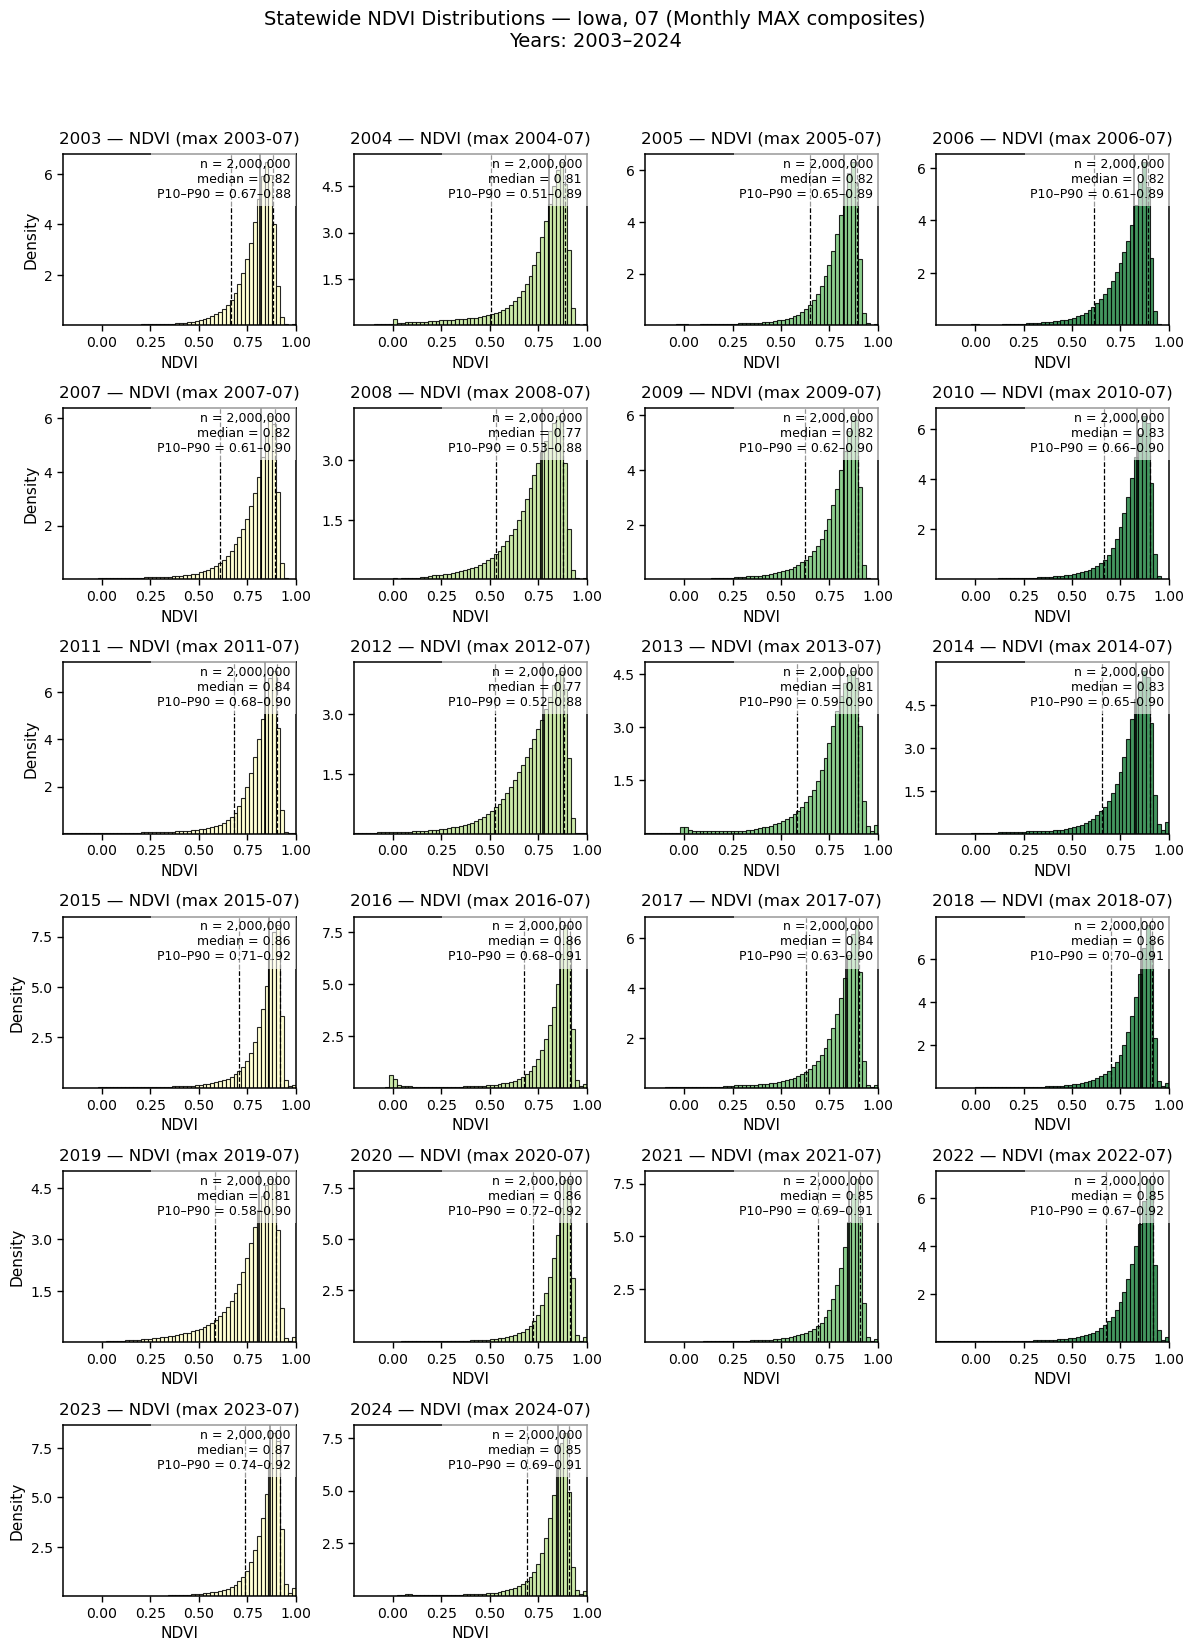

In [5]:
#!/usr/bin/env python3
# Fast NDVI/EVI2 Histogram Panels (threaded; blockwise; optional downsample/subsample)
# Author: Kimberly Van Meter
# Date: 2025-11-15

from pathlib import Path
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from concurrent.futures import ThreadPoolExecutor, as_completed
import os

# ========================
# USER SETTINGS
# ========================
REGION_LS      = "Iowa"

# 👉 Put *all* study years here; script will handle any length
YEARS          = [2003, 2004, 2005, 2006, 2007, 2008, 2009,
                  2010, 2011, 2012, 2013, 2014,
                  2015, 2016, 2017, 2018, 2019,
                  2020, 2021, 2022, 2023, 2024]

MONTH          = "07"
NDVI_OUT_ROOT  = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI"
SAVE_DIR       = NDVI_OUT_ROOT / "figures"

# NDVI or EVI2 (expects matching filenames, e.g., NDVI_YYYY_MM_MAX_MOSAIC.tif or EVI2_...)
METRIC         = "NDVI"   # "NDVI" or "EVI2"

# Histogram style
BINS           = 60
XRANGE         = (-0.2, 1.0)   # adjust if needed for EVI2
DENSITY        = True
ALPHA_FILL     = 0.85
EDGE_COLOR     = "black"
LINE_WIDTH     = 0.8

# Speed knobs
DOWNSAMPLE_FACTOR = 8          # try 8 or 4 for quick previews; 0 = off
SUBSAMPLE_N       = 2_000_000  # random sample for stats (after downsample); 0 = off

# Parallelism (threads avoid pickling issues in notebooks)
N_WORKERS = min(4, max(1, len(YEARS)))

# Fonts / layout
TITLE_FONTSIZE = 12
AXIS_FONTSIZE  = 11
TICK_FONTSIZE  = 10

# Figure name prefix
FNAME_PREFIX   = f"{METRIC}_histograms_{REGION_LS}_{MONTH}"

# ========================
# HELPERS
# ========================
def pretty_axes(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)
        spine.set_color("black")
    ax.tick_params(axis="both", which="both", direction="out", length=4, width=1.0, colors="black")
    ax.grid(False)

def mosaic_path_for(year: int, month: str) -> Path:
    # expects: {ROOT}/{YYYY}/{YYYY}_{MM}_MAX/{METRIC}_{YYYY}_{MM}_MAX_MOSAIC.tif
    return NDVI_OUT_ROOT / f"{year}" / f"{year}_{month}_MAX" / f"{METRIC}_{year}_{month}_MAX_MOSAIC.tif"

def blockwise_histogram(path: Path, bins, xrange, downsample_factor=0, subsample_n=0):
    # Fast path: global downsample
    if downsample_factor and downsample_factor > 1:
        with rasterio.open(path) as ds:
            h = max(1, ds.height // downsample_factor)
            w = max(1, ds.width  // downsample_factor)
            arr = ds.read(1, out_shape=(1, h, w), resampling=Resampling.nearest).astype("float32")
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return np.zeros(len(bins)-1, dtype=np.float64), 0, np.nan, np.nan, np.nan
        arr = np.clip(arr, xrange[0], xrange[1])
        if subsample_n and arr.size > subsample_n:
            idx = np.random.default_rng(42).choice(arr.size, subsample_n, replace=False)
            arr = arr[idx]
        hist, _ = np.histogram(arr, bins=bins)
        med = float(np.nanmedian(arr))
        p10 = float(np.nanpercentile(arr, 10))
        p90 = float(np.nanpercentile(arr, 90))
        return hist.astype(np.float64), arr.size, med, p10, p90

    # Blockwise path
    hist = np.zeros(len(bins)-1, dtype=np.float64)
    vals_for_stats = []
    rng = np.random.default_rng(42)
    target_stat_sample = subsample_n if subsample_n else 2_000_000
    taken = 0
    n_valid = 0

    with rasterio.open(path) as ds:
        for _, window in ds.block_windows(1):
            block = ds.read(1, window=window).astype("float32")
            block = block[np.isfinite(block)]
            if block.size == 0:
                continue
            block = np.clip(block, xrange[0], xrange[1])
            h, _ = np.histogram(block, bins=bins)
            hist += h.astype(np.float64)
            n_valid += block.size

            if target_stat_sample > 0 and taken < target_stat_sample:
                need = target_stat_sample - taken
                if block.size <= need:
                    vals_for_stats.append(block)
                    taken += block.size
                else:
                    idx = rng.choice(block.size, need, replace=False)
                    vals_for_stats.append(block[idx])
                    taken = target_stat_sample

    if n_valid == 0:
        return hist, 0, np.nan, np.nan, np.nan

    stats_arr = np.concatenate(vals_for_stats) if vals_for_stats else np.array([], dtype="float32")
    med = float(np.nanmedian(stats_arr)) if stats_arr.size else np.nan
    p10 = float(np.nanpercentile(stats_arr, 10)) if stats_arr.size else np.nan
    p90 = float(np.nanpercentile(stats_arr, 90)) if stats_arr.size else np.nan
    return hist, n_valid, med, p10, p90

def pick_fill_colors(n=4):
    base = ["#ffffcc", "#c2e699", "#78c679", "#238443"]
    return (base * ((n + 3) // 4))[:n]

def process_year(year):
    try:
        path = mosaic_path_for(year, MONTH)
        bins = np.linspace(XRANGE[0], XRANGE[1], BINS + 1)
        if not path.exists():
            return year, None
        hist, npx, med, p10, p90 = blockwise_histogram(
            path,
            bins=bins,
            xrange=XRANGE,
            downsample_factor=DOWNSAMPLE_FACTOR,
            subsample_n=SUBSAMPLE_N,
        )
        if DENSITY and npx > 0:
            width = np.diff(bins)
            y = hist / (hist.sum() * width.mean())
        else:
            y = hist
        return year, dict(bins=bins, y=y, n=npx, med=med, p10=p10, p90=p90)
    except Exception as e:
        return year, dict(error=str(e))

# ========================
# MAIN
# ========================
def main():
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    # Threaded map over years
    futures = []
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        for y in YEARS:
            futures.append(ex.submit(process_year, y))
        results = [f.result() for f in as_completed(futures)]

    # restore original YEAR order
    year_to_res = {y: r for y, r in results}
    ordered_results = [(y, year_to_res.get(y)) for y in YEARS]

    # ------------------------
    # Dynamic subplot layout
    # ------------------------
    n_years = len(YEARS)
    if n_years == 0:
        print("[WARN] No years specified.")
        return

    # choose columns; 4 works well up to ~16 years
    ncols = min(4, n_years)
    nrows = int(np.ceil(n_years / ncols))

    fig_width = 3.0 * ncols
    fig_height = 2.8 * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), squeeze=False)
    axes_flat = axes.ravel()

    colors = pick_fill_colors(n_years)
    bins_for_width = np.linspace(XRANGE[0], XRANGE[1], BINS + 1)
    width = bins_for_width[1] - bins_for_width[0]

    for idx, ((year, res), color) in enumerate(zip(ordered_results, colors)):
        ax = axes_flat[idx]
        pretty_axes(ax)
        ax.set_xlim(*XRANGE)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))
        ax.tick_params(labelsize=TICK_FONTSIZE)

        ax.set_xlabel(METRIC.upper(), fontsize=AXIS_FONTSIZE)
        ax.set_title(f"{year} — {METRIC.upper()} (max {year}-{MONTH})",
                     fontsize=TITLE_FONTSIZE, pad=8)

        if res is None:
            ax.text(
                0.5, 0.5,
                f"Missing mosaic\n{year}-{MONTH}",
                ha="center", va="center",
                fontsize=11, transform=ax.transAxes
            )
            continue

        if isinstance(res, dict) and "error" in res:
            ax.text(
                0.5, 0.5,
                f"Error:\n{res['error']}",
                ha="center", va="center",
                fontsize=9, transform=ax.transAxes
            )
            continue

        if res["n"] == 0:
            ax.text(
                0.5, 0.5,
                f"No valid {METRIC.upper()}\n{year}-{MONTH}",
                ha="center", va="center",
                fontsize=11, transform=ax.transAxes
            )
            continue

        bins = res["bins"]
        y = res["y"]
        npx = res["n"]
        med, p10, p90 = res["med"], res["p10"], res["p90"]

        centers = 0.5 * (bins[:-1] + bins[1:])

        ax.bar(
            centers, y,
            width=width,
            align="center",
            color=color,
            alpha=ALPHA_FILL,
            edgecolor=EDGE_COLOR,
            linewidth=LINE_WIDTH,
        )

        # percentile markers
        ax.axvline(med, color="black", linewidth=1.2, linestyle="-")
        ax.axvline(p10, color="black", linewidth=0.9, linestyle="--")
        ax.axvline(p90, color="black", linewidth=0.9, linestyle="--")

        ax.text(
            0.98, 0.98,
            f"n = {npx:,}\nmedian = {med:.2f}\nP10–P90 = {p10:.2f}–{p90:.2f}",
            ha="right", va="top", fontsize=9,
            transform=ax.transAxes,
            bbox=dict(facecolor="white", alpha=0.6, linewidth=0.0),
        )

    # Turn off any unused axes (if n_years is not a multiple of ncols)
    for j in range(n_years, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Y labels on left-most column
    for r in range(nrows):
        axes[r, 0].set_ylabel("Density" if DENSITY else "Count", fontsize=AXIS_FONTSIZE)

    # Title + layout
    year_label = (
        f"{YEARS[0]}–{YEARS[-1]}" if len(YEARS) > 1 else f"{YEARS[0]}"
    )
    fig.suptitle(
        f"Statewide {METRIC.upper()} Distributions — {REGION_LS}, {MONTH} (Monthly MAX composites)\nYears: {year_label}",
        fontsize=14,
        y=0.98,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    out_jpg = SAVE_DIR / f"{FNAME_PREFIX}_{METRIC}_{year_label}.jpeg"
    fig.savefig(out_jpg, dpi=300)
    print(f"[OK] Wrote figure → {out_jpg}")

if __name__ == "__main__":
    main()


### 🗺️ Step 4: Create Wetland Label Raster (Aligned to Reference Grid)

This script converts a **vector shapefile of historical wetlands** into an **integer label raster** (`int32`) aligned exactly with a fixed reference grid (e.g., the 2016 CDL corn mask).  
Each wetland polygon receives a unique numeric ID, stored in the raster as pixel values, and linked to its original identifier via a **crosswalk CSV**.

#### **Workflow Summary**

1. **Inputs**
   - Wetland polygons:  
     ```
     /Historical_Wetlands_FILT/Historical_Wetlands_TYLER_max647500m2_5070.shp
     ```
   - Reference grid (snap target):  
     ```
     /CropMasks/2016/CDL_2016_corn_mask_uint8.tif
     ```
   - Output directory:  
     ```
     /analysis/wetlands_ndvi_july/
     ```

2. **Load and Inspect Shapefile**
   - Detects a valid ID column (`wetland_id`, `WETLAND_ID`, `OBJECTID`, etc.).
   - Ensures CRS consistency (reprojects to match the reference grid if needed).
   - Repairs invalid geometries using `geom.buffer(0)`.

3. **Clip to Reference Grid Footprint**
   - Extracts only polygons that intersect the spatial extent of the CDL reference raster.

4. **Assign Sequential Labels**
   - Adds a new column `label = 1..N` for each wetland polygon.
   - Writes a **crosswalk table** linking `label` → original ID:
     ```
     wetlands_labels_crosswalk.csv
     ```

5. **Rasterize Wetland Polygons**
   - Converts polygons to an **integer label raster**:
     ```
     wetlands_labels_int32.tif
     ```
   - Each pixel value represents the wetland label ID.
   - Background (non-wetland) = 0 (`NODATA_LABEL`).

6. **Finalize Raster**
   - Uses the 2016 CDL grid’s CRS, resolution, and alignment.
   - Writes tiled, LZW-compressed GeoTIFF with overviews (pyramid layers).
   - Embeds metadata tags (creator, nodata value, ID column).

#### **Outputs**

| File | Description |
|------|--------------|
| `wetlands_labels_int32.tif` | Integer label raster aligned to 2016 CDL grid |
| `wetlands_labels_crosswalk.csv` | Crosswalk table linking raster labels to original wetland IDs |

#### **Purpose**

Creates a **spatial index of historical wetlands** aligned with the NDVI and crop mask rasters.  
This raster enables efficient per-wetland NDVI extraction, masking, and pixel-based time series analyses within the Des Moines Lobe study.

**Author:** Kimberly Van Meter  
**Date:** November 2025  
**Script:** `wetlands_to_label_raster_conowingo.py`


In [7]:
#!/usr/bin/env python3
# wetlands_to_label_raster_conowingo.py
# Create an int32 label raster of historic wetlands aligned to a fixed reference grid.

from pathlib import Path
import time
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.enums import Resampling
from rasterio.transform import array_bounds
from shapely.geometry import box
from shapely.errors import TopologicalError
import os

# -------------------------------
# PATHS (Conowingo)
# -------------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))

# ⬇️ Your wetlands shapefile
WETLAND_SHP = BASE / "Historical_Wetlands_FILT" / "Historical_Wetlands_TYLER_max647500m2_5070.shp"

# Reference grid (2016 corn mask you’ve been using)
REF_MASK = BASE / "CropMasks" / "2016" / "CDL_2016_corn_mask_uint8.tif"

# Outputs
OUT_DIR       = BASE / "analysis" / "wetlands_ndvi_july"
OUT_DIR.mkdir(parents=True, exist_ok=True)
LABEL_RASTER  = OUT_DIR / "wetlands_labels_int32.tif"
CROSSWALK_CSV = OUT_DIR / "wetlands_labels_crosswalk.csv"

# Label 0 = background/no-wetland
NODATA_LABEL = 0

# -------------------------------
# Helpers
# -------------------------------
def log(msg: str):
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

def get_ref_profile():
    if not REF_MASK.exists():
        raise FileNotFoundError(f"Reference mask not found: {REF_MASK}")
    with rasterio.open(REF_MASK) as ds:
        prof = {
            "driver": "GTiff",
            "height": ds.height,
            "width":  ds.width,
            "count":  1,
            "dtype":  "int32",
            "crs":    ds.crs,
            "transform": ds.transform,
            "compress": "LZW",
            "tiled": True,
            "blockxsize": 512,
            "blockysize": 512,
            "nodata": NODATA_LABEL,
            "BIGTIFF": "YES",
        }
    log(f"Loaded reference grid {REF_MASK.name}: {prof['width']}x{prof['height']} | {prof['crs']}")
    return prof

def pick_id_column(gdf: gpd.GeoDataFrame) -> str:
    candidates = ["wetland_id","Wetland_ID","WETLAND_ID","wl_id","site_id","SiteID","ID","id","OBJECTID","FID"]
    for c in candidates:
        if c in gdf.columns:
            return c
    # fallback: first non-geometry column
    for c in gdf.columns:
        if c != gdf.geometry.name:
            return c
    raise KeyError("Could not find an ID column in wetlands shapefile.")

def make_valid(geom):
    try:
        return geom if geom.is_valid else geom.buffer(0)
    except TopologicalError:
        return geom.buffer(0)

# -------------------------------
# Main
# -------------------------------
def main():
    ref_prof = get_ref_profile()

    # 1) Load polygons
    if not WETLAND_SHP.exists():
        raise FileNotFoundError(f"Wetlands shapefile not found: {WETLAND_SHP}")
    gdf = gpd.read_file(WETLAND_SHP)
    if gdf.empty:
        raise RuntimeError("Wetlands shapefile is empty.")
    if gdf.crs is None:
        log("[WARN] Wetlands CRS is missing; assuming EPSG:4326")
        gdf = gdf.set_crs("EPSG:4326", allow_override=True)

    id_col = pick_id_column(gdf)
    log(f"Using ID column: {id_col}")

    # 2) Clean geometry and reproject to reference CRS
    gdf["geometry"] = gdf.geometry.apply(make_valid)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf.to_crs(ref_prof["crs"])
    log(f"Wetlands CRS (after reprojection): {gdf.crs}")
    log(f"Reference CRS: {ref_prof['crs']}")

    # 3) Keep only polygons intersecting raster footprint
    left, bottom, right, top = array_bounds(ref_prof["height"], ref_prof["width"], ref_prof["transform"])
    footprint_poly = box(left, bottom, right, top)
    gdf = gdf[gdf.intersects(footprint_poly)].copy()
    if gdf.empty:
        raise RuntimeError("No wetlands intersect the reference grid footprint.")

    # 4) Build sequential labels starting at 1 (keep crosswalk to original IDs)
    gdf = gdf.reset_index(drop=True)
    gdf["label"] = np.arange(1, len(gdf) + 1, dtype=np.int64)

    # Crosswalk for later joins
    gdf[[id_col, "label"]].to_csv(CROSSWALK_CSV, index=False)
    log(f"Wrote crosswalk → {CROSSWALK_CSV} (rows={len(gdf)})")

    # 5) Rasterize to label raster (int32)
    shapes = list(zip(gdf.geometry, gdf["label"].astype(int)))
    out_shape = (ref_prof["height"], ref_prof["width"])
    log(f"Rasterizing {len(shapes)} polygons → {out_shape[1]}x{out_shape[0]} …")
    label_arr = rasterize(
        shapes=shapes,
        out_shape=out_shape,
        transform=ref_prof["transform"],
        fill=NODATA_LABEL,
        dtype="int32",
        all_touched=False  # set True if you want more inclusive edges
    )

    # 6) Write label raster with overviews
    with rasterio.open(LABEL_RASTER, "w", **ref_prof) as dst:
        dst.write(label_arr, 1)
        factors = [2, 4, 8, 16, 32]
        dst.build_overviews(factors, Resampling.nearest)
        dst.update_tags(
            CREATED_BY="wetlands_to_label_raster_conowingo.py",
            NODATA_LABEL=str(NODATA_LABEL),
            ID_COLUMN=id_col,
        )

    log(f"[OK] Wrote label raster → {LABEL_RASTER}")

if __name__ == "__main__":
    main()


[2025-11-13 13:54:35] Loaded reference grid CDL_2016_corn_mask_uint8.tif: 28521x33084 | EPSG:5070
[2025-11-13 13:54:38] Using ID column: Index
[2025-11-13 13:54:39] Wetlands CRS (after reprojection): PROJCS["unnamed",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
[2025-11-13 13:54:39] Reference CRS: EPSG:5070
[2025-11-13 13:54:39] Wrote crosswalk → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/wetlands_ndvi_july/wetlands_labels_crosswalk.csv (rows=200

### Script: Extract NDVI/EVI2 for Historical Wetlands and Adjacent Upland Cropland

This script extracts NDVI and EVI2 statistics for historical wetlands and for nearby upland cropland “windows” across multiple years, months, and crops (currently corn and soy). The script operates on a fixed label raster of historical wetlands, a set of crop-specific CDL masks, and precomputed Landsat-based NDVI/EVI2 monthly MAX mosaics that are already aligned to the wetland grid.

The main steps are:

1. **Load historical wetland labels and build per-wetland groups**

   - Read the integer label raster (`wetlands_labels_int32.tif`), where each historical wetland polygon has a unique positive integer ID and non-wetland/background is coded as a nodata label.
   - Precompute, for each wetland label:
     - The list of pixel indices belonging to that wetland.
     - A tight bounding box around the wetland in raster coordinates.
   - These precomputed groups are used to efficiently extract statistics for each wetland and its associated upland windows.

2. **Locate and defensively clean NDVI/EVI2 mosaics**

   - For each year–month combination, locate the corresponding NDVI and EVI2 MAX mosaics under the main NDVI directory, with a fallback search in an alternate root (`NDVI_2025`) if needed.
   - Enforce strict alignment between mosaics and the label raster (same CRS, transform, and dimensions).
   - Read NDVI/EVI2 bands as `float32` and:
     - Replace any explicit nodata codes with `NaN`.
     - Mask physically impossible values outside the range `[-0.2, 1.0]` and log the number of masked pixels.
   - Cleaned arrays are then used for all subsequent wetland and upland statistics.

3. **Select wetland cohorts by crop type**

   - For each crop (e.g., corn, soy) and year–month, load the corresponding crop mask (CDL-derived, boolean).
   - For each wetland label, compute the fraction of pixels inside the wetland that are classified as the target crop.
   - Retain only wetlands where the crop fraction is at least `SAMECROP_FRAC` (typically 1.0, i.e., 100% of wetland pixels are the target crop). This defines the per-crop “cohort” of wetlands used in the analysis.

4. **Compute wetland NDVI/EVI2 statistics**

   - For each wetland in the crop-specific cohort, extract NDVI and EVI2 values from the cleaned mosaics.
   - Compute per-wetland statistics:
     - Mean, median, standard deviation, and pixel count for NDVI.
     - Mean, median, standard deviation, and pixel count for EVI2.
   - These statistics characterize both central tendency and spatial heterogeneity within each wetland.

5. **Define and evaluate adjacent upland windows**

   - For each wetland, use the precomputed bounding box to define its height and width in pixels.
   - Construct four candidate upland windows by shifting the wetland footprint east, west, north, and south by `SHIFT_FACTOR × (height or width)` pixels.
   - For each direction:
     - Ensure that the shifted window lies within the raster bounds.
     - Require that at least `NONWET_MIN_FRAC` of pixels in the window are background (non-wetland), to avoid overlap with other labeled wetlands.
     - Compute the fraction of pixels in the window that are the same crop type as the wetland; require this fraction to be ≥ `SAMECROP_FRAC`.
     - If the window passes all checks, compute NDVI and EVI2 statistics for upland pixels (mean, median, standard deviation, and pixel count).
     - Record a detailed row that includes wetland and upland metrics, directional information (E/W/N/S), crop fraction, and a status flag (e.g., `ok`, `out_of_bounds`, `overlaps_wetland`, `crop_mismatch`, `ndvi_nodata`).

6. **Aggregate upland windows into pooled upland statistics**

   - For each wetland, pool all valid upland windows (across directions) that passed the checks.
   - Concatenate pixel indices from those windows and compute pooled upland NDVI/EVI2 statistics:
     - Mean, median, standard deviation, and total pixel count for NDVI.
     - Mean, median, standard deviation, and total pixel count for EVI2.
   - Store one pooled row per wetland with `dir = "ALL"` and a count of the number of directions contributing (`n_ok_dirs`).

7. **Write detailed, pooled, and master outputs**

   - For each crop–year–month combination, write:
     - A **detailed** CSV (`upland_rasteronly_<crop>_<year>_<month>_detailed.csv`) with one row per wetland–direction pair, including all status flags.
     - A **pooled** CSV (`upland_rasteronly_<crop>_<year>_<month>_pooled.csv`) with one row per wetland summarizing pooled upland metrics across valid directions.
   - Optionally append all detailed rows to a per-year **master CSV** (`upland_rasteronly_ALL_<year>.csv`), which can be used for downstream statistical analysis and figure generation.

Overall, this script links historical wetland labels, crop-specific CDL masks, and Landsat-derived NDVI/EVI2 mosaics to produce matched wetland–upland time series of vegetation condition. Wetlands are restricted to those dominated by a single crop type, upland windows are constrained to be non-wetland and crop-consistent, and NDVI/EVI2 mosaics are cleaned to remove physically impossible values before calculating wetland and upland statistics.


In [1]:
# CURRENT version

#!/usr/bin/env python3
from pathlib import Path
import sys, time
import numpy as np
import pandas as pd
import rasterio
import os

# ========================
# USER SETTINGS
# ========================
YEARS  = [2018] #[2003, 2004, 2005, 2006, 2007, 2008, 2009,
          #2010, 2011, 2012, 2013, 2014, 2015, 2016, 
          #2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
MONTHS = ["09"]  # <-- make iterable (e.g., ["05","06","07","08","09"])
CROPS  = ["corn", "soy"]

SAMECROP_FRAC   = 1   # fraction of pixels that must be target crop
NONWET_MIN_FRAC = 1   # fraction of pixels that must be background (non-wetland)
SHIFT_FACTOR    = 2   # bbox multiple for shifting upland windows (E/W/N/S)

COMPUTE_MEDIAN = True
COMPUTE_STD    = True
WRITE_MASTER   = True

ROOT          = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
LABEL_RASTER  = ROOT / "analysis/wetlands_ndvi_july/wetlands_labels_int32.tif"

NDVI_ROOT     = ROOT / "NDVI"       # {YEAR}/{YEAR}_{MONTH}_MAX/NDVI_{YEAR}_{MONTH}_MAX_MOSAIC.tif
NDVI_ROOT_2   = ROOT / "NDVI_2025"  # fallback search (if needed)

EVI2_ROOT     = ROOT / "NDVI"       # {YEAR}/{YEAR}_{MONTH}_MAX/EVI2_{YEAR}_{MONTH}_MAX_MOSAIC.tif (assumed)
EVI2_ROOT_2   = ROOT / "NDVI_2025"  # fallback search (if needed)

CROPMASK_ROOT = ROOT / "CropMasks"
OUT_DIR       = ROOT / "NDVI_wetlands"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ========================
# HELPERS
# ========================
def log(msg):
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

def ndvi_path_for(year, month):
    p = NDVI_ROOT / f"{year}" / f"{year}_{month}_MAX" / f"NDVI_{year}_{month}_MAX_MOSAIC.tif"
    if p.exists():
        return p
    # Fallback: try a couple patterns under NDVI_2025
    cands = list((NDVI_ROOT_2 / f"{year}").glob(f"*{year}_{month}*NDVI*/*.tif")) + \
            list((NDVI_ROOT_2 / f"{year}").glob(f"*{year}_{month}*NDVI*.tif"))
    cands = [c for c in cands if not c.name.startswith("._")]
    if cands:
        cands.sort(key=lambda x: x.stat().st_size, reverse=True)
        log(f"[FALLBACK] Using NDVI candidate: {cands[0]}")
        return cands[0]
    return None

def evi2_path_for(year, month):
    """
    Locate the EVI2 mosaic for a given year/month.

    Adjust the path/filename patterns here if your EVI2 mosaics
    are stored differently.
    """
    p = EVI2_ROOT / f"{year}" / f"{year}_{month}_MAX" / f"EVI2_{year}_{month}_MAX_MOSAIC.tif"
    if p.exists():
        return p
    # Fallback: try patterns under EVI2_2025
    cands = list((EVI2_ROOT_2 / f"{year}").glob(f"*{year}_{month}*EVI2*/*.tif")) + \
            list((EVI2_ROOT_2 / f"{year}").glob(f"*{year}_{month}*EVI2*.tif"))
    cands = [c for c in cands if not c.name.startswith("._")]
    if cands:
        cands.sort(key=lambda x: x.stat().st_size, reverse=True)
        log(f"[FALLBACK] Using EVI2 candidate: {cands[0]}")
        return cands[0]
    return None

# One master per year (not per month-list)
def master_csv_for(year):
    return OUT_DIR / f"upland_rasteronly_ALL_{year}.csv"

def stats_from_indices(arr, r_idx, c_idx, nodata,
                       compute_median=True, compute_std=True):
    """
    Generic stats helper: (mean, median, std, n).

    If arr is None or no valid data, returns (nan, nan, nan, 0).
    """
    if arr is None or r_idx.size == 0:
        return (np.nan,
                np.nan if compute_median else np.nan,
                np.nan if compute_std else np.nan,
                0)

    z = arr[r_idx, c_idx].astype("float32", copy=False)

    # Drop explicit nodata if finite
    if nodata is not None and not np.isnan(nodata):
        z = z[z != nodata]

    # Drop non-finite
    z = z[np.isfinite(z)]

    if z.size == 0:
        return (np.nan,
                np.nan if compute_median else np.nan,
                np.nan if compute_std else np.nan,
                0)

    mean = float(np.mean(z))
    med  = float(np.median(z)) if compute_median else np.nan
    std  = (float(np.std(z, ddof=1)) if compute_std and z.size > 1
            else (0.0 if compute_std and z.size == 1 else np.nan))
    return (mean, med, std, int(z.size))

def build_label_groups(labels, nodata_label):
    """Precompute wetland-pixel groups and bboxes for fast per-label access."""
    mask_wet = (labels != nodata_label) & (labels > 0)
    if not mask_wet.any():
        return None
    rr, cc = np.where(mask_wet)
    labs = labels[mask_wet].astype(np.int64, copy=False)
    order = np.argsort(labs, kind="mergesort")
    labs_sorted = labs[order]
    rr_sorted   = rr[order]
    cc_sorted   = cc[order]
    uniq, first_idx, counts = np.unique(labs_sorted, return_index=True, return_counts=True)
    group_index = {int(L): (int(s), int(s)+int(k)) for L, s, k in zip(uniq, first_idx, counts)}
    bbox = {}
    for L, (s, e) in group_index.items():
        rseg = rr_sorted[s:e]
        cseg = cc_sorted[s:e]
        bbox[L] = (int(rseg.min()), int(rseg.max()), int(cseg.min()), int(cseg.max()))
    return rr_sorted, cc_sorted, labs_sorted, group_index, bbox

def select_cohort_by_crop_fraction(group_index, rr_sorted, cc_sorted, crop_mask, frac_thresh):
    cohort, frac_map = [], {}
    for L, (s, e) in group_index.items():
        rseg = rr_sorted[s:e]; cseg = cc_sorted[s:e]
        frac = float(crop_mask[rseg, cseg].mean()) if (e > s) else 0.0
        frac_map[L] = frac
        if frac >= frac_thresh:
            cohort.append(L)
    return np.array(cohort, dtype=np.int64), frac_map

def shift_indices(rseg, cseg, drow, dcol, nrows, ncols):
    r2 = rseg + drow
    c2 = cseg + dcol
    keep = (r2 >= 0) & (r2 < nrows) & (c2 >= 0) & (c2 < ncols)
    return r2[keep], c2[keep]

# ========================
# MAIN
# ========================
def main():
    # Load label raster once
    with rasterio.open(LABEL_RASTER) as lab_src:
        labels = lab_src.read(1)
        # tag may be string; default to 0 if missing
        nodata_label = lab_src.tags().get("NODATA_LABEL")
        nodata_label = int(nodata_label) if nodata_label is not None else 0
        lab_crs = lab_src.crs
        lab_tr  = lab_src.transform
        nrows, ncols = lab_src.height, lab_src.width
        log(f"Loaded label raster: {LABEL_RASTER.name} ({ncols}x{nrows})")

    g = build_label_groups(labels, nodata_label)
    if g is None:
        log("[ERROR] No wetland pixels found in label raster.")
        sys.exit(1)
    rr_sorted, cc_sorted, labs_sorted, group_index, bbox = g
    log(f"Prepared groups for {len(group_index):,} wetland labels.")

    dirs = {"E": (0, +1), "W": (0, -1), "N": (-1, 0), "S": (+1, 0)}

    for year in YEARS:
        master_csv = master_csv_for(year)  # year-specific master

        # allow either list/tuple or scalar for MONTHS (defensive)
        months_iter = MONTHS if isinstance(MONTHS, (list, tuple, set)) else [MONTHS]

        for MONTH in months_iter:
            # NDVI path (required)
            ndvi_path = ndvi_path_for(year, MONTH)
            if ndvi_path is None or not ndvi_path.exists():
                log(f"[WARN] Missing NDVI mosaic for {year}-{MONTH}: expected under {NDVI_ROOT} or {NDVI_ROOT_2}. Skipping.")
                continue

            # EVI2 path (optional but desired)
            evi2_path = evi2_path_for(year, MONTH)
            if evi2_path is None or not evi2_path.exists():
                log(f"[WARN] Missing EVI2 mosaic for {year}-{MONTH}: expected under {EVI2_ROOT} or {EVI2_ROOT_2}. EVI2 stats will be NaN.")
                evi2 = None
                evi2_nodata = None
            else:
                with rasterio.open(evi2_path) as ev_src:
                    # Alignment checks vs labels
                    if ev_src.crs != lab_crs:
                        raise RuntimeError(f"CRS mismatch for EVI2 {evi2_path.name}: {ev_src.crs} vs labels {lab_crs}")
                    if not np.allclose(tuple(ev_src.transform)[:6], tuple(lab_tr)[:6], atol=1e-9):
                        raise RuntimeError("Transform mismatch: EVI2 grid not snapped to label grid")
                    if (ev_src.width, ev_src.height) != (ncols, nrows):
                        raise RuntimeError("Size mismatch: EVI2 dims differ from label raster")

                    # --- read + defensive cleaning ---  # <<< NEW
                    evi2 = ev_src.read(1).astype("float32", copy=False)
                    evi2_nodata = ev_src.nodata

                    # Mask impossible values (belt-and-suspenders)
                    bad_e2 = (evi2 < -0.2) | (evi2 > 1.0)
                    n_bad_e2 = int(bad_e2.sum())
                    if n_bad_e2 > 0:
                        log(f"[CLEAN] EVI2 {year}-{MONTH}: masking {n_bad_e2} pixels outside [-0.2, 1.0].")
                        evi2[bad_e2] = np.nan
                    # --- end new block ---  # <<< NEW

            with rasterio.open(ndvi_path) as nd_src:
                # Robust alignment checks: CRS, transform (with tolerance), and size
                if nd_src.crs != lab_crs:
                    raise RuntimeError(f"CRS mismatch for NDVI {ndvi_path.name}: {nd_src.crs} vs labels {lab_crs}")
                if not np.allclose(tuple(nd_src.transform)[:6], tuple(lab_tr)[:6], atol=1e-9):
                    raise RuntimeError("Transform mismatch: NDVI grid not snapped to label grid")
                if (nd_src.width, nd_src.height) != (ncols, nrows):
                    raise RuntimeError("Size mismatch: NDVI dims differ from label raster")

                # --- read + defensive cleaning ---  # <<< NEW
                ndvi = nd_src.read(1).astype("float32", copy=False)
                ndvi_nodata = nd_src.nodata

                # First, if nodata is defined and finite, optionally mask it
                if ndvi_nodata is not None and np.isfinite(ndvi_nodata):
                    ndvi[ndvi == ndvi_nodata] = np.nan

                # Mask impossible values outside physical range
                bad_nd = (ndvi < -0.2) | (ndvi > 1.0)
                n_bad_nd = int(bad_nd.sum())
                if n_bad_nd > 0:
                    log(f"[CLEAN] NDVI {year}-{MONTH}: masking {n_bad_nd} pixels outside [-0.2, 1.0].")
                    ndvi[bad_nd] = np.nan
                # --- end new block ---  # <<< NEW

            log(f"[OPEN] NDVI {year}-{MONTH}: {ndvi_path.name}")
            if evi2 is not None:
                log(f"[OPEN] EVI2 {year}-{MONTH}: {evi2_path.name}")

            for crop in CROPS:
                crop_mask_path = CROPMASK_ROOT / f"{year}" / f"CDL_{year}_{crop}_mask_uint8.tif"
                if not crop_mask_path.exists():
                    log(f"[WARN] Missing {crop} mask for {year}: {crop_mask_path.name} — skipping crop.")
                    continue

                with rasterio.open(crop_mask_path) as cm_src:
                    # Alignment checks
                    if cm_src.crs != lab_crs:
                        raise RuntimeError(f"CRS mismatch for crop mask {crop_mask_path.name}: {cm_src.crs} vs labels {lab_crs}")
                    if not np.allclose(tuple(cm_src.transform)[:6], tuple(lab_tr)[:6], atol=1e-9):
                        raise RuntimeError(f"Transform mismatch for crop mask {crop_mask_path.name}")
                    if (cm_src.width, cm_src.height) != (ncols, nrows):
                        raise RuntimeError(f"Size mismatch for crop mask {crop_mask_path.name}")
                    cm = cm_src.read(1).astype(bool, copy=False)

                # Build cohort (wetlands with ≥ SAMECROP_FRAC of target crop inside the label)
                cohort_labels, frac_map = select_cohort_by_crop_fraction(
                    group_index, rr_sorted, cc_sorted, cm, SAMECROP_FRAC
                )
                if cohort_labels.size == 0:
                    log(f"[WARN] No labels met {crop} cohort threshold in {year}-{MONTH}.")
                    continue
                log(f"[COHORT] {crop} {year}-{MONTH}: {cohort_labels.size:,} wetlands (≥{int(SAMECROP_FRAC*100)}% {crop}).")

                detailed_rows = []
                pooled_rows   = []

                for L in cohort_labels:
                    s, e = group_index[int(L)]
                    rseg = rr_sorted[s:e]; cseg = cc_sorted[s:e]

                    # Wetland NDVI stats
                    w_mean, w_med, w_std, w_np = stats_from_indices(
                        ndvi, rseg, cseg, ndvi_nodata,
                        compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                    )

                    # Wetland EVI2 stats
                    w_e2_mean, w_e2_med, w_e2_std, w_e2_np = stats_from_indices(
                        evi2, rseg, cseg, evi2_nodata if evi2 is not None else None,
                        compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                    )

                    # bbox size
                    r0, r1, c0, c1 = bbox[int(L)]
                    h = (r1 - r0 + 1)
                    w = (c1 - c0 + 1)

                    pooled_ur = []
                    pooled_uc = []

                    for dname, (dr, dc) in dirs.items():
                        drow = (SHIFT_FACTOR * h) * dr
                        dcol = (SHIFT_FACTOR * w) * dc

                        ur, uc = shift_indices(rseg, cseg, drow, dcol, nrows, ncols)
                        if ur.size == 0:
                            detailed_rows.append({
                                "year": year, "month": MONTH, "crop": crop, "label": int(L),
                                "dir": dname,
                                "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                                "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                                "wet_evi2_mean": w_e2_mean, "wet_evi2_med": w_e2_med,
                                "wet_evi2_std": w_e2_std, "wet_evi2_np": w_e2_np,
                                "upl_evi2_mean": np.nan, "upl_evi2_med": np.nan,
                                "upl_evi2_std": np.nan, "upl_evi2_np": 0,
                                "samecrop_frac": np.nan, "status": "out_of_bounds"
                            })
                            continue

                        # Non-wetland check (≥ NONWET_MIN_FRAC must be background)
                        if ((labels[ur, uc] == nodata_label).mean() < NONWET_MIN_FRAC):
                            detailed_rows.append({
                                "year": year, "month": MONTH, "crop": crop, "label": int(L),
                                "dir": dname,
                                "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                                "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                                "wet_evi2_mean": w_e2_mean, "wet_evi2_med": w_e2_med,
                                "wet_evi2_std": w_e2_std, "wet_evi2_np": w_e2_np,
                                "upl_evi2_mean": np.nan, "upl_evi2_med": np.nan,
                                "upl_evi2_std": np.nan, "upl_evi2_np": 0,
                                "samecrop_frac": np.nan, "status": "overlaps_wetland"
                            })
                            continue

                        # Same-crop check in upland window
                        same_frac = float(cm[ur, uc].mean())
                        if same_frac < SAMECROP_FRAC:
                            detailed_rows.append({
                                "year": year, "month": MONTH, "crop": crop, "label": int(L),
                                "dir": dname,
                                "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                                "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                                "wet_evi2_mean": w_e2_mean, "wet_e2_med": w_e2_med,
                                "wet_evi2_std": w_e2_std, "wet_evi2_np": w_e2_np,
                                "upl_evi2_mean": np.nan, "upl_evi2_med": np.nan,
                                "upl_evi2_std": np.nan, "upl_e2_np": 0,
                                "samecrop_frac": same_frac, "status": "crop_mismatch"
                            })
                            continue

                        # Upland NDVI stats
                        u_mean, u_med, u_std, u_np = stats_from_indices(
                            ndvi, ur, uc, ndvi_nodata,
                            compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                        )

                        if u_np == 0 or not np.isfinite(u_mean):
                            detailed_rows.append({
                                "year": year, "month": MONTH, "crop": crop, "label": int(L),
                                "dir": dname,
                                "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                                "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                                "wet_evi2_mean": w_e2_mean, "wet_e2_med": w_e2_med,
                                "wet_evi2_std": w_e2_std, "wet_evi2_np": w_e2_np,
                                "upl_evi2_mean": np.nan, "upl_e2_med": np.nan,
                                "upl_evi2_std": np.nan, "upl_e2_np": 0,
                                "samecrop_frac": same_frac, "status": "ndvi_nodata"
                            })
                            continue

                        # Upland EVI2 stats
                        u_e2_mean, u_e2_med, u_e2_std, u_e2_np = stats_from_indices(
                            evi2, ur, uc, evi2_nodata if evi2 is not None else None,
                            compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                        )

                        detailed_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": dname,
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": u_mean, "upl_med": u_med, "upl_std": u_std, "upl_np": u_np,
                            "wet_evi2_mean": w_e2_mean, "wet_e2_med": w_e2_med,
                            "wet_evi2_std": w_e2_std, "wet_e2_np": w_e2_np,
                            "upl_evi2_mean": u_e2_mean, "upl_e2_med": u_e2_med,
                            "upl_evi2_std": u_e2_std, "upl_e2_np": u_e2_np,
                            "samecrop_frac": same_frac, "status": "ok"
                        })
                        pooled_ur.append(ur); pooled_uc.append(uc)

                    # Pooled row across valid directions
                    if pooled_ur:
                        ur_all = np.concatenate(pooled_ur)
                        uc_all = np.concatenate(pooled_uc)
                        U_mean, U_med, U_std, U_np = stats_from_indices(
                            ndvi, ur_all, uc_all, ndvi_nodata,
                            compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                        )
                        U_e2_mean, U_e2_med, U_e2_std, U_e2_np = stats_from_indices(
                            evi2, ur_all, uc_all, evi2_nodata if evi2 is not None else None,
                            compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                        )
                        pooled_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": "ALL",
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": U_mean, "upl_med": U_med, "upl_std": U_std, "upl_np": U_np,
                            "wet_evi2_mean": w_e2_mean, "wet_e2_med": w_e2_med,
                            "wet_evi2_std": w_e2_std, "wet_e2_np": w_e2_np,
                            "upl_evi2_mean": U_e2_mean, "upl_e2_med": U_e2_med,
                            "upl_evi2_std": U_e2_std, "upl_e2_np": U_e2_np,
                            "n_ok_dirs": int(len(pooled_ur))
                        })
                    else:
                        pooled_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": "ALL",
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                            "wet_evi2_mean": w_e2_mean, "wet_e2_med": w_e2_med,
                            "wet_evi2_std": w_e2_std, "wet_e2_np": w_e2_np,
                            "upl_e2_mean": np.nan, "upl_e2_med": np.nan,
                            "upl_e2_std": np.nan, "upl_e2_np": 0,
                            "n_ok_dirs": 0
                        })

                # Write outputs (month-stamped, so no overwrite)
                out_detail = OUT_DIR / f"upland_rasteronly_{crop}_{year}_{MONTH}_detailed.csv"
                out_pooled = OUT_DIR / f"upland_rasteronly_{crop}_{year}_{MONTH}_pooled.csv"
                pd.DataFrame(detailed_rows).to_csv(out_detail, index=False)
                pd.DataFrame(pooled_rows).to_csv(out_pooled, index=False)
                log(f"[WRITE] {out_detail} (rows={len(detailed_rows):,})")
                log(f"[WRITE] {out_pooled} (rows={len(pooled_rows):,})")

                # Append to per-year master (optional)
                if WRITE_MASTER:
                    header = (not master_csv.exists()) or (master_csv.stat().st_size == 0)
                    pd.DataFrame(detailed_rows).to_csv(master_csv, mode="a", header=header, index=False)
                    log(f"[APPEND] {master_csv} (+{len(detailed_rows):,})")

    log("[DONE] All years/months/crops processed.")

if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        log(f"[ERROR] {e}")
        sys.exit(1)


[2025-12-09 11:13:09] Loaded label raster: wetlands_labels_int32.tif (28521x33084)
[2025-12-09 11:13:13] Prepared groups for 195,701 wetland labels.
[2025-12-09 11:13:17] [CLEAN] EVI2 2018-09: masking 464891198 pixels outside [-0.2, 1.0].
[2025-12-09 11:13:23] [CLEAN] NDVI 2018-09: masking 463303 pixels outside [-0.2, 1.0].
[2025-12-09 11:13:24] [OPEN] NDVI 2018-09: NDVI_2018_09_MAX_MOSAIC.tif
[2025-12-09 11:13:24] [OPEN] EVI2 2018-09: EVI2_2018_09_MAX_MOSAIC.tif
[2025-12-09 11:13:25] [COHORT] corn 2018-09: 77,453 wetlands (≥100% corn).
[2025-12-09 11:13:36] [WRITE] /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/NDVI_wetlands/upland_rasteronly_corn_2018_09_detailed.csv (rows=309,812)
[2025-12-09 11:13:36] [WRITE] /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/NDVI_wetlands/upland_rasteronly_corn_2018_09_pooled.csv (rows=77,453)
[2025-12-09 11:13:39] [APPEND] /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/NDVI_wetlands/upland_rasteronly_ALL_2018.csv (+309,812)
[2025-12-09 11:13:40] [COHORT] s

# Script: `analyze_ndvi_wetland_upland_by_year_plus_metrics_monthly.py`

This script performs a monthly analysis of **wetland vs. upland vegetation greenness** using Landsat-derived **NDVI** and **EVI2** composites. It processes pooled wetland–upland comparison tables, computes per-wetland vegetation differences, performs statistical tests, and generates diagnostic plots across two decades.

## Purpose

The script quantifies how vegetation greenness differs between wetlands and their matched upland comparison areas for each crop, year, and month. It produces:

- Per-wetland NDVI/EVI2 upland–wetland differences  
- Year-level summary statistics and effect sizes  
- Non-parametric hypothesis tests  
- Dry-year comparisons  
- Time-series and boxplot visualizations  

## Inputs

- Pooled CSV files of the form:  
  `upland_rasteronly_{crop}_{year}_{month}_pooled.csv`
- User-defined parameters:
  - **Years:** 2003–2024  
  - **Months:** e.g., `07`, `08`  
  - **Crops:** `corn`, `soy`  
  - **Vegetation index:** `NDVI` or `EVI2`  

## Processing Steps

### 1. Load pooled wetland–upland data

For each crop × year × month, the script loads the precomputed pooled table containing wetland and upland NDVI/EVI2 means and medians. Wetlands without valid upland data are removed.

### 2. Compute per-wetland NDVI and EVI2 differences

For each wetland label, four new columns are created:

- `ndvi_mean_upl_minus_wet`  
- `ndvi_median_upl_minus_wet`  
- `evi2_mean_upl_minus_wet`  
- `evi2_median_upl_minus_wet`  

All are defined as:

> upland value − wetland value  

Positive values indicate greener uplands; negative values indicate greener wetlands.

A per-wetland long-form CSV is saved for each month.

### 3. Compute the paired difference for the selected metric

Depending on which index is being analyzed (`NDVI` or `EVI2`), the script computes:

> `diff_med = wetland_median − upland_median`  

This paired difference is used for all statistical tests, effect sizes, and plots.

## 4. Year × crop statistical summaries

For each year × crop group (including a combined `"ALL"` category), the script computes:

- Number of wetland–upland pairs  
- Median wetland greenness  
- Median upland greenness  
- Median paired difference  
- Mean and standard deviation of paired differences  
- **Wilcoxon signed-rank test** (test statistic and p-value)  
- **Effect sizes:**  
  - Rank-biserial correlation  
  - Cohen’s *d* for paired samples  
- **Proportions:**  
  - `prop_neg` (wetland < upland)  
  - `prop_pos` (wetland > upland)  
  - `prop_close` (|Δ| ≤ 0.005)  
- **Bootstrap 95% confidence interval** for the median difference  
- **False Discovery Rate (FDR)** correction applied within each year  

All summary statistics are written to a month-specific CSV.

## 5. Diagnostic plots

For each crop and for `"ALL"`, the script produces:

- **Boxplots by year** showing distributions of paired differences  
- **Time-series plots** showing median yearly differences with bootstrap confidence intervals  

These figures illustrate long-term temporal patterns in wetland–upland greenness differences.

## 6. Dry-year comparisons

Dry years (2012, 2021) are flagged, and the script evaluates how paired greenness differences behave under moisture stress. Analyses include:

- **Mann–Whitney U test** comparing dry vs. non-dry distributions  
- **Robust OLS regression:**  
  `diff_med ~ is_dry + centered_year`  
- Optional **mixed-effects model** with wetland label as a random intercept  

Results are saved as separate CSV summaries.

## 7. Monthly output index

A month-level index file is created listing:

- The summary statistics CSV  
- Number of plots generated  
- Dry-year test output CSVs  

## Outputs

For each month, the script generates:

- Per-wetland CSV including NDVI/EVI2 upland–wetland differences  
- Yearly statistical summary CSVs  
- Boxplots and time-series plots  
- Dry-year comparison results  
- A monthly index file of outputs  

## Overall function

This script provides a reproducible workflow for evaluating long-term vegetation condition in historical wetlands compared to uplands. By combining per-wetland metrics, effect-size analyses, temporal trend evaluation, and statistical testing, it supports a detailed assessment of ecological functioning across the Des Moines Lobe landscape.


In [8]:
#updated

#!/usr/bin/env python3
# analyze_ndvi_wetland_upland_by_year_plus_metrics_monthly.py
# Author: Kimberly Van Meter
# Date: 2025-11-14 (updated for NDVI/EVI2 toggle)
# Updated: 2025-11-19 — add per-wetland NDVI/EVI2 upland−wetland mean/median difference columns
# Updated: 2025-11-19 (pm) — run BOTH NDVI and EVI2 in a single script
# Updated: 2025-11-25 — add Upland Advantage Index (UAI), absolute UAI, standardized UAI

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, mannwhitneyu, rankdata
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os

# ========================
# USER SETTINGS
# ========================
ROOT            = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
IN_DIR          = ROOT / "NDVI_wetlands"          # where *_pooled.csv live
OUT_DIR         = ROOT / "NDVI_wetlands" / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

YEARS           = [2013]         # must match generated years
MONTHS          = ["05", "06", "09"]   # analyze each of these months independently
CROPS           = ["corn", "soy"]      # analyze by crop and ALL

# Run both metrics in sequence
METRICS_TO_RUN  = ["NDVI", "EVI2"]     # run NDVI then EVI2

# Mark known dry years (hypothesis: Δ is closer to 0 in dry years)
DRY_YEARS       = {2012, 2021}

# Filters
REQUIRE_VALID_UPLAND = True        # require n_ok_dirs > 0
MIN_PAIRS_PER_GROUP  = 20          # skip stats if fewer than this many paired diffs

# Bootstrap CI for the median difference
BOOTSTRAP_N     = 2000
BOOTSTRAP_SEED  = 42
CI_ALPHA        = 0.05             # 95% CI

# Practical-significance margin (|Δ| ≤ τ) for “nearly equal” vegetation index
DELTA_TAU       = 0.005            # tweak as desired (~0.5% NDVI/EVI2 units)

# Plotting
FIG_DPI         = 300
FIGSIZE_BOX     = (10, 4.6)
FIGSIZE_TS      = (8.5, 4.0)

# Mixed effects (optional; slower). Requires enough RAM & statsmodels MixedLM.
RUN_MIXED_EFF   = False            # set True to fit mixed model Δ ~ is_dry + year_c + (1|label)

# ========================
# METRIC CONFIG (globals)
# ========================
METRIC        = "NDVI"  # default; will be overwritten in main loop
WET_COL       = None
UPL_COL       = None
RESULT_PREFIX = None
METRIC_LABEL  = None
YLABEL_DIFF   = None
YLABEL_TS     = None


def set_metric(metric_name: str):
    """
    Configure globals for NDVI or EVI2.

    NDVI  → wet_med / upl_med
    EVI2  → wet_evi2_med / upl_evi2_med
    """
    global METRIC, WET_COL, UPL_COL, RESULT_PREFIX, METRIC_LABEL, YLABEL_DIFF, YLABEL_TS

    m = metric_name.upper()
    METRIC = m

    if m == "NDVI":
        WET_COL       = "wet_med"
        UPL_COL       = "upl_med"
        RESULT_PREFIX = "ndvi"
        METRIC_LABEL  = "NDVI"
        YLABEL_DIFF   = "Wetland − Upland median NDVI"
        YLABEL_TS     = "Median NDVI difference (Wetland − Upland)"
    elif m == "EVI2":
        WET_COL       = "wet_evi2_med"
        UPL_COL       = "upl_evi2_med"
        RESULT_PREFIX = "evi2"
        METRIC_LABEL  = "EVI2"
        YLABEL_DIFF   = "Wetland − Upland median EVI2"
        YLABEL_TS     = "Median EVI2 difference (Wetland − Upland)"
    else:
        raise ValueError(f"Unsupported METRIC={metric_name}. Use 'NDVI' or 'EVI2'.")


# ========================
# HELPERS
# ========================
def log(msg):
    print(f"[analyze+ {METRIC}] {msg}", flush=True)


def load_pooled_rows(years, month, crops, in_dir, wet_col, upl_col, require_valid=True):
    """
    Load pooled rows for a single month; returns long DF with per-wetland differences.

    Adds:
      - diff_med (wet_col − upl_col, for chosen METRIC)
      - ndvi_mean_upl_minus_wet
      - ndvi_median_upl_minus_wet
      - evi2_mean_upl_minus_wet
      - evi2_median_upl_minus_wet

      New metrics (for the chosen METRIC only):
      - UAI       = upland − wetland (Upland Advantage Index)
      - abs_UAI   = |UAI|
      - z_UAI     = UAI / SD(upland)  (standardized greenness difference)
    """
    rows = []
    for y in years:
        for crop in crops:
            p = in_dir / f"upland_rasteronly_{crop}_{y}_{month}_pooled.csv"
            if not p.exists():
                log(f"WARN: missing pooled file → {p.name}")
                continue
            df = pd.read_csv(p)
            df = df.loc[df["dir"] == "ALL"].copy()
            df["year"] = y
            df["month"] = month
            df["crop"] = crop
            rows.append(df)

    if not rows:
        return pd.DataFrame()

    all_df = pd.concat(rows, ignore_index=True)

    # keep valid pairs only for the chosen metric
    if wet_col not in all_df.columns or upl_col not in all_df.columns:
        log(f"ERROR: Expected columns {wet_col}, {upl_col} not found in pooled CSVs.")
        return pd.DataFrame()

    all_df = all_df[np.isfinite(all_df[wet_col]) & np.isfinite(all_df[upl_col])].copy()
    if require_valid and "n_ok_dirs" in all_df.columns:
        all_df = all_df[all_df["n_ok_dirs"] > 0].copy()

    # Metric-specific paired difference (wet − upl) used for tests/plots
    all_df["diff_med"] = all_df[wet_col] - all_df[upl_col]

    # Per-wetland upland − wetland differences for NDVI and EVI2 (mean + median)
    if {"wet_mean", "upl_mean"}.issubset(all_df.columns):
        all_df["ndvi_mean_upl_minus_wet"] = all_df["upl_mean"] - all_df["wet_mean"]
    else:
        all_df["ndvi_mean_upl_minus_wet"] = np.nan

    if {"wet_med", "upl_med"}.issubset(all_df.columns):
        all_df["ndvi_median_upl_minus_wet"] = all_df["upl_med"] - all_df["wet_med"]
    else:
        all_df["ndvi_median_upl_minus_wet"] = np.nan

    if {"wet_evi2_mean", "upl_evi2_mean"}.issubset(all_df.columns):
        all_df["evi2_mean_upl_minus_wet"] = all_df["upl_evi2_mean"] - all_df["wet_evi2_mean"]
    else:
        all_df["evi2_mean_upl_minus_wet"] = np.nan

    if {"wet_evi2_med", "upl_evi2_med"}.issubset(all_df.columns):
        all_df["evi2_median_upl_minus_wet"] = all_df["upl_evi2_med"] - all_df["wet_evi2_med"]
    else:
        all_df["evi2_median_upl_minus_wet"] = np.nan

    # New per-wetland metrics for the *active* vegetation index
    # UAI = upland − wetland (median-based), abs_UAI, and standardized z_UAI
    all_df["UAI"] = all_df[upl_col] - all_df[wet_col]
    all_df["abs_UAI"] = np.abs(all_df["UAI"])

    # Standardized greenness difference: divide by upland std for this metric
    if METRIC == "NDVI":
        std_candidates = ["upl_std"]
    else:  # EVI2
        std_candidates = ["upl_evi2_std", "upl_e2_std"]

    std_col = next((c for c in std_candidates if c in all_df.columns), None)
    if std_col is not None:
        std_vals = all_df[std_col].replace(0, np.nan)
        all_df["z_UAI"] = all_df["UAI"] / std_vals
    else:
        all_df["z_UAI"] = np.nan

    if "label" in all_df.columns:
        all_df["label"] = all_df["label"].astype(int, errors="ignore")

    return all_df


def bootstrap_ci_median(x, n=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    meds = []
    for _ in range(n):
        samp = rng.choice(x, size=x.size, replace=True)
        meds.append(np.median(samp))
    lo = np.percentile(meds, 100 * (alpha/2))
    hi = np.percentile(meds, 100 * (1 - alpha/2))
    return float(lo), float(hi)


def rank_biserial_signed(diffs):
    """
    Rank-biserial correlation for paired data from Wilcoxon signed-rank ingredients:
    r_rb = (R_pos - R_neg) / (R_pos + R_neg)
    """
    d = np.asarray(diffs, dtype=float)
    d = d[np.isfinite(d) & (d != 0)]
    n = d.size
    if n == 0:
        return np.nan
    ranks = rankdata(np.abs(d), method="average")
    R_pos = ranks[d > 0].sum()
    R_neg = ranks[d < 0].sum()
    denom = R_pos + R_neg
    if denom == 0:
        return np.nan
    return float((R_pos - R_neg) / denom)


def cohens_d_z(diffs):
    """Cohen's d for paired samples: mean(diff)/sd(diff)."""
    d = np.asarray(diffs, dtype=float)
    d = d[np.isfinite(d)]
    n = d.size
    if n == 0:
        return np.nan
    sd = d.std(ddof=1) if n > 1 else 0.0
    if sd == 0.0:
        return 0.0
    return float(d.mean() / sd)


def proportions_from_diffs(diffs, tau=0.005):
    """Return: p_neg (Δ<0), p_pos (Δ>0), p_close (|Δ|≤tau)."""
    d = np.asarray(diffs, dtype=float)
    d = d[np.isfinite(d)]
    n = d.size
    if n == 0:
        return (np.nan, np.nan, np.nan)
    p_neg = float(np.mean(d < 0))
    p_pos = float(np.mean(d > 0))
    p_close = float(np.mean(np.abs(d) <= tau))
    return p_neg, p_pos, p_close


def summarize_group(df, group_cols, wet_col, upl_col):
    """Compute all stats & tests for each group."""
    out = []
    for keys, g in df.groupby(group_cols, dropna=False):
        key_dict = {}
        if isinstance(keys, tuple):
            for k, v in zip(group_cols, keys):
                key_dict[k] = v
        else:
            key_dict[group_cols[0]] = keys

        diffs = g["diff_med"].values  # wet − upl for chosen metric
        n = np.sum(np.isfinite(diffs))
        md_w = float(np.median(g[wet_col])) if len(g) else np.nan
        md_u = float(np.median(g[upl_col])) if len(g) else np.nan

        # group-level summaries of UAI metrics
        median_uai = np.nan
        median_abs_uai = np.nan
        median_z_uai = np.nan

        if "UAI" in g.columns:
            u = g["UAI"].to_numpy(dtype=float)
            u = u[np.isfinite(u)]
            if u.size:
                median_uai = float(np.median(u))
                median_abs_uai = float(np.median(np.abs(u)))
        if "z_UAI" in g.columns:
            z = g["z_UAI"].to_numpy(dtype=float)
            z = z[np.isfinite(z)]
            if z.size:
                median_z_uai = float(np.median(z))

        if n < MIN_PAIRS_PER_GROUP:
            rb = coh = np.nan
            pneg, ppos, pclose = proportions_from_diffs(diffs, DELTA_TAU)
            ci_lo, ci_hi = (np.nan, np.nan)
            stat, p = (np.nan, np.nan)
            med_diff = float(np.median(diffs)) if n else np.nan
            mean_diff = float(np.mean(diffs)) if n else np.nan
            sd_diff = float(np.std(diffs, ddof=1)) if n > 1 else (0.0 if n == 1 else np.nan)
        else:
            med_diff = float(np.median(diffs))
            mean_diff = float(np.mean(diffs))
            sd_diff = float(np.std(diffs, ddof=1)) if n > 1 else 0.0
            # Wilcoxon signed-rank
            try:
                stat, p = wilcoxon(
                    diffs,
                    zero_method="wilcox",
                    alternative="two-sided",
                    correction=False
                )
                stat = float(stat)
                p = float(p)
            except ValueError:
                stat, p = (np.nan, 1.0)
            # CIs and effect sizes
            ci_lo, ci_hi = bootstrap_ci_median(
                diffs, n=BOOTSTRAP_N, alpha=CI_ALPHA, seed=BOOTSTRAP_SEED
            )
            rb  = rank_biserial_signed(diffs)
            coh = cohens_d_z(diffs)
            pneg, ppos, pclose = proportions_from_diffs(diffs, DELTA_TAU)

        key_dict.update({
            "n_pairs": int(n),
            "median_wet": md_w,
            "median_upl": md_u,
            "median_diff": med_diff,   # wet − upl
            "mean_diff": mean_diff,
            "std_diff": sd_diff,
            "median_UAI": median_uai,          # upl − wet
            "median_abs_UAI": median_abs_uai,  # |upl − wet|
            "median_z_UAI": median_z_uai,      # standardized UAI
            "wilcoxon_T": stat,
            "p_value": p,
            "rbiserial": rb,               # rank-biserial correlation (paired)
            "cohens_dz": coh,              # Cohen's d for paired diffs
            "prop_neg": pneg,              # fraction Δ<0 (wetland < upland)
            "prop_pos": ppos,              # fraction Δ>0
            "prop_close": pclose,          # fraction |Δ| ≤ τ
            "ci_low": ci_lo,
            "ci_high": ci_hi
        })
        out.append(key_dict)
    return pd.DataFrame(out)


def fdr_correct(df, p_col="p_value", group=None):
    df = df.copy()
    if group is None:
        mask = np.isfinite(df[p_col])
        if mask.sum():
            _, q, _, _ = multipletests(df.loc[mask, p_col], method="fdr_bh")
            df.loc[mask, "q_value"] = q
        else:
            df["q_value"] = np.nan
        return df
    df["q_value"] = np.nan
    for keys, g in df.groupby(group):
        mask = np.isfinite(g[p_col])
        if mask.sum():
            _, q, _, _ = multipletests(g.loc[mask, p_col], method="fdr_bh")
            df.loc[g.index[mask], "q_value"] = q
    return df


def plot_year_boxplots(diffs_df, title, out_png, ylabel):
    """Boxplots of paired differences (wet_med - upl_med) per year."""
    data, tick_labels = [], []
    years_sorted = sorted(diffs_df["year"].unique())
    for y in years_sorted:
        d = diffs_df.loc[diffs_df["year"] == y, "diff_med"].values
        d = d[np.isfinite(d)]
        if d.size == 0:
            continue
        data.append(d)
        tick_labels.append(str(y))

    if not data:
        log(f"No data for boxplot {out_png}")
        return

    plt.figure(figsize=FIGSIZE_BOX)
    plt.boxplot(data, tick_labels=tick_labels, showmeans=True, whis=[5, 95])
    plt.axhline(0.0, lw=1.0, linestyle="--")
    plt.ylabel(ylabel)
    plt.xlabel("Year")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=FIG_DPI)
    plt.close()


def plot_median_diff_time_series(pooled_df, title, out_png, ylabel,
                                 n_boot=2000, alpha=0.05, seed=42):
    """Line plot of median (wet - upl) by year with bootstrap CI."""
    rng = np.random.default_rng(seed)
    rows = []
    for y, g in pooled_df.groupby("year"):
        diffs = g["diff_med"].dropna().values
        if diffs.size == 0:
            continue
        med = float(np.median(diffs))
        meds = []
        for _ in range(n_boot):
            samp = rng.choice(diffs, size=diffs.size, replace=True)
            meds.append(np.median(samp))
        lo = float(np.percentile(meds, 100*(alpha/2)))
        hi = float(np.percentile(meds, 100*(1-alpha/2)))
        rows.append(dict(year=int(y), med=med, lo=lo, hi=hi))
    if not rows:
        log(f"No data for time-series {out_png}")
        return
    df = pd.DataFrame(rows).sort_values("year")

    plt.figure(figsize=FIGSIZE_TS)
    plt.plot(df["year"], df["med"], marker="o")
    plt.fill_between(df["year"], df["lo"], df["hi"], alpha=0.2)
    plt.axhline(0.0, lw=1.0, linestyle="--")
    plt.ylabel(ylabel)
    plt.xlabel("Year")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=FIG_DPI)
    plt.close()


def dry_year_analyses(df_diffs, crop, month, out_dir):
    """Compare Δ in dry vs non-dry years; OLS with is_dry; optional MixedLM."""
    df = df_diffs.copy()
    df["is_dry"] = df["year"].isin(DRY_YEARS).astype(int)
    df["year_c"] = df["year"] - df["year"].mean()

    # Mann–Whitney U on Δ distributions (dry vs non-dry)
    d_dry   = df.loc[df["is_dry"] == 1, "diff_med"].dropna().values
    d_wet   = df.loc[df["is_dry"] == 0, "diff_med"].dropna().values
    mw_p = np.nan
    if d_dry.size > 0 and d_wet.size > 0:
        _, mw_p = mannwhitneyu(
            d_dry, d_wet,
            alternative="two-sided",
            method="exact" if min(len(d_dry), len(d_wet)) < 50 else "asymptotic"
        )
        mw_p = float(mw_p)

    # OLS with robust SE (HC3): Δ ~ is_dry + year_c
    ols_res = None
    try:
        ols_model = smf.ols("diff_med ~ is_dry + year_c", data=df).fit(cov_type="HC3")
        ols_res = {
            "coef_is_dry": float(ols_model.params.get("is_dry", np.nan)),
            "se_is_dry": float(ols_model.bse.get("is_dry", np.nan)),
            "p_is_dry": float(ols_model.pvalues.get("is_dry", np.nan)),
            "coef_year_c": float(ols_model.params.get("year_c", np.nan)),
            "p_year_c": float(ols_model.pvalues.get("year_c", np.nan)),
            "n": int(ols_model.nobs),
            "r2": float(ols_model.rsquared)
        }
    except Exception as e:
        log(f"OLS failed for {crop} {month}: {e}")

    # Optional MixedLM: Δ ~ is_dry + year_c + (1|label)
    mx_res = None
    if RUN_MIXED_EFF and "label" in df.columns:
        try:
            mx = sm.MixedLM.from_formula("diff_med ~ is_dry + year_c", groups="label", data=df)
            mx_fit = mx.fit(reml=True, method="lbfgs")
            mx_res = {
                "coef_is_dry": float(mx_fit.params.get("is_dry", np.nan)),
                "p_is_dry": float(mx_fit.pvalues.get("is_dry", np.nan)),
                "coef_year_c": float(mx_fit.params.get("year_c", np.nan)),
                "p_year_c": float(mx_fit.pvalues.get("year_c", np.nan)),
                "var_u0": float(mx_fit.cov_re.iloc[0,0]),
                "n": int(mx_fit.nobs)
            }
        except Exception as e:
            log(f"MixedLM failed for {crop} {month}: {e}")

    # Save a small summary file (metric-tagged)
    out_csv = out_dir / f"dryyear_test_{RESULT_PREFIX}_{crop}_{month}.csv"
    rec = {
        "crop": crop,
        "month": month,
        "metric": METRIC_LABEL,
        "n_dry": int((df["is_dry"]==1).sum()),
        "n_wet": int((df["is_dry"]==0).sum()),
        "mw_p": mw_p,
        "ols_coef_is_dry": (ols_res or {}).get("coef_is_dry", np.nan),
        "ols_se_is_dry": (ols_res or {}).get("se_is_dry", np.nan),
        "ols_p_is_dry": (ols_res or {}).get("p_is_dry", np.nan),
        "ols_coef_year_c": (ols_res or {}).get("coef_year_c", np.nan),
        "ols_p_year_c": (ols_res or {}).get("p_year_c", np.nan),
        "ols_r2": (ols_res or {}).get("r2", np.nan),
        "ols_n": (ols_res or {}).get("n", np.nan),
        "mx_coef_is_dry": (mx_res or {}).get("coef_is_dry", np.nan),
        "mx_p_is_dry": (mx_res or {}).get("p_is_dry", np.nan),
        "mx_coef_year_c": (mx_res or {}).get("coef_year_c", np.nan),
        "mx_p_year_c": (mx_res or {}).get("p_year_c", np.nan),
        "mx_var_u0": (mx_res or {}).get("var_u0", np.nan),
        "mx_n": (mx_res or {}).get("n", np.nan),
    }
    pd.DataFrame([rec]).to_csv(out_csv, index=False)
    log(f"Dry-year summary → {out_csv}")


def write_results_paragraph(results_csv, crops=("corn","soy","ALL"),
                            tau=0.005, month="??", metric_label="NDVI"):
    df = pd.read_csv(results_csv)
    df = df[df["crop"].isin(crops)].copy()
    df["sign"] = np.sign(df["median_diff"])
    lines = []
    for y in sorted(df["year"].unique()):
        sub = df[df["year"] == y].sort_values("crop")
        parts = []
        for c in crops:
            row = sub[sub["crop"] == c]
            if row.empty:
                continue
            md = row["median_diff"].iloc[0]
            q  = row.get("q_value", pd.Series([np.nan])).iloc[0]
            rb = row.get("rbiserial", pd.Series([np.nan])).iloc[0]
            pn = row.get("prop_neg", pd.Series([np.nan])).iloc[0]
            pc = row.get("prop_close", pd.Series([np.nan])).iloc[0]
            parts.append(
                f"{c}: Δ̃={md:+.3f} (q={q:.3g}), r_rb={rb:+.3f}, "
                f"P(Δ<0)={pn:.2f}, P(|Δ|≤{tau})={pc:.2f}"
            )
        if parts:
            lines.append(f"{y}: " + "; ".join(parts))
    print(
        f"\nRESULTS DIGEST — {metric_label}, Month {month} "
        f"(per-year Δ̃ with FDR q, rank-biserial, proportions):\n" +
        "\n".join(lines)
    )


# ========================
# MONTH PIPELINE
# ========================
def run_month_pipeline(month):
    # Make a month-specific subfolder
    out_m = OUT_DIR / f"{RESULT_PREFIX}_month_{month}"
    out_m.mkdir(parents=True, exist_ok=True)

    # 1) Load pooled rows and paired differences for this month (for chosen metric)
    pooled = load_pooled_rows(
        YEARS, month, CROPS, IN_DIR,
        wet_col=WET_COL, upl_col=UPL_COL,
        require_valid=REQUIRE_VALID_UPLAND
    )
    if pooled.empty:
        log(f"ERROR: No pooled data found for month {month} (metric {METRIC_LABEL}). Verify previous step completed.")
        return None

    # OPTIONAL: save the per-wetland long table with new difference columns
    pooled_out = out_m / f"{RESULT_PREFIX}_pooled_with_diffs_{month}.csv"
    pooled.to_csv(pooled_out, index=False)
    log(f"[{month}] Wrote per-wetland pooled data with NDVI/EVI2 upland−wetland diffs → {pooled_out}")

    # 2) Summaries per year×crop
    by_year_crop = summarize_group(pooled, ["year", "crop"], WET_COL, UPL_COL)

    # 3) Summaries per year across crops ("ALL")
    pooled_all = pooled.copy()
    pooled_all["crop"] = "ALL"
    by_year_all = summarize_group(pooled_all, ["year", "crop"], WET_COL, UPL_COL)

    # 4) Combine and FDR-correct p-values within each year
    results = pd.concat([by_year_crop, by_year_all], ignore_index=True)
    results = fdr_correct(results, p_col="p_value", group=["year"])

    # 5) Save month-specific results (metric-tagged)
    out_csv = out_m / f"{RESULT_PREFIX}_wetland_upland_year_stats_plus_{month}.csv"
    results_sorted = results.sort_values(["year", "crop"])
    results_sorted["month"] = month
    results_sorted["metric"] = METRIC_LABEL
    results_sorted.to_csv(out_csv, index=False)
    log(f"[{month}] Wrote stats+ → {out_csv} (rows={len(results_sorted)})")

    # 6) Plots per crop & ALL (month-tagged)
    for crop in CROPS + ["ALL"]:
        df_plot = pooled_all if crop == "ALL" else pooled[pooled["crop"] == crop]
        if df_plot.empty:
            continue
        # boxplot by year
        title = f"{METRIC_LABEL} Difference (Wetland − Upland), by Year — {crop} (Month {month})"
        out_png = out_m / f"{RESULT_PREFIX}_diff_boxplot_{crop}_{month}.png"
        plot_year_boxplots(df_plot, title, out_png, ylabel=YLABEL_DIFF)
        log(f"[{month}] Wrote plot → {out_png}")
        # time series of medians with CI
        title_ts = f"Median {METRIC_LABEL} Difference vs. Year — {crop} (Month {month})"
        out_ts = out_m / f"{RESULT_PREFIX}_diff_median_timeseries_{crop}_{month}.png"
        plot_median_diff_time_series(df_plot, title_ts, out_ts, ylabel=YLABEL_TS)
        log(f"[{month}] Wrote plot → {out_ts}")
        # dry-year analyses
        dry_year_analyses(df_plot, crop, month, out_m)

    # 7) Console digest for manuscript text (month-tagged)
    write_results_paragraph(
        out_csv,
        crops=("corn","soy","ALL"),
        tau=DELTA_TAU,
        month=month,
        metric_label=METRIC_LABEL
    )

    return {
        "month": month,
        "results_csv": out_csv,
        "plots": sorted([str(p) for p in out_m.glob("*.png")]),
        "dry_year_csvs": sorted([str(p) for p in out_m.glob(f"dryyear_test_{RESULT_PREFIX}_*_{month}.csv")])
    }


# ========================
# MAIN
# ========================
def main():
    # Run both NDVI and EVI2 sequentially
    for metric_name in METRICS_TO_RUN:
        set_metric(metric_name)
        log(f"Starting analysis for METRIC={METRIC_LABEL}")

        index_rows = []
        for m in MONTHS:
            out = run_month_pipeline(m)
            if out is not None:
                index_rows.append(out)

        # Write a small index of outputs across months for this metric
        if index_rows:
            idx_records = []
            for entry in index_rows:
                idx_records.append({
                    "month": entry["month"],
                    "metric": METRIC_LABEL,
                    "results_csv": entry["results_csv"],
                    "n_plots": len(entry["plots"]),
                    "n_dry_csv": len(entry["dry_year_csvs"])
                })
            idx_df = pd.DataFrame(idx_records).sort_values("month")
            idx_out = OUT_DIR / f"{RESULT_PREFIX}_monthly_outputs_index.csv"
            idx_df.to_csv(idx_out, index=False)
            log(f"Wrote monthly outputs index → {idx_out}")


if __name__ == "__main__":
    main()


FileExistsError: [Errno 17] File exists: '/Volumes/Conowingo'

In [2]:
#!/usr/bin/env python3
"""
Enhance wetland pooled NDVI datasets by:

1. Loading July + August pooled CSVs
2. Computing wetland area (hectares) from wetlands shapefile
3. Appending area to pooled CSVs
4. Computing median wetland area per year
5. Producing distribution plots of wetland area per year
6. Merging wetland area into a combined annual dataset
"""

from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# -----------------------------------------------------------
# PATHS
# -----------------------------------------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))

CSV_07 = BASE / "NDVI_wetlands" / "analysis" / "ndvi_month_07" / "ndvi_pooled_with_diffs_07.csv"
CSV_08 = BASE / "NDVI_wetlands" / "analysis" / "ndvi_month_08" / "ndvi_pooled_with_diffs_08.csv"

# Wetlands shapefile used for rasterization
WET_SHP = BASE / "Historical_Wetlands_FILT" / "Historical_Wetlands_TYLER_max647500m2_5070.shp"

# Crosswalk (ID → label)
CROSSWALK = BASE / "analysis" / "wetlands_ndvi_july" / "wetlands_labels_crosswalk.csv"

# Combined dataset (update path if needed)
COMBINED_DATA = BASE / "NDVI_wetlands" / "analysis" / "combined_all_months_all_years.csv"

# Output figures
FIG_OUT = BASE / "Figures" / "WetlandArea"
FIG_OUT.mkdir(parents=True, exist_ok=True)


# -----------------------------------------------------------
# 1. Load wetlands + compute area (m² → hectares)
# -----------------------------------------------------------
def load_wetland_areas(id_col: str) -> pd.DataFrame:
    """
    Load wetlands shapefile, ensure EPSG:5070, compute area in hectares,
    and return a DataFrame with [id_col, area_ha].
    """
    print("\nLoading wetlands shapefile…")
    gdf = gpd.read_file(WET_SHP)

    # Ensure CRS
    if gdf.crs is None or gdf.crs.to_epsg() != 5070:
        print("Reprojecting wetlands to EPSG:5070…")
        gdf = gdf.to_crs(5070)

    if id_col not in gdf.columns:
        raise RuntimeError(
            f"ID column '{id_col}' from crosswalk not found in wetlands shapefile.\n"
            f"Available columns: {list(gdf.columns)}"
        )

    # Compute area
    gdf["area_m2"] = gdf.geometry.area
    gdf["area_ha"] = gdf["area_m2"] / 10000.0
    print(f"Computed area for {len(gdf)} wetlands using ID column '{id_col}'.")

    return gdf[[id_col, "area_ha"]]


# -----------------------------------------------------------
# 2. Describe pooled CSVs
# -----------------------------------------------------------
def describe_csv(df: pd.DataFrame, label: str):
    print(f"\n\n===== {label} SUMMARY =====")
    print(f"Rows: {len(df):,}")
    print("Columns:", list(df.columns))
    if "year" in df.columns:
        print("\nWetlands per year (unique labels):")
        print(df.groupby("year")["label"].nunique())


# -----------------------------------------------------------
# 3. Merge area into CSVs
# -----------------------------------------------------------
def merge_area(df: pd.DataFrame,
               cross: pd.DataFrame,
               area_df: pd.DataFrame,
               id_col: str) -> pd.DataFrame:
    """
    Merge pooled df → crosswalk (on 'label') → area (on id_col).
    """
    df2 = df.merge(cross, on="label", how="left")
    df3 = df2.merge(area_df, on=id_col, how="left")
    missing = df3["area_ha"].isna().sum()
    if missing > 0:
        print(f"[WARN] {missing} rows have missing area_ha after merge.")
    return df3


# -----------------------------------------------------------
# 4. Median wetland area per year
# -----------------------------------------------------------
def compute_medians(df: pd.DataFrame, label: str):
    if "year" not in df.columns or "area_ha" not in df.columns:
        print(f"[SKIP] Cannot compute medians for {label} (missing 'year' or 'area_ha').")
        return None
    # One median per year over all wetlands in this file
    med = df.groupby("year")["area_ha"].median().reset_index()
    print(f"\nMedian wetland area per year (ha) — {label}:")
    print(med)
    return med


# -----------------------------------------------------------
# 5. Plot distribution of wetland area (per year)
# -----------------------------------------------------------
def plot_area_distribution(df: pd.DataFrame, label: str):
    if "year" not in df.columns or "area_ha" not in df.columns:
        print(f"[SKIP] Cannot plot distributions for {label} (missing 'year' or 'area_ha').")
        return

    import numpy as np
    plt.figure(figsize=(8, 6))
    years = sorted(df["year"].dropna().unique())

    for y in years:
        subset = df.loc[df["year"] == y, "area_ha"].dropna()
        if len(subset) == 0:
            continue
        plt.hist(subset, bins=40, alpha=0.4, label=str(int(y)))

    plt.xlabel("Wetland area (ha)")
    plt.ylabel("Count")
    plt.title(f"Wetland Area Distributions — {label}")
    if years:
        plt.legend(title="Year")

    # Save
    out_png = FIG_OUT / f"wetland_area_distribution_{label}.png"
    out_jpg = FIG_OUT / f"wetland_area_distribution_{label}.jpg"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_jpg, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"[OK] Saved distributions for {label} → {out_png}")


# -----------------------------------------------------------
# 6. Merge area into combined annual dataset
# -----------------------------------------------------------
def merge_into_combined(area_df: pd.DataFrame, id_col: str):
    if not COMBINED_DATA.exists():
        print(f"[SKIP] Combined dataset not found → {COMBINED_DATA}")
        return
    df = pd.read_csv(COMBINED_DATA)
    if id_col not in df.columns:
        print(f"[SKIP] Combined dataset does not contain '{id_col}' — not merging.")
        return

    df2 = df.merge(area_df, on=id_col, how="left")
    out = COMBINED_DATA.with_name("combined_all_months_all_years_with_area.csv")
    df2.to_csv(out, index=False)
    print(f"[OK] Updated combined dataset with area → {out}")


# -----------------------------------------------------------
# MAIN
# -----------------------------------------------------------
def main():
    # Load pooled CSVs
    print("Loading July and August pooled CSVs…")
    df07 = pd.read_csv(CSV_07)
    df08 = pd.read_csv(CSV_08)

    # Load crosswalk and infer ID column from it
    print("\nLoading crosswalk…")
    cross = pd.read_csv(CROSSWALK)
    cross_cols = [c for c in cross.columns if c != "label"]
    if len(cross_cols) != 1:
        raise RuntimeError(
            f"Expected crosswalk to have exactly one non-'label' column; got {cross_cols}"
        )
    id_col = cross_cols[0]
    print(f"Using ID column from crosswalk: '{id_col}'")

    # Load wetland areas using that ID column
    area_df = load_wetland_areas(id_col)

    # Describe files
    describe_csv(df07, "JULY")
    describe_csv(df08, "AUGUST")

    # Merge area into monthly pooled datasets
    print("\nMerging area into JULY…")
    df07a = merge_area(df07, cross, area_df, id_col)
    out07 = CSV_07.with_name("ndvi_pooled_with_diffs_area_07.csv")
    df07a.to_csv(out07, index=False)
    print(f"[OK] Wrote updated July CSV with area → {out07}")

    print("\nMerging area into AUGUST…")
    df08a = merge_area(df08, cross, area_df, id_col)
    out08 = CSV_08.with_name("ndvi_pooled_with_diffs_area_08.csv")
    df08a.to_csv(out08, index=False)
    print(f"[OK] Wrote updated August CSV with area → {out08}")

    # Compute medians
    compute_medians(df07a, "July")
    compute_medians(df08a, "August")

    # Plot distributions
    plot_area_distribution(df07a, "July")
    plot_area_distribution(df08a, "August")

    # Merge into combined annual dataset
    merge_into_combined(area_df, id_col)

    print("\nAll tasks complete.\n")


if __name__ == "__main__":
    main()


Loading July and August pooled CSVs…

Loading crosswalk…
Using ID column from crosswalk: 'Index'

Loading wetlands shapefile…
Computed area for 200386 wetlands using ID column 'Index'.


===== JULY SUMMARY =====
Rows: 2,574,849
Columns: ['year', 'month', 'crop', 'label', 'dir', 'wet_mean', 'wet_med', 'wet_std', 'wet_np', 'upl_mean', 'upl_med', 'upl_std', 'upl_np', 'wet_evi2_mean', 'wet_e2_med', 'wet_evi2_std', 'wet_e2_np', 'upl_evi2_mean', 'upl_e2_med', 'upl_evi2_std', 'upl_e2_np', 'n_ok_dirs', 'upl_e2_mean', 'upl_e2_std', 'diff_med', 'ndvi_mean_upl_minus_wet', 'ndvi_median_upl_minus_wet', 'evi2_mean_upl_minus_wet', 'evi2_median_upl_minus_wet']

Wetlands per year (unique labels):
year
2003     99906
2004    100915
2005     91643
2006    116784
2007    117432
2008    103073
2009    119929
2010    119804
2011    118796
2012    119772
2013    112239
2014    114925
2015    122226
2016    122369
2017    123847
2018    120322
2019    123104
2020    125926
2021    127141
2022    125377
2023  

In [4]:
import pandas as pd
from pathlib import Path
import os

# Path to your updated August file with area included
CSV_08_AREA = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI_wetlands/analysis/ndvi_month_08/ndvi_pooled_with_diffs_area_08.csv"

# Load data
df = pd.read_csv(CSV_08_AREA)

# Check required columns
required_cols = {"year", "label", "area_ha"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Annual summary
annual_summary = (
    df.groupby("year")
      .agg(
          n_wetlands=("label", "nunique"),
          total_area_ha=("area_ha", "sum"),
          median_area_ha=("area_ha", "median"),
          mean_area_ha=("area_ha", "mean")
      )
      .reset_index()
      .sort_values("year")
)

# Save output CSV next to the August file
OUT_CSV = CSV_08_AREA.parent / "annual_wetland_summary_from_august.csv"
annual_summary.to_csv(OUT_CSV, index=False)

print(f"[OK] Annual summary saved → {OUT_CSV}")

annual_summary


[OK] Annual summary saved → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/NDVI_wetlands/analysis/ndvi_month_08/annual_wetland_summary_from_august.csv


,year,n_wetlands,total_area_ha,median_area_ha,mean_area_ha
0,2003,99821,437058.27225,0.28970,0.913654
1,2004,101591,442163.77960,0.29310,0.914966
2,2005,91664,397460.49735,0.29030,0.912559
3,2006,115816,511153.58595,0.30265,0.931502
4,2007,117488,523390.52210,0.30590,0.937151
5,2008,115502,511310.89680,0.30175,0.929710
6,2009,119977,535337.77715,0.30490,0.938581
7,2010,119833,530361.38485,0.30325,0.932333
8,2011,119215,529524.29550,0.30470,0.935602
9,2012,110362,492700.43210,0.30730,0.940331


### Summarizing County-Level NDVI by Crop Type (Corn and Soybeans)

This script computes **county-level summaries of NDVI** (Normalized Difference Vegetation Index) for **corn and soybean croplands** across multiple years, ensuring all data are aligned to a single, consistent reference grid.  
It produces both per-year and combined CSV outputs for downstream statistical analysis and visualization.

---

#### **Purpose**

To quantify vegetation greenness (NDVI) for corn and soybean areas by county, using consistent spatial alignment across all study years (2010–2021).  
These summaries are key to analyzing interannual variation in crop vigor, phenology, and wetland–upland contrasts within the *Legacy Wetlands* project.

---

#### **Key Features**

- **Single Reference Grid:**  
  All rasters (NDVI and crop masks) are reprojected to a fixed 2016 reference grid for spatial consistency.  
  This allows valid year-to-year comparisons despite variations in satellite footprint or projection.

- **Efficient and Restartable:**  
  Each year is processed independently.  
  Existing CSVs are skipped unless explicitly forced via `FORCE_RERUN_YEARS`.  
  Intermediate reprojected NDVI rasters are cached to disk to avoid recomputation.

- **Low Memory, Streamed Reprojection:**  
  Large rasters are reprojected on-the-fly to minimize memory use.

- **Atomic CSV Writing:**  
  Each output file is written safely using temporary files to prevent data corruption during partial runs.

- **Automatic County Handling:**  
  County geometries are pulled from the U.S. Census TIGER/Line dataset (FIPS = 19 for Iowa), validated for topology, and reprojected to the reference CRS.  
  Only counties intersecting the NDVI grid are analyzed.

---

#### **Processing Workflow**

1. **Reference Grid Setup**
   - Loads the 2016 CDL corn mask to define the spatial reference grid (extent, CRS, resolution).

2. **Crop Mask Preparation**
   - Reads annual corn and soybean masks for each year from  
     `/Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/CropMasks/<year>/`.
   - Reprojects each mask to the 2016 grid using nearest-neighbor resampling.

3. **NDVI Preparation**
   - Loads the monthly NDVI MAX mosaic (e.g., July) from  
     `/Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/NDVI/<year>/<year>_07_NDVI_MAX_MOSAIC.tif`.
   - Reprojects to the reference grid and caches locally under `intermediate/`.

4. **County-Level Zonal Statistics**
   - For each county, computes NDVI statistics within corn and soybean pixels:
     - **Mean NDVI**
     - **Median NDVI**
     - **Number of valid pixels**
     - **Fraction of valid (non-NaN) pixels**

5. **Output Generation**
   - Writes one CSV per year:
     ```
     ndvi_by_county_crop_<month>_<year>.csv
     ```
   - Writes coverage diagnostics (`_coverage.csv`) summarizing corn and soy pixel counts per county.
   - Optionally combines all annual results into a single file:
     ```
     ndvi_by_county_crop_<month>_ALL.csv
     ```

---

#### **Outputs**

| File | Description |
|------|--------------|
| `ndvi_by_county_crop_<month>_<year>.csv` | Mean and median NDVI by county and crop |
| `ndvi_by_county_crop_<month>_<year>_coverage.csv` | Pixel coverage diagnostics by county |
| `ndvi_by_county_crop_<month>_ALL.csv` | Combined multiyear summary |

---

#### **Notes**

- NDVI values are clamped to \[-1, 1\] and filtered for valid pixels only.  
- Masks are assumed to use `1 = crop`, `0 = non-crop`, and `255 = nodata`.  
- Counties are auto-corrected for invalid geometries (e.g., self-intersections).  
- Default month: **July** (`MONTH = "07"`), but this can be changed as needed.  

---

This script provides the foundation for all **county-scale NDVI analyses** in the Legacy Wetlands project, ensuring reproducibility, consistency, and efficient processing across the entire 2010–2021 Landsat record.


## Linking NDVI to County-Level Crop Yields

In this step, we connect remotely sensed vegetation indices to agricultural productivity
by joining county-level **mean and median NDVI** (from Landsat) with **observed crop yields**
(from USDA NASS county yield data).

**Workflow:**
1. Read preprocessed yield data for corn and soybeans (`yield_corn_iowa_2000_2022.csv`, `yield_soy_iowa_2000_2022.csv`).
2. Clean and harmonize column names to match NDVI summaries.
3. Merge yield data with NDVI summaries by `year`, `county_fips`, and `crop`.
4. Generate exploratory scatterplots and correlation summaries to assess relationships between NDVI and yield.

The resulting merged dataset will serve as the analytical foundation for exploring temporal and spatial patterns in NDVI–yield relationships across Iowa.


### Step A — Prepare NASS County Yield Files (Add `county_fips`)

This step loads the raw NASS county‐level yield files for Iowa and constructs a standardized 5-digit `county_fips` code from the `State ANSI` (2 digits) and `County ANSI` (3 digits) columns. The resulting cleaned files will be saved for later use when linking to NDVI summaries.

**Inputs**
- `yield_corn_iowa_2000_2022.csv`  
- `yield_soy_iowa_2000_2022.csv`  

**Outputs**
- `yield_corn_iowa_2000_2022_with_fips.csv`  
- `yield_soy_iowa_2000_2022_with_fips.csv`  

**Notes**
- The script preserves all original columns and appends a new `county_fips` column.  
- FIPS codes are zero-padded and digits-only (e.g., `19013` for Black Hawk County).  
- A quick sanity check reports how many rows (if any) do not start with `19`, confirming that all rows correspond to Iowa counties.  


### Step B — Link NDVI to County Yield (Merge & Explore)

This step reads the NDVI county–crop summary and the *cleaned* NASS yield files (with a correct 5-digit `county_fips`), harmonizes keys (`year`, `county_fips`, `crop`), merges them, and produces quick diagnostics, correlations, and scatterplots.

**Inputs**
- `ndvi_by_county_crop_july.csv`
- `yield_corn_iowa_2000_2022_with_fips.csv`
- `yield_soy_iowa_2000_2022_with_fips.csv`

**Outputs**
- `ndvi_yield_merged.csv` (ready for analysis)
- `figs/ndvi_yield_lmplot.png` (scatter + fit by crop)
- Console diagnostics: key coverage, unmatched keys (samples), per-crop Pearson/Spearman correlations

**Notes**
- Keys used to merge: `year`, `county_fips`, `crop`
- `crop` is normalized to `corn` / `soybeans` on both sides
- Optional: filter low pixel coverage with `valid_frac >= 0.5` (commented one-liner in the code)


In [31]:
#!/usr/bin/env python3
# add_fips_to_yields_conowingo.py

import pandas as pd
from pathlib import Path
import os

# -------------------------------
# Paths (Conowingo)
# -------------------------------
BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
YIELD_DIR = BASE / "Yield_Data"

INFILES = {
    "corn": YIELD_DIR / "yield_corn_iowa_2000_2022.csv",
    "soy":  YIELD_DIR / "yield_soy_iowa_2000_2022.csv",
}
OUTFILES = {
    "corn": YIELD_DIR / "yield_corn_iowa_2000_2022_with_fips.csv",
    "soy":  YIELD_DIR / "yield_soy_iowa_2000_2022_with_fips.csv",
}

# -------------------------------
# Helpers
# -------------------------------
def ensure_inputs_exist(infiles: dict):
    missing = [p for p in infiles.values() if not p.exists()]
    if missing:
        listing = "\n  - ".join([str(p) for p in missing])
        raise FileNotFoundError(
            "Missing input CSV(s) on Conowingo:\n"
            f"  - {listing}\n\n"
            f"Checked directory: {YIELD_DIR}"
        )

def make_fips(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build correct 5-digit county_fips from State ANSI + County ANSI.
    Coerce to numeric first, then pad (state: 2, county: 3).
    Leaves all original columns intact; appends 'county_fips'.
    """
    # Tolerate header variants (spaces/case)
    cols = {c.lower().replace(" ", ""): c for c in df.columns}
    try:
        state_col  = cols["stateansi"]
        county_col = cols["countyansi"]
    except KeyError as e:
        raise KeyError(
            "Expected columns like 'State ANSI' and 'County ANSI'. "
            f"Found columns: {list(df.columns)}"
        ) from e

    df = df.copy()

    # Force numeric (accept '15 ', '15.0', etc.)
    state_num  = pd.to_numeric(df[state_col], errors="coerce").astype("Int64")
    county_num = pd.to_numeric(df[county_col], errors="coerce").astype("Int64")

    # Basic validity check BEFORE formatting
    invalid_state  = state_num.isna() | (state_num < 0) | (state_num > 99)
    invalid_county = county_num.isna() | (county_num < 1) | (county_num > 999)
    if invalid_state.any() or invalid_county.any():
        print("[WARN] Detected invalid ANSI codes. Showing first few problematic rows:")
        print(df.loc[invalid_state | invalid_county, [state_col, county_col]].head(10))

    # Format: state 2 digits, county 3 digits (zero-padded)
    df["county_fips"] = [
        f"{int(s):02d}{int(c):03d}" if pd.notna(s) and pd.notna(c) else None
        for s, c in zip(state_num, county_num)
    ]

    # Post checks
    fips = df["county_fips"].astype(str)
    bad_len = fips.str.len() != 5
    bad_ia  = ~fips.str.startswith("19")  # Iowa sanity check (info only)

    if bad_len.any():
        print("[WARN] Some FIPS are not length 5. Sample:")
        print(df.loc[bad_len, [state_col, county_col, "county_fips"]].head(10))
    if bad_ia.any():
        print(f"[INFO] Rows not starting with '19' (Iowa): {int(bad_ia.sum())}")

    # Sanity examples
    ex1 = df[(state_num == 19) & (county_num == 15)].head(1)
    ex2 = df[(state_num == 19) & (county_num == 127)].head(1)
    if not ex1.empty:
        print(f"Example: state=19, county=15 → {ex1.iloc[0]['county_fips']} (expected 19015)")
    if not ex2.empty:
        print(f"Example: state=19, county=127 → {ex2.iloc[0]['county_fips']} (expected 19127)")

    return df

# -------------------------------
# Process and save (to Conowingo)
# -------------------------------
def main():
    ensure_inputs_exist(INFILES)
    # Ensure output folder exists (should already, but just in case)
    YIELD_DIR.mkdir(parents=True, exist_ok=True)

    for crop, inpath in INFILES.items():
        print(f"[INFO] Reading {crop}: {inpath}")
        df_raw = pd.read_csv(inpath)
        df_out = make_fips(df_raw)
        outpath = OUTFILES[crop]
        df_out.to_csv(outpath, index=False)
        print(f"[OK] Wrote: {outpath}\n")

if __name__ == "__main__":
    main()


[INFO] Reading corn: /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Yield_Data/yield_corn_iowa_2000_2022.csv
[WARN] Detected invalid ANSI codes. Showing first few problematic rows:
     State ANSI  County ANSI
0            19          NaN
98           19          NaN
183          19          NaN
330          19          NaN
338          19          NaN
356          19          NaN
367          19          NaN
432          19          NaN
444          19          NaN
452          19          NaN
[WARN] Some FIPS are not length 5. Sample:
     State ANSI  County ANSI county_fips
0            19          NaN        None
98           19          NaN        None
183          19          NaN        None
330          19          NaN        None
338          19          NaN        None
356          19          NaN        None
367          19          NaN        None
432          19          NaN        None
444          19          NaN        None
452          19          NaN        None
[INFO] R

In [41]:
#!/usr/bin/env python3
# merge_ndvi_with_yield_conowingo_debugmerge.py

import pandas as pd
from pathlib import Path
import os

BASE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
NDVI_FILE = BASE / "analysis/ndvi_by_county_crop_july" / "ndvi_by_county_crop_07_ALL.csv"
YIELD_DIR = BASE / "Yield_Data"
YIELD_CORN = YIELD_DIR / "yield_corn_iowa_2000_2022_with_fips.csv"
YIELD_SOY  = YIELD_DIR / "yield_soy_iowa_2000_2022_with_fips.csv"

OUT_DIR = BASE / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MERGED_OUT = OUT_DIR / "ndvi_yield_merged.csv"

# Small debug drops so you can open in a spreadsheet fast
DEBUG_DIR = OUT_DIR / "merge_debug"
DEBUG_DIR.mkdir(exist_ok=True, parents=True)

CROP_MAP = {
    "corn": "corn", "maize": "corn",
    "soy": "soybeans", "soybean": "soybeans", "soybeans": "soybeans",
}

def read_csv_force(path, expect_year_col=None):
    """
    Read CSV with guardrails:
      - treat county_fips as string dtype (preserves leading zeros)
      - keep_default_na=False to avoid 'NA'/'N/A' being treated as NaN unexpectedly
    """
    # We don’t know all columns; set dtype afterwards if missing
    df = pd.read_csv(path, keep_default_na=False)
    # county_fips normalization
    if "county_fips" not in df.columns and "FIPS" in df.columns:
        df = df.rename(columns={"FIPS":"county_fips"})
    if "county_fips" in df.columns:
        df["county_fips"] = (
            df["county_fips"].astype(str)
            .str.replace(r"\s+", "", regex=True)
            .str.replace("\u00A0", "", regex=False)  # non-breaking space
            .str.strip()
            .str.zfill(5)
        )
    # year normalization
    year_col = expect_year_col if expect_year_col in df.columns else ("year" if "year" in df.columns else ("Year" if "Year" in df.columns else None))
    if year_col:
        df["year"] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")
    return df

def main():
    # --- Load tables with strict normalization ---
    ndvi = read_csv_force(NDVI_FILE)
    yc   = read_csv_force(YIELD_CORN)
    ys   = read_csv_force(YIELD_SOY)

    # NDVI crop normalization
    ndvi["crop"] = (
        ndvi.get("crop", "").astype(str)
        .str.strip().str.lower()
        .map(lambda x: CROP_MAP.get(x, x))
    )

    # Strip whitespace from names too (for human checks)
    if "county_name" in ndvi.columns:
        ndvi["county_name"] = ndvi["county_name"].astype(str).str.strip()

    # Minimal required columns
    ndvi_cols_needed = {"year","county_fips","crop","mean_ndvi"}
    missing = ndvi_cols_needed - set(ndvi.columns)
    if missing:
        raise SystemExit(f"[ERROR] NDVI file missing columns: {missing}. Columns present: {list(ndvi.columns)}")

    # Build yield long table (ensure single row per county-year per crop by averaging if dupes)
    def prep_y(df, crop_label):
        if "county_fips" not in df.columns:
            raise SystemExit(f"[ERROR] {crop_label} yield file missing county_fips")
        if "year" not in df.columns:
            raise SystemExit(f"[ERROR] {crop_label} yield file missing year")
        # Find yield value column
        cand = [c for c in ["yield_bu_acre","Yield_bu_acre","Yield (bu/acre)","Yield","yield","Value","VALUE"] if c in df.columns]
        if not cand:
            # pick first numeric column that isn't obviously an ID
            numc = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
            ignore = {"State ANSI","County ANSI","FIPS","county_fips","Year","year"}
            cand = [c for c in numc if c not in ignore]
            if not cand:
                raise SystemExit(f"[ERROR] Could not find yield value column in {crop_label} file; columns={list(df.columns)}")
        ycol = cand[0]
        out = df[["county_fips","year",ycol]].copy()
        out["yield_bu_acre"] = pd.to_numeric(out[ycol], errors="coerce")
        out = out.drop(columns=[ycol])
        out["crop"] = crop_label
        # average duplicates per key
        out = (out.groupby(["county_fips","year","crop"], as_index=False)["yield_bu_acre"].mean())
        return out

    ycorn = prep_y(yc, "corn")
    ysoy  = prep_y(ys, "soybeans")
    yall  = pd.concat([ycorn, ysoy], ignore_index=True)

    # --- Diagnostics before merge ---
    def keyset(df, cols):
        return set(df[list(cols)].dropna().apply(tuple, axis=1))

    # Coerce again to be safe
    ndvi["county_fips"] = ndvi["county_fips"].astype(str).str.zfill(5)
    yall["county_fips"] = yall["county_fips"].astype(str).str.zfill(5)

    ndvi_keys_yf  = keyset(ndvi, ["year","county_fips"])
    ycorn_keys_yf = keyset(ycorn, ["year","county_fips"])
    ysoy_keys_yf  = keyset(ysoy, ["year","county_fips"])

    print(f"[DIAG] NDVI years: {ndvi['year'].dropna().min()}–{ndvi['year'].dropna().max()}  | rows={len(ndvi):,}")
    print(f"[DIAG] YieldCorn years: {ycorn['year'].dropna().min()}–{ycorn['year'].dropna().max()} | rows={len(ycorn):,}")
    print(f"[DIAG] YieldSoy  years: {ysoy['year'].dropna().min()}–{ysoy['year'].dropna().max()} | rows={len(ysoy):,}")
    print(f"[DIAG] NDVI crops: {sorted(ndvi['crop'].dropna().unique())}")
    print(f"[DIAG] FIPS prefix NDVI:\n{ndvi['county_fips'].str[:2].value_counts().head().to_string()}")
    print(f"[DIAG] FIPS prefix Yield:\n{yall['county_fips'].str[:2].value_counts().head().to_string()}")

    print(f"[DIAG] Overlap on (year,FIPS): NDVI∩Corn={len(ndvi_keys_yf & ycorn_keys_yf)}, NDVI∩Soy={len(ndvi_keys_yf & ysoy_keys_yf)}")

    if len(ndvi_keys_yf & ycorn_keys_yf) == 0 or len(ndvi_keys_yf & ysoy_keys_yf) == 0:
        # Write small samples so you can eyeball
        pd.DataFrame(list(ndvi_keys_yf)[:20], columns=["year","county_fips"]).to_csv(DEBUG_DIR/"ndvi_keys_sample.csv", index=False)
        pd.DataFrame(list(ycorn_keys_yf)[:20], columns=["year","county_fips"]).to_csv(DEBUG_DIR/"yield_corn_keys_sample.csv", index=False)
        pd.DataFrame(list(ysoy_keys_yf)[:20], columns=["year","county_fips"]).to_csv(DEBUG_DIR/"yield_soy_keys_sample.csv", index=False)
        print(f"[DEBUG] Wrote samples to {DEBUG_DIR}")

    # --- Merge on (year, FIPS, crop) after normalization ---
    ndvi_slim = ndvi[["year","county_fips","county_name","crop","mean_ndvi"]].copy()
    merged = ndvi_slim.merge(yall, on=["year","county_fips","crop"], how="inner", validate="many_to_one")

    print(f"[INFO] Post-merge rows: {len(merged):,}")
    if merged.empty:
        # Write anti-join diagnostics you can open quickly
        left_only = ndvi_slim.merge(yall, on=["year","county_fips","crop"], how="left", indicator=True)
        left_only = left_only[left_only["_merge"]=="left_only"][["year","county_fips","county_name","crop","mean_ndvi"]]
        right_only = yall.merge(ndvi_slim, on=["year","county_fips","crop"], how="left", indicator=True)
        right_only = right_only[right_only["_merge"]=="left_only"][["year","county_fips","crop","yield_bu_acre"]]
        left_only.head(100).to_csv(DEBUG_DIR/"ndvi_unmatched_sample.csv", index=False)
        right_only.head(100).to_csv(DEBUG_DIR/"yield_unmatched_sample.csv", index=False)
        print(f"[DEBUG] Wrote unmatched samples to {DEBUG_DIR}")
        raise SystemExit("[ERROR] Merge produced 0 rows. Open the *_unmatched_sample.csv files to see mismatched keys.")

    merged = merged.rename(columns={"mean_ndvi":"mean_ndvi_july"})
    merged.to_csv(MERGED_OUT, index=False)
    print(f"[OK] Wrote merged dataset → {MERGED_OUT}")

if __name__ == "__main__":
    main()


[DIAG] NDVI years: 2010–2021  | rows=2,376
[DIAG] YieldCorn years: 2000–2022 | rows=2,238
[DIAG] YieldSoy  years: 2000–2022 | rows=2,221
[DIAG] NDVI crops: ['corn', 'soybeans']
[DIAG] FIPS prefix NDVI:
county_fips
19    2376
[DIAG] FIPS prefix Yield:
county_fips
19    4445
00      14
[DIAG] Overlap on (year,FIPS): NDVI∩Corn=1144, NDVI∩Soy=1127
[INFO] Post-merge rows: 2,271
[OK] Wrote merged dataset → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/ndvi_yield_merged.csv


### Step C — Correlation and Visualization: NDVI vs. Yield

This step computes per-crop correlations between July mean NDVI and observed county-level yields (bu/acre) and visualizes the relationships using scatter plots with linear fits.

**Inputs**
- `ndvi_yield_merged.csv` (from Step B)

**Outputs**
- Console summary: Pearson and Spearman correlation coefficients per crop  
- Scatterplots with regression lines, colored by crop  
- Saved figure: `figs/ndvi_yield_correlation.png`

**Notes**
- NDVI values are averaged for July per county and crop.
- Each point represents one county–year observation.
- Both linear regression lines and overall trend strength are reported.


In [57]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import os

# --- USER SETTINGS ---
YEAR = 2016
MONTH = "07"          # July
N_SAMPLES = 500       # number of wetlands to test first

LABEL_RASTER   = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "analysis/wetlands_ndvi_july/wetlands_labels_int32.tif"
CROSSWALK_CSV  = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "analysis/wetlands_ndvi_july/wetlands_labels_crosswalk.csv"
NDVI_RASTER    = Path(f"$DML_NDVI_DATA_ROOT/NDVI/{YEAR}/{YEAR}_{MONTH}_NDVI_MAX_MOSAIC.tif")
OUT_CSV        = Path(f"$DML_NDVI_DATA_ROOT/analysis/wetlands_ndvi_july/ndvi_{YEAR}_{MONTH}_SAMPLE_{N_SAMPLES}.csv")

# --- LOAD CROSSWALK & PICK SAMPLE LABELS ---
cw = pd.read_csv(CROSSWALK_CSV)
# Detect original ID column (the one that's not 'label')
id_col_candidates = [c for c in cw.columns if c.lower() != "label"]
if not id_col_candidates:
    raise RuntimeError("Crosswalk must contain original ID column and 'label'.")
ID_COL = id_col_candidates[0]

# Random sample of labels to test
sample_labels = cw["label"].sample(n=min(N_SAMPLES, len(cw)), random_state=42).tolist()
sample_set = set(sample_labels)

# --- OPEN RASTERS ---
with rasterio.open(LABEL_RASTER) as lab, rasterio.open(NDVI_RASTER) as nd:
    # Basic sanity checks
    assert lab.width  == nd.width  and lab.height == nd.height, "Raster shapes differ."
    assert lab.crs    == nd.crs, "CRS mismatch between label and NDVI."
    assert lab.transform == nd.transform, "Transform mismatch between label and NDVI."

    # Read arrays
    labels = lab.read(1)  # int32
    ndvi   = nd.read(1).astype("float32", copy=False)

    # Nodata handling
    nodata_label = int(lab.tags().get("NODATA_LABEL", "-1"))
    ndvi_nodata  = nd.nodata
    mask = (labels != nodata_label) & np.isfinite(ndvi)
    if ndvi_nodata is not None:
        mask &= (ndvi != ndvi_nodata)

    # Keep only pixels belonging to our sample labels
    # (doing this before DataFrame creation keeps memory small)
    mask &= np.isin(labels, sample_labels)

    lab_vec  = labels[mask].ravel()
    ndvi_vec = ndvi[mask].ravel()

# --- GROUPBY STATS (mean/median/count) ---
# Using pandas is straightforward and fast for this size
df = pd.DataFrame({"label": lab_vec, "ndvi": ndvi_vec})
stats = (
    df.groupby("label")["ndvi"]
      .agg(mean_ndvi="mean", median_ndvi="median", n_pix="count")
      .reset_index()
)

# Join back to original IDs and add year/month
out = stats.merge(cw[[ID_COL, "label"]], on="label", how="left")
out.insert(0, "year", YEAR)
out.insert(1, "month", MONTH)

# Optional: sort by label for readability
out = out.sort_values("label")

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUT_CSV, index=False)

print(f"[OK] Wrote sample stats → {OUT_CSV} (rows={len(out)})")
print(out.head(10))


[OK] Wrote sample stats → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/analysis/wetlands_ndvi_july/ndvi_2016_07_SAMPLE_500.csv (rows=348)
   year month  label  mean_ndvi  median_ndvi  n_pix        ID
0  2016    07   2842   0.820128     0.820128      2  318384.0
1  2016    07   3124   0.907357     0.905263      3   45906.0
2  2016    07   3946   0.866810     0.866810      1  316974.0
3  2016    07   4082   0.913465     0.916589      5  328195.0
4  2016    07   4289   0.905575     0.907076      7  343910.0
5  2016    07   4716   0.549081     0.549081      1  371241.0
6  2016    07   4901   0.920351     0.920351      2  381924.0
7  2016    07   6331   0.901040     0.901218     18  366549.0
8  2016    07   6484   0.913716     0.913362     19  379840.0
9  2016    07   6677   0.830664     0.873430      3  394436.0


In [2]:
# new version

#!/usr/bin/env python3
from pathlib import Path
import sys, time
import numpy as np
import pandas as pd
import rasterio
import os

# ========================
# USER SETTINGS
# ========================
YEARS = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024] # [2021]
MONTHS = "07" #["05", "06", "07", "08", "09"]    # <-- list of months
CROPS = ["corn", "soy"]
SAMECROP_FRAC = 0.95
COMPUTE_MEDIAN = True
COMPUTE_STD    = True
WRITE_MASTER   = True

ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
LABEL_RASTER = ROOT / "analysis/wetlands_ndvi_july/wetlands_labels_int32.tif"
NDVI_ROOT    = ROOT / "NDVI"          # {YEAR}/{YEAR}_{MONTH}_NDVI_MAX_MOSAIC.tif
NDVI_ROOT_2  = ROOT / "NDVI_2025"     # fallback search (if needed)
CROPMASK_ROOT= ROOT / "CropMasks"
OUT_DIR      = ROOT / "NDVI_wetlands"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def ndvi_path_for(year, month):
    p = NDVI_ROOT / f"{year}" / f"{year}_{month}_MAX" / f"NDVI_{year}_{month}_MAX_MOSAIC.tif"
    if p.exists():
        return p
    # fallback: try a couple patterns under NDVI_2025
    cands = list((NDVI_ROOT_2 / f"{year}").glob(f"*{year}_{month}*NDVI*/*.tif")) + \
            list((NDVI_ROOT_2 / f"{year}").glob(f"*{year}_{month}*NDVI*.tif"))
    cands = [c for c in cands if not c.name.startswith("._")]
    if cands:
        cands.sort(key=lambda x: x.stat().st_size, reverse=True)
        return cands[0]
    return None

# One master per year (not per month-list)
def master_csv_for(year):
    return OUT_DIR / f"upland_rasteronly_ALL_{year}.csv"

# Per-year/crop detailed output (dir=E/W/N/S and pooled dir=ALL)
MASTER_CSV = OUT_DIR / f"upland_rasteronly_ALL_{MONTH}.csv"

# ========================
# UTILS
# ========================
def log(msg):
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

def ndvi_stats_from_indices(ndvi_arr, r_idx, c_idx, ndvi_nodata,
                            compute_median=True, compute_std=True):
    """Return (mean, median, std, n). median/std may be np.nan if disabled or no data."""
    if r_idx.size == 0:
        return (np.nan, np.nan if compute_median else np.nan,
                np.nan if compute_std else np.nan, 0)
    z = ndvi_arr[r_idx, c_idx].astype("float32", copy=False)
    if ndvi_nodata is not None:
        z = z[z != ndvi_nodata]
    z = z[np.isfinite(z)]
    if z.size == 0:
        return (np.nan, np.nan if compute_median else np.nan,
                np.nan if compute_std else np.nan, 0)
    mean = float(np.mean(z))
    med  = float(np.median(z)) if compute_median else np.nan
    std  = float(np.std(z, ddof=1)) if compute_std and z.size > 1 else (0.0 if compute_std and z.size == 1 else np.nan)
    return (mean, med, std, int(z.size))

def build_label_groups(labels, nodata_label):
    """Precompute wetland-pixel groups and bboxes for fast per-label access."""
    mask_wet = (labels != nodata_label) & (labels > 0)
    if not mask_wet.any():
        return None
    rr, cc = np.where(mask_wet)
    labs = labels[mask_wet].astype(np.int64, copy=False)
    order = np.argsort(labs, kind="mergesort")
    labs_sorted = labs[order]
    rr_sorted   = rr[order]
    cc_sorted   = cc[order]
    uniq, first_idx, counts = np.unique(labs_sorted, return_index=True, return_counts=True)
    group_index = {int(L): (int(s), int(s)+int(k)) for L, s, k in zip(uniq, first_idx, counts)}
    bbox = {}
    for L, (s, e) in group_index.items():
        rseg = rr_sorted[s:e]
        cseg = cc_sorted[s:e]
        bbox[L] = (int(rseg.min()), int(rseg.max()), int(cseg.min()), int(cseg.max()))
    return rr_sorted, cc_sorted, labs_sorted, group_index, bbox

def select_cohort_by_crop_fraction(group_index, rr_sorted, cc_sorted, crop_mask, frac_thresh):
    cohort, frac_map = [], {}
    for L, (s, e) in group_index.items():
        rseg = rr_sorted[s:e]; cseg = cc_sorted[s:e]
        frac = float(crop_mask[rseg, cseg].mean()) if (e > s) else 0.0
        frac_map[L] = frac
        if frac >= frac_thresh:
            cohort.append(L)
    return np.array(cohort, dtype=np.int64), frac_map

def shift_indices(rseg, cseg, drow, dcol, nrows, ncols):
    r2 = rseg + drow
    c2 = cseg + dcol
    keep = (r2 >= 0) & (r2 < nrows) & (c2 >= 0) & (c2 < ncols)
    return r2[keep], c2[keep]

# ========================
# MAIN
# ========================
def main():
    # Load label raster once
    with rasterio.open(LABEL_RASTER) as lab_src:
        labels = lab_src.read(1)
        nodata_label = int(lab_src.tags().get("NODATA_LABEL", "-1"))
        lab_crs = lab_src.crs
        lab_tr  = lab_src.transform
        nrows, ncols = lab_src.height, lab_src.width
        log(f"Loaded label raster: {LABEL_RASTER.name} ({ncols}x{nrows})")

    g = build_label_groups(labels, nodata_label)
    if g is None:
        log("[ERROR] No wetland pixels found in label raster.")
        sys.exit(1)
    rr_sorted, cc_sorted, labs_sorted, group_index, bbox = g
    log(f"Prepared groups for {len(group_index):,} wetland labels.")

    dirs = {"E": (0, +1), "W": (0, -1), "N": (-1, 0), "S": (+1, 0)}

    for year in YEARS:
        MASTER_CSV = master_csv_for(year)  # year-specific master

        for MONTH in MONTHS:
            ndvi_path = ndvi_path_for(year, MONTH)
            if ndvi_path is None or not ndvi_path.exists():
                log(f"[WARN] Missing NDVI mosaic for {year}-{MONTH}: expected under {NDVI_ROOT} or {NDVI_ROOT_2}. Skipping.")
                continue

            with rasterio.open(ndvi_path) as nd_src:
                assert nd_src.crs == lab_crs and nd_src.transform == lab_tr
                ndvi = nd_src.read(1)
                ndvi_nodata = nd_src.nodata
            log(f"[OPEN] NDVI {year}-{MONTH}: {ndvi_path.name}")

            for crop in CROPS:
                crop_mask_path = CROPMASK_ROOT / f"{year}" / f"CDL_{year}_{crop}_mask_uint8.tif"
                if not crop_mask_path.exists():
                    log(f"[WARN] Missing {crop} mask for {year}: {crop_mask_path.name} — skipping crop.")
                    continue

                with rasterio.open(crop_mask_path) as cm_src:
                    assert cm_src.crs == lab_crs and cm_src.transform == lab_tr
                    cm = cm_src.read(1).astype(bool, copy=False)

                # Build cohort
                cohort_labels, frac_map = select_cohort_by_crop_fraction(
                    group_index, rr_sorted, cc_sorted, cm, SAMECROP_FRAC
                )
                if cohort_labels.size == 0:
                    log(f"[WARN] No labels met {crop} cohort threshold in {year}-{MONTH}.")
                    continue
                log(f"[COHORT] {crop} {year}-{MONTH}: {cohort_labels.size:,} wetlands (≥{int(SAMECROP_FRAC*100)}% {crop}).")

                detailed_rows = []
                pooled_rows   = []

                for L in cohort_labels:
                    s, e = group_index[int(L)]
                    rseg = rr_sorted[s:e]; cseg = cc_sorted[s:e]

                    # Wetland NDVI stats
                    w_mean, w_med, w_std, w_np = ndvi_stats_from_indices(
                        ndvi, rseg, cseg, ndvi_nodata,
                        compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                    )

                    # bbox size
                    r0, r1, c0, c1 = bbox[int(L)]
                    h = (r1 - r0 + 1)
                    w = (c1 - c0 + 1)

                    pooled_ur = []
                    pooled_uc = []

                    for dname, (dr, dc) in dirs.items():
                        drow = (2 * h) * dr
                        dcol = (2 * w) * dc

                        ur, uc = shift_indices(rseg, cseg, drow, dcol, nrows, ncols)
                        if ur.size == 0:
                            detailed_rows.append({
                                "year": year, "month": MONTH, "crop": crop, "label": int(L),
                                "dir": dname,
                                "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                                "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                                "samecrop_frac": np.nan, "status": "out_of_bounds"
                            })
                            continue

                        # non-wetland check
                        if ((labels[ur, uc] == nodata_label).mean() < 0.99):
                            detailed_rows.append({
                                "year": year, "month": MONTH, "crop": crop, "label": int(L),
                                "dir": dname,
                                "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                                "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                                "samecrop_frac": np.nan, "status": "overlaps_wetland"
                            })
                            continue

                        # same-crop check
                        same_frac = float(cm[ur, uc].mean())
                        if same_frac < SAMECROP_FRAC:
                            detailed_rows.append({
                                "year": year, "month": MONTH, "crop": crop, "label": int(L),
                                "dir": dname,
                                "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                                "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                                "samecrop_frac": same_frac, "status": "crop_mismatch"
                            })
                            continue

                        # Upland stats
                        u_mean, u_med, u_std, u_np = ndvi_stats_from_indices(
                            ndvi, ur, uc, ndvi_nodata,
                            compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                        )
                        if u_np == 0 or not np.isfinite(u_mean):
                            detailed_rows.append({
                                "year": year, "month": MONTH, "crop": crop, "label": int(L),
                                "dir": dname,
                                "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                                "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                                "samecrop_frac": same_frac, "status": "ndvi_nodata"
                            })
                            continue

                        detailed_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": dname,
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": u_mean, "upl_med": u_med, "upl_std": u_std, "upl_np": u_np,
                            "samecrop_frac": same_frac, "status": "ok"
                        })
                        pooled_ur.append(ur); pooled_uc.append(uc)

                    # pooled row
                    if pooled_ur:
                        ur_all = np.concatenate(pooled_ur)
                        uc_all = np.concatenate(pooled_uc)
                        U_mean, U_med, U_std, U_np = ndvi_stats_from_indices(
                            ndvi, ur_all, uc_all, ndvi_nodata,
                            compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                        )
                        pooled_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": "ALL",
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": U_mean, "upl_med": U_med, "upl_std": U_std, "upl_np": U_np,
                            "n_ok_dirs": int(len(pooled_ur))
                        })
                    else:
                        pooled_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": "ALL",
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                            "n_ok_dirs": 0
                        })

                # write outputs (month-stamped, so no overwrite)
                out_detail = OUT_DIR / f"upland_rasteronly_{crop}_{year}_{MONTH}_detailed.csv"
                out_pooled = OUT_DIR / f"upland_rasteronly_{crop}_{year}_{MONTH}_pooled.csv"
                pd.DataFrame(detailed_rows).to_csv(out_detail, index=False)
                pd.DataFrame(pooled_rows).to_csv(out_pooled, index=False)
                log(f"[WRITE] {out_detail} (rows={len(detailed_rows):,})")
                log(f"[WRITE] {out_pooled} (rows={len(pooled_rows):,})")

                # master append (optional)
                if WRITE_MASTER:
                    header = not MASTER_CSV.exists()
                    pd.DataFrame(detailed_rows).to_csv(MASTER_CSV, mode="a", header=header, index=False)
                    log(f"[APPEND] {MASTER_CSV} (+{len(detailed_rows):,})")

    log("[DONE] All years/months/crops processed.")


if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        log(f"[ERROR] {e}")
        sys.exit(1)


NameError: name 'MONTH' is not defined

In [5]:
#!/usr/bin/env python3
from pathlib import Path
import sys, time
import numpy as np
import pandas as pd
import rasterio
import os

# ========================
# USER SETTINGS
# ========================
YEARS = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
MONTH = ["05", "06", "07", "08", "09"]
CROPS = ["corn", "soy"]                 # crop-specific cohorts
SAMECROP_FRAC = 0.90                    # ≥90% pixels must be the crop
COMPUTE_MEDIAN = True                   # set False for speed runs
COMPUTE_STD    = True                   # <- NEW: compute std for wetland & upland
WRITE_MASTER   = True                   # append detailed rows to a master CSV too

ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
LABEL_RASTER = ROOT / "analysis/wetlands_ndvi_july/wetlands_labels_int32.tif"
NDVI_ROOT    = ROOT / "NDVI"            # {YEAR}/{YEAR}_{MONTH}_NDVI_MAX_MOSAIC.tif
CROPMASK_ROOT= ROOT / "CropMasks"       # {YEAR}/CDL_{YEAR}_{CROP}_mask_uint8.tif
OUT_DIR      = ROOT / "analysis/wetlands_ndvi_july/upland_raster_only"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Per-year/crop detailed output (dir=E/W/N/S and pooled dir=ALL)
MASTER_CSV = OUT_DIR / f"upland_rasteronly_ALL_{MONTH}.csv"

# ========================
# UTILS
# ========================
def log(msg):
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

def ndvi_stats_from_indices(ndvi_arr, r_idx, c_idx, ndvi_nodata,
                            compute_median=True, compute_std=True):
    """Return (mean, median, std, n). median/std may be np.nan if disabled or no data."""
    if r_idx.size == 0:
        return (np.nan, np.nan if compute_median else np.nan,
                np.nan if compute_std else np.nan, 0)
    z = ndvi_arr[r_idx, c_idx].astype("float32", copy=False)
    if ndvi_nodata is not None:
        z = z[z != ndvi_nodata]
    z = z[np.isfinite(z)]
    if z.size == 0:
        return (np.nan, np.nan if compute_median else np.nan,
                np.nan if compute_std else np.nan, 0)
    mean = float(np.mean(z))
    med  = float(np.median(z)) if compute_median else np.nan
    std  = float(np.std(z, ddof=1)) if compute_std and z.size > 1 else (0.0 if compute_std and z.size == 1 else np.nan)
    return (mean, med, std, int(z.size))

def build_label_groups(labels, nodata_label):
    """Precompute wetland-pixel groups and bboxes for fast per-label access."""
    mask_wet = (labels != nodata_label) & (labels > 0)
    if not mask_wet.any():
        return None
    rr, cc = np.where(mask_wet)
    labs = labels[mask_wet].astype(np.int64, copy=False)
    order = np.argsort(labs, kind="mergesort")
    labs_sorted = labs[order]
    rr_sorted   = rr[order]
    cc_sorted   = cc[order]
    uniq, first_idx, counts = np.unique(labs_sorted, return_index=True, return_counts=True)
    group_index = {int(L): (int(s), int(s)+int(k)) for L, s, k in zip(uniq, first_idx, counts)}
    bbox = {}
    for L, (s, e) in group_index.items():
        rseg = rr_sorted[s:e]
        cseg = cc_sorted[s:e]
        bbox[L] = (int(rseg.min()), int(rseg.max()), int(cseg.min()), int(cseg.max()))
    return rr_sorted, cc_sorted, labs_sorted, group_index, bbox

def select_cohort_by_crop_fraction(group_index, rr_sorted, cc_sorted, crop_mask, frac_thresh):
    cohort, frac_map = [], {}
    for L, (s, e) in group_index.items():
        rseg = rr_sorted[s:e]; cseg = cc_sorted[s:e]
        frac = float(crop_mask[rseg, cseg].mean()) if (e > s) else 0.0
        frac_map[L] = frac
        if frac >= frac_thresh:
            cohort.append(L)
    return np.array(cohort, dtype=np.int64), frac_map

def shift_indices(rseg, cseg, drow, dcol, nrows, ncols):
    r2 = rseg + drow
    c2 = cseg + dcol
    keep = (r2 >= 0) & (r2 < nrows) & (c2 >= 0) & (c2 < ncols)
    return r2[keep], c2[keep]

# ========================
# MAIN
# ========================
def main():
    # Load label raster once
    with rasterio.open(LABEL_RASTER) as lab_src:
        labels = lab_src.read(1)  # int32
        nodata_label = int(lab_src.tags().get("NODATA_LABEL", "-1"))
        lab_crs = lab_src.crs
        lab_tr  = lab_src.transform
        nrows, ncols = lab_src.height, lab_src.width
        log(f"Loaded label raster: {LABEL_RASTER.name} ({ncols}x{nrows})")

    # Precompute per-label indices & bboxes
    g = build_label_groups(labels, nodata_label)
    if g is None:
        log("[ERROR] No wetland pixels found in label raster.")
        sys.exit(1)
    rr_sorted, cc_sorted, labs_sorted, group_index, bbox = g
    log(f"Prepared groups for {len(group_index):,} wetland labels.")

    dirs = {"E": (0, +1), "W": (0, -1), "N": (-1, 0), "S": (+1, 0)}

    for year in YEARS:
        ndvi_path = NDVI_ROOT / f"{year}" / f"{year}_{MONTH}_NDVI_MAX_MOSAIC.tif"
        if not ndvi_path.exists():
            log(f"[WARN] Missing NDVI mosaic for {year}: {ndvi_path.name} — skipping year.")
            continue

        with rasterio.open(ndvi_path) as nd_src:
            assert nd_src.crs == lab_crs and nd_src.transform == lab_tr
            ndvi = nd_src.read(1)
            ndvi_nodata = nd_src.nodata
        log(f"[OPEN] NDVI {year}: {ndvi_path.name}")

        for crop in CROPS:
            crop_mask_path = CROPMASK_ROOT / f"{year}" / f"CDL_{year}_{crop}_mask_uint8.tif"
            if not crop_mask_path.exists():
                log(f"[WARN] Missing {crop} mask for {year}: {crop_mask_path.name} — skipping crop.")
                continue

            with rasterio.open(crop_mask_path) as cm_src:
                assert cm_src.crs == lab_crs and cm_src.transform == lab_tr
                cm = cm_src.read(1).astype(bool, copy=False)

            # Build cohort
            cohort_labels, frac_map = select_cohort_by_crop_fraction(
                group_index, rr_sorted, cc_sorted, cm, SAMECROP_FRAC
            )
            if cohort_labels.size == 0:
                log(f"[WARN] No labels met {crop} cohort threshold in {year}.")
                continue
            log(f"[COHORT] {crop} {year}: {cohort_labels.size:,} wetlands (≥{int(SAMECROP_FRAC*100)}% {crop}).")

            detailed_rows = []
            pooled_rows   = []

            for L in cohort_labels:
                s, e = group_index[int(L)]
                rseg = rr_sorted[s:e]; cseg = cc_sorted[s:e]

                # Wetland NDVI stats (mean/median/std/n)
                w_mean, w_med, w_std, w_np = ndvi_stats_from_indices(
                    ndvi, rseg, cseg, ndvi_nodata,
                    compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                )

                # bbox pixel size
                r0, r1, c0, c1 = bbox[int(L)]
                h = (r1 - r0 + 1)
                w = (c1 - c0 + 1)

                # Collect upland pixels from all *successful* directions for pooled stats
                pooled_ur = []
                pooled_uc = []

                for dname, (dr, dc) in dirs.items():
                    drow = (2 * h) * dr
                    dcol = (2 * w) * dc

                    ur, uc = shift_indices(rseg, cseg, drow, dcol, nrows, ncols)
                    if ur.size == 0:
                        detailed_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": dname,
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                            "samecrop_frac": np.nan, "status": "out_of_bounds"
                        })
                        continue

                    # Must be non-wetland (labels == nodata)
                    if ((labels[ur, uc] == nodata_label).mean() < 0.99):
                        detailed_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": dname,
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                            "samecrop_frac": np.nan, "status": "overlaps_wetland"
                        })
                        continue

                    # Same-crop check
                    same_frac = float(cm[ur, uc].mean())
                    if same_frac < SAMECROP_FRAC:
                        detailed_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": dname,
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                            "samecrop_frac": same_frac, "status": "crop_mismatch"
                        })
                        continue

                    # Upland NDVI stats
                    u_mean, u_med, u_std, u_np = ndvi_stats_from_indices(
                        ndvi, ur, uc, ndvi_nodata,
                        compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                    )
                    if u_np == 0 or not np.isfinite(u_mean):
                        detailed_rows.append({
                            "year": year, "month": MONTH, "crop": crop, "label": int(L),
                            "dir": dname,
                            "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                            "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                            "samecrop_frac": same_frac, "status": "ndvi_nodata"
                        })
                        continue

                    # Accepted direction
                    detailed_rows.append({
                        "year": year, "month": MONTH, "crop": crop, "label": int(L),
                        "dir": dname,
                        "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                        "upl_mean": u_mean, "upl_med": u_med, "upl_std": u_std, "upl_np": u_np,
                        "samecrop_frac": same_frac, "status": "ok"
                    })
                    pooled_ur.append(ur); pooled_uc.append(uc)

                # ---- Pooled "ALL" row per wetland (across all accepted dirs) ----
                if len(pooled_ur) > 0:
                    ur_all = np.concatenate(pooled_ur)
                    uc_all = np.concatenate(pooled_uc)
                    U_mean, U_med, U_std, U_np = ndvi_stats_from_indices(
                        ndvi, ur_all, uc_all, ndvi_nodata,
                        compute_median=COMPUTE_MEDIAN, compute_std=COMPUTE_STD
                    )
                    pooled_rows.append({
                        "year": year, "month": MONTH, "crop": crop, "label": int(L),
                        "dir": "ALL",
                        "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                        "upl_mean": U_mean, "upl_med": U_med, "upl_std": U_std, "upl_np": U_np,
                        # optional: number of accepted directions for traceability
                        "n_ok_dirs": int(len(pooled_ur))
                    })
                else:
                    pooled_rows.append({
                        "year": year, "month": MONTH, "crop": crop, "label": int(L),
                        "dir": "ALL",
                        "wet_mean": w_mean, "wet_med": w_med, "wet_std": w_std, "wet_np": w_np,
                        "upl_mean": np.nan, "upl_med": np.nan, "upl_std": np.nan, "upl_np": 0,
                        "n_ok_dirs": 0
                    })

            # ---- Write per-year/crop CSVs ----
            detailed_df = pd.DataFrame(detailed_rows)
            pooled_df   = pd.DataFrame(pooled_rows)

            out_detail = OUT_DIR / f"upland_rasteronly_{crop}_{year}_{MONTH}_detailed.csv"
            out_pooled = OUT_DIR / f"upland_rasteronly_{crop}_{year}_{MONTH}_pooled.csv"
            detailed_df.to_csv(out_detail, index=False)
            pooled_df.to_csv(out_pooled, index=False)
            log(f"[WRITE] {out_detail} (rows={len(detailed_df):,})")
            log(f"[WRITE] {out_pooled} (rows={len(pooled_df):,})")

            # Optional master (append detailed rows; pooled are small enough to append too if you like)
            if WRITE_MASTER:
                header = not MASTER_CSV.exists()
                detailed_df.to_csv(MASTER_CSV, mode="a", header=header, index=False)
                log(f"[APPEND] {MASTER_CSV} (+{len(detailed_df):,})")

            # QC: acceptance by direction
            if len(detailed_df):
                ok_rate = (detailed_df["status"] == "ok").mean()
                by_dir = (detailed_df.groupby("dir")["status"]
                          .apply(lambda s: (s == "ok").mean())
                          .to_dict())
                log(f"[QC] {crop} {year} acceptance overall={ok_rate:.2%} by dir={{{', '.join([f'{k}:{v:.2%}' for k,v in by_dir.items()])}}}")

    log("[DONE] All years/crops processed.")

if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        log(f"[ERROR] {e}")
        sys.exit(1)


[2025-10-28 14:13:41] Loaded label raster: wetlands_labels_int32.tif (15000x10000)
[2025-10-28 14:13:42] Prepared groups for 140,266 wetland labels.
[2025-10-28 14:13:42] [WARN] Missing NDVI mosaic for 2021: 2021_['05', '06', '07', '08', '09']_NDVI_MAX_MOSAIC.tif — skipping year.
[2025-10-28 14:13:42] [DONE] All years/crops processed.


# display NDVI for story county 

/opt/anaconda3/envs/CBP_random_forest/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


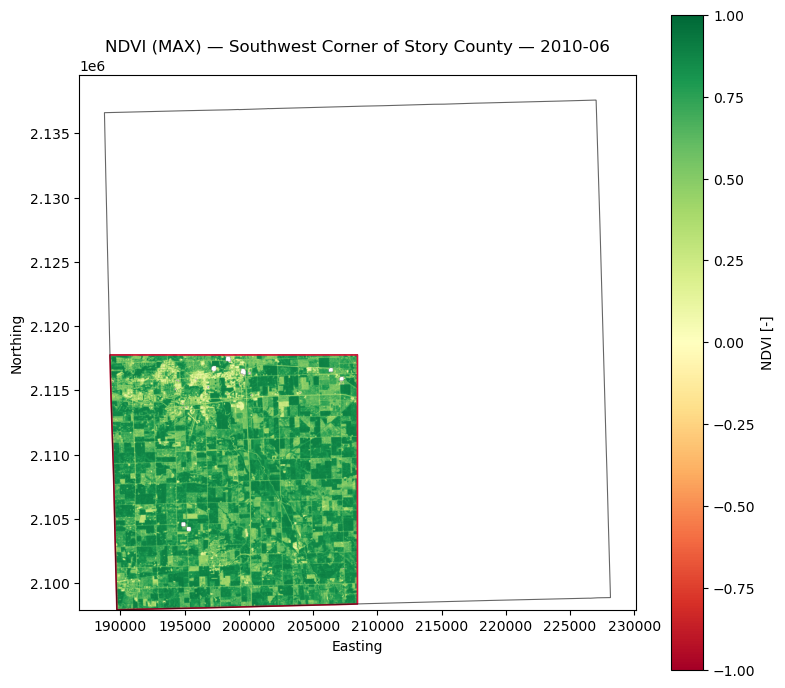

In [8]:
# --- Visualize NDVI for June 2010 in the Southwest Corner of Story County, Iowa ---

from pathlib import Path
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union
from shapely.geometry import box
import os

# ============ USER SETTINGS ============
YEAR   = 2010
MONTH  = "06"            # June
COUNTY_NAME = "Story"    # Iowa county name (case-insensitive)

# Size of the "corner" as a fraction of the county's width/height
# 0.5 = southwest quarter; 0.33 ≈ southwest ninth; 0.25 = southwest sixteenth, etc.
CORNER_FRACTION = 0.5    # (0 < fraction <= 1)

# Paths (Conowingo)
NDVI_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI"

# Optional: local boundaries; if None, falls back to Census TIGER
IOWA_STATE_PATH  = None
IOWA_COUNTY_PATH = None
# ======================================

# NDVI file (monthly statewide mosaic on the reference grid)
ndvi_path = NDVI_ROOT / f"{YEAR}" / f"{YEAR}_{MONTH}_NDVI_MAX_MOSAIC.tif"
if not ndvi_path.exists():
    raise FileNotFoundError(f"Missing NDVI mosaic: {ndvi_path}")

def load_iowa_layers():
    if IOWA_STATE_PATH and Path(IOWA_STATE_PATH).exists():
        iowa = gpd.read_file(IOWA_STATE_PATH)
        if "NAME" in iowa.columns:
            iowa = iowa[iowa["NAME"].str.lower().eq("iowa")].copy()
    else:
        states_url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip"
        iowa = gpd.read_file(states_url)
        iowa = iowa[iowa["NAME"].str.lower().eq("iowa")].copy()

    if IOWA_COUNTY_PATH and Path(IOWA_COUNTY_PATH).exists():
        counties = gpd.read_file(IOWA_COUNTY_PATH)
        if "STATEFP" in counties.columns:
            counties = counties[counties["STATEFP"] == "19"].copy()
        elif "STATE_NAME" in counties.columns:
            counties = counties[counties["STATE_NAME"].str.lower().eq("iowa")].copy()
    else:
        counties_url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_500k.zip"
        counties = gpd.read_file(counties_url)
        counties = counties[counties["STATEFP"] == "19"].copy()  # 19 = Iowa

    return iowa, counties

# --- Load boundaries
iowa, counties = load_iowa_layers()

# --- Read NDVI & align CRS
with rasterio.open(ndvi_path) as ds:
    ndvi_crs = ds.crs

if iowa.crs is None:
    iowa = iowa.set_crs("EPSG:4326", allow_override=True).to_crs(ndvi_crs)
else:
    iowa = iowa.to_crs(ndvi_crs)

if counties.crs is None:
    counties = counties.set_crs("EPSG:4326", allow_override=True).to_crs(ndvi_crs)
else:
    counties = counties.to_crs(ndvi_crs)

# --- Select Story County
name_col = "NAME" if "NAME" in counties.columns else counties.columns[0]
sel = counties[counties[name_col].str.lower() == COUNTY_NAME.lower()].copy()
if sel.empty:
    raise ValueError(f"County named '{COUNTY_NAME}' not found in Iowa county layer.")
county_geom = unary_union(sel.geometry.values)

# --- Build the southwest-corner polygon (by county bbox fractions)
minx, miny, maxx, maxy = county_geom.bounds
midx = minx + (maxx - minx) * CORNER_FRACTION  # vertical slice at fraction of width
midy = miny + (maxy - miny) * CORNER_FRACTION  # horizontal slice at fraction of height

# Southwest box = lower-left rectangle of the bbox, constrained by CORNER_FRACTION
sw_box = box(minx, miny, midx, midy)

# Constrain the box to the actual county shape (handles irregular shapes)
sw_corner_geom = county_geom.intersection(sw_box)
if sw_corner_geom.is_empty:
    raise RuntimeError("Computed southwest corner geometry is empty; try increasing CORNER_FRACTION.")

# --- Clip NDVI to SW corner
with rasterio.open(ndvi_path) as ds:
    ndvi_clip, clip_transform = rio_mask(ds, [sw_corner_geom], crop=True, filled=True)
    ndvi = ndvi_clip[0].astype("float32")
    nodata = ds.nodata

# Clean and clamp NDVI to [-1, 1]
if nodata is None:
    nodata = -9999.0
ndvi[(ndvi == nodata) | (~np.isfinite(ndvi)) | (ndvi < -1.0) | (ndvi > 1.0)] = np.nan

# Compute extent for plotting
H, W = ndvi.shape
left  = clip_transform.c
top   = clip_transform.f
px_w  = clip_transform.a
px_h  = clip_transform.e
right = left + W * px_w
bottom = top + H * px_h
extent_clip = [left, right, bottom, top]

# --- Plot: NDVI for the SW corner only
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(
    ndvi, origin="upper", extent=extent_clip, cmap="RdYlGn", vmin=-1.0, vmax=1.0
)

# Draw the SW-corner and county outline for reference
gpd.GeoSeries([sw_corner_geom], crs=counties.crs).boundary.plot(ax=ax, color="crimson", linewidth=1.2)
gpd.GeoSeries([county_geom], crs=counties.crs).boundary.plot(ax=ax, color="black", linewidth=0.8, alpha=0.6)

ax.set_title(f"NDVI (MAX) — Southwest Corner of {COUNTY_NAME} County — {YEAR}-{MONTH}")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("NDVI [-]")

plt.tight_layout()
plt.show()


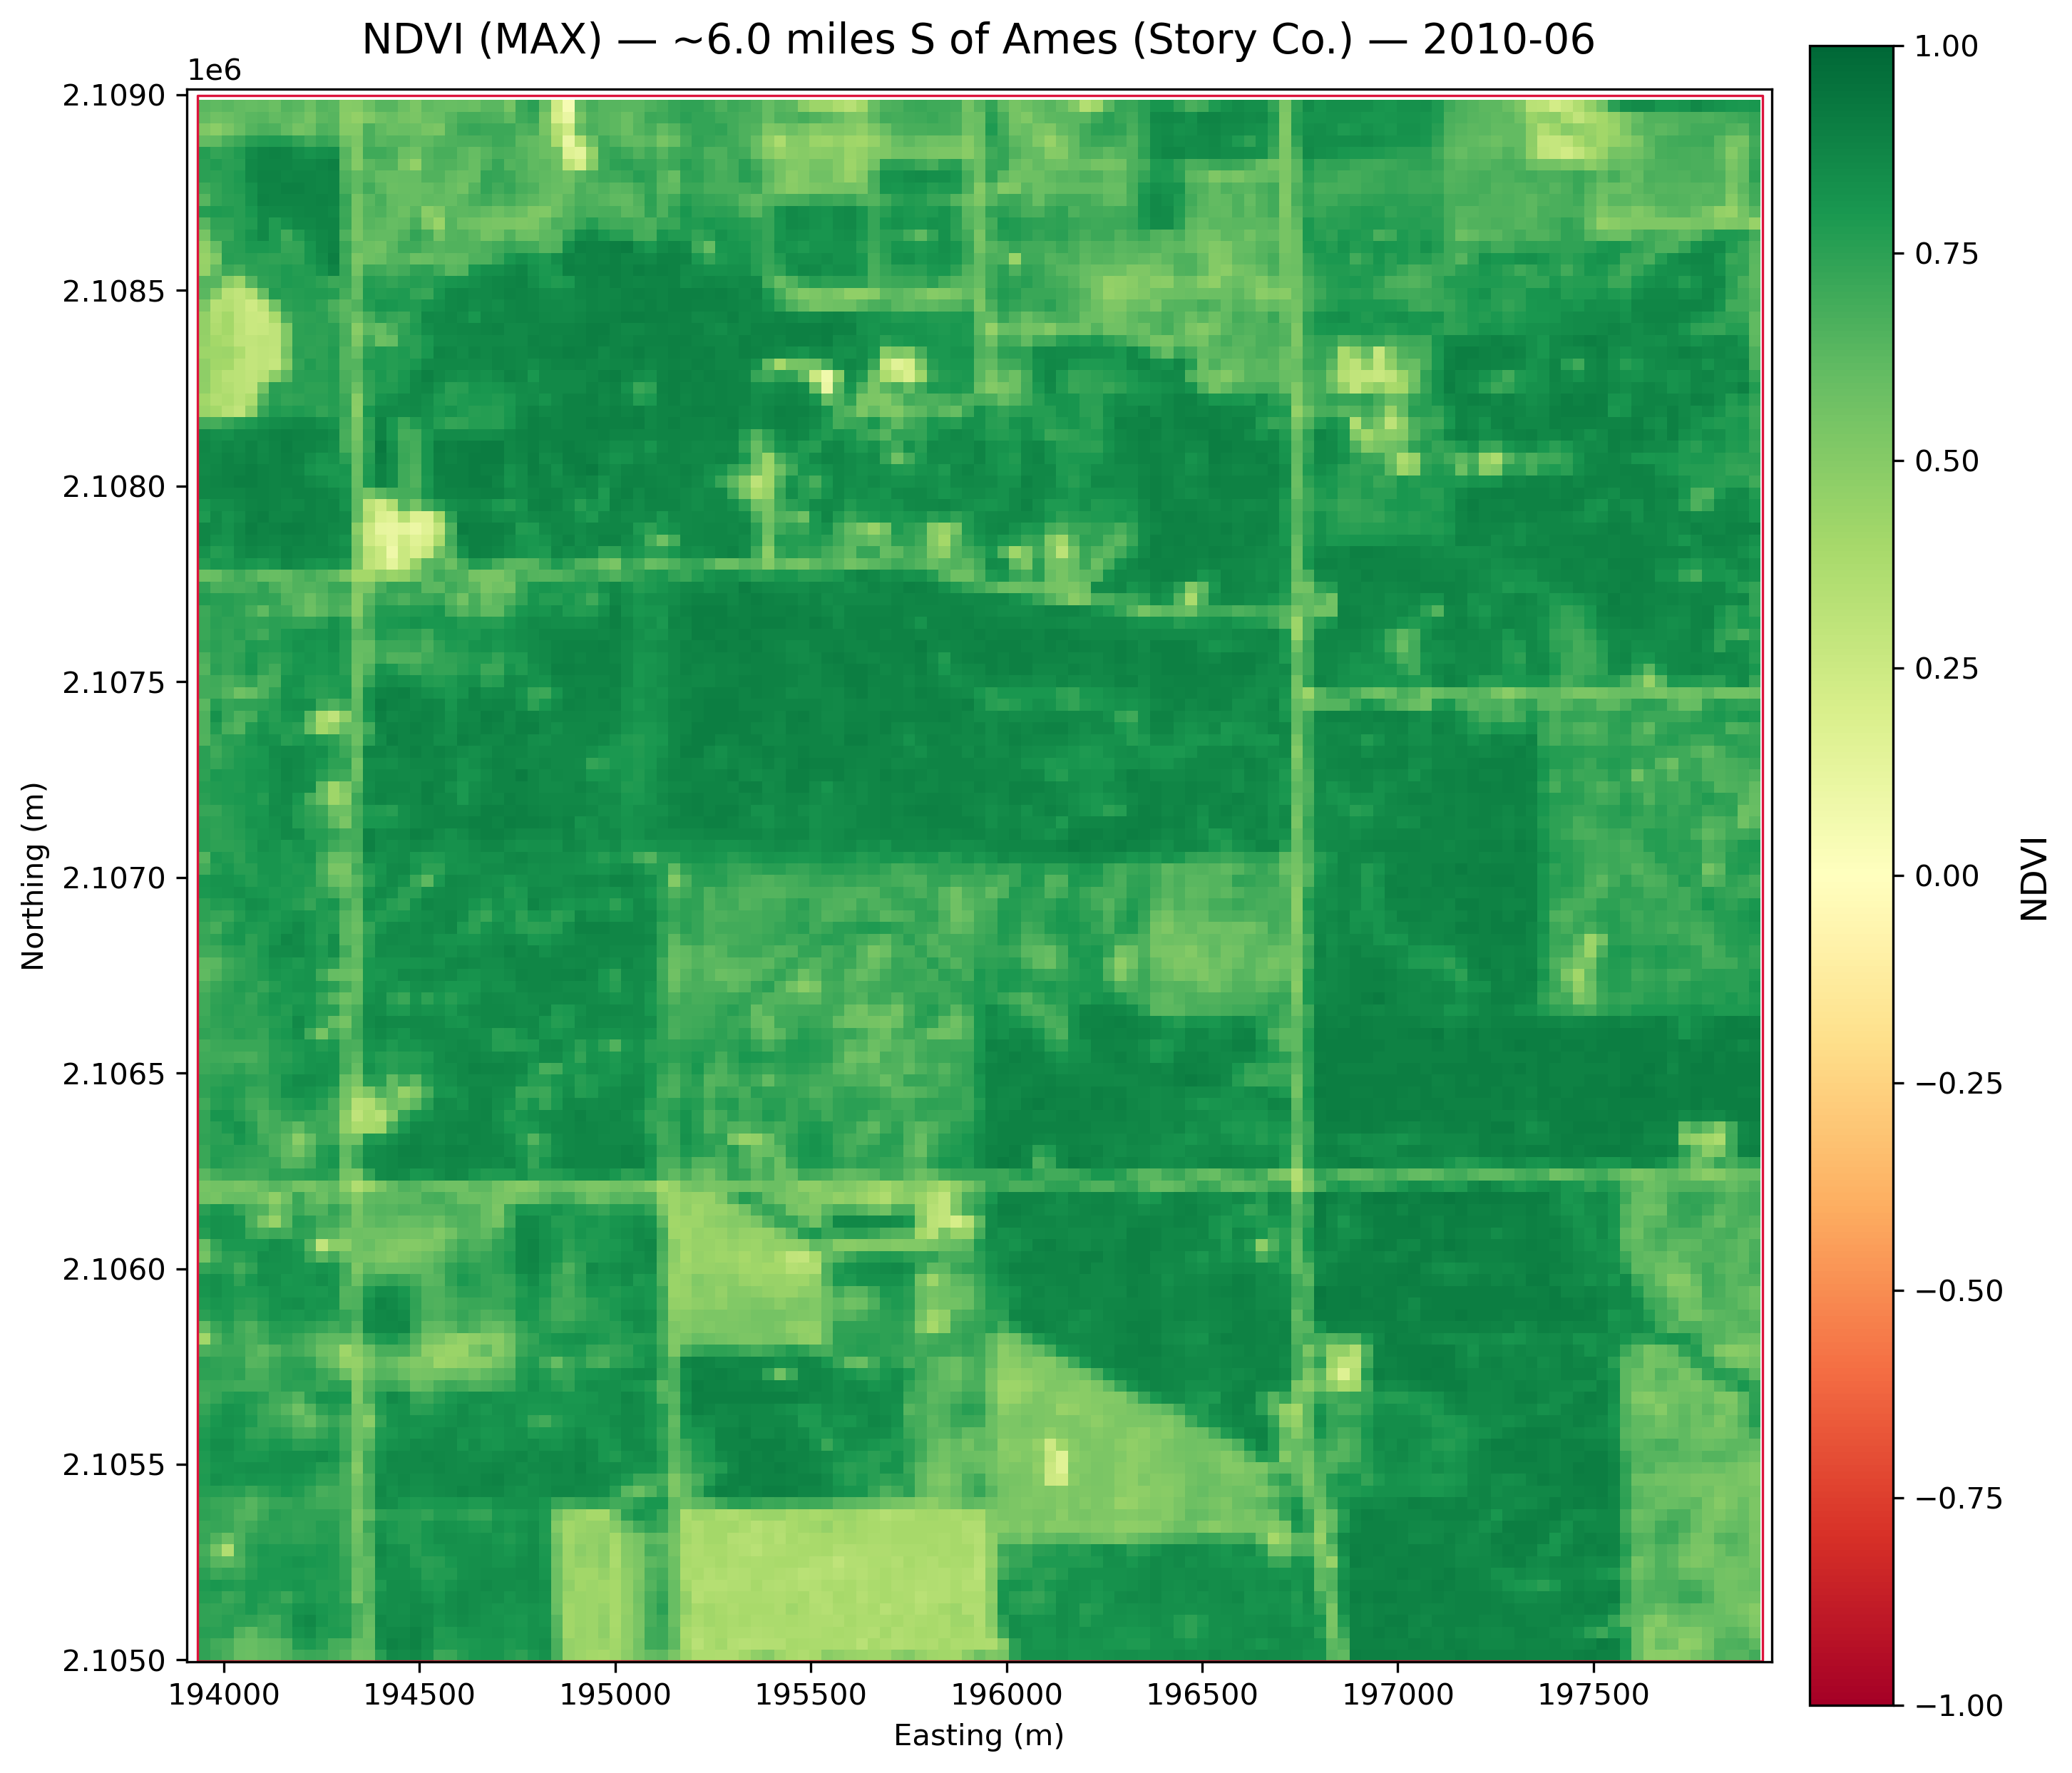

In [12]:
# --- NDVI (June 2010) ~6 miles south of Ames, Iowa (Story County), field-scale visualization (robust) ---

from pathlib import Path
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box, Point
from shapely.ops import unary_union, nearest_points
from pyproj import Geod, Transformer
import os

# ============ USER SETTINGS ============
YEAR   = 2010
MONTH  = "06"             # June
COUNTY_NAME = "Story"
AMES_LON = -93.62         # Ames, IA (approx)
AMES_LAT =  42.03
OFFSET_MILES_SOUTH = 6.0  # ~6 miles south of Ames (adjust as needed)
BOX_SIZE_KM = 4.0         # width/height of square ROI (try 2.0–6.0 km to tune field visibility)
# ======================================

# Paths (Conowingo)
NDVI_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI"
ndvi_path = NDVI_ROOT / f"{YEAR}" / f"{YEAR}_{MONTH}_NDVI_MAX_MOSAIC.tif"
if not ndvi_path.exists():
    raise FileNotFoundError(f"Missing NDVI mosaic: {ndvi_path}")

# --- Load Iowa counties (TIGER 2018, quick cartographic boundaries) and select Story
counties_url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_500k.zip"
counties = gpd.read_file(counties_url)
counties = counties[counties["STATEFP"] == "19"].copy()  # Iowa only
sel = counties[counties["NAME"].str.lower() == COUNTY_NAME.lower()].copy()
if sel.empty:
    raise ValueError(f"County named '{COUNTY_NAME}' not found in Iowa county layer.")

# --- Read NDVI, get CRS, and align county to raster CRS
with rasterio.open(ndvi_path) as ds:
    ndvi_crs = ds.crs
    ndvi_nodata = ds.nodata if ds.nodata is not None else -9999.0

sel = sel.to_crs(ndvi_crs)  # reproject county to match raster
county_geom = unary_union(sel.geometry.values)

# --- Compute target center: ~6 miles due south of Ames (geodesic) in lat/lon, then project to NDVI CRS
geod = Geod(ellps="WGS84")
dist_m = OFFSET_MILES_SOUTH * 1609.344
lon_s, lat_s, _ = geod.fwd(AMES_LON, AMES_LAT, 180.0, dist_m)

to_proj = Transformer.from_crs("EPSG:4326", ndvi_crs, always_xy=True)
x_c, y_c = to_proj.transform(lon_s, lat_s)
center_pt = Point(x_c, y_c)

# --- Ensure center is inside Story County; if not, snap to nearest point inside Story
if not county_geom.contains(center_pt):
    # nearest point on county boundary to center (could be boundary or interior depending on geometry)
    np_on_geom, _ = nearest_points(county_geom, center_pt)
    # If the nearest point is exactly on boundary, nudge slightly inside with a tiny buffer intersection
    tiny = 1.0  # meters
    center_pt = np_on_geom
    if not county_geom.contains(center_pt):
        center_pt = county_geom.buffer(tiny).intersection(center_pt.buffer(tiny)).centroid

# --- Build square ROI around (possibly snapped) center and intersect with county to keep it inside Story
half = (BOX_SIZE_KM * 1000.0) / 2.0
roi_box = box(center_pt.x - half, center_pt.y - half, center_pt.x + half, center_pt.y + half)
roi_geom = county_geom.intersection(roi_box)

# If for any numerical reason the intersection is empty, try a tiny inward buffer on the county to avoid sliver issues
if roi_geom.is_empty:
    roi_geom = county_geom.buffer(-0.5).intersection(roi_box)  # shrink county inward by 0.5 m
if roi_geom.is_empty:
    raise RuntimeError("ROI is empty after snapping—try increasing BOX_SIZE_KM or reducing OFFSET_MILES_SOUTH.")

# --- Clip NDVI to ROI
with rasterio.open(ndvi_path) as ds:
    ndvi_clip, clip_transform = rio_mask(ds, [roi_geom], crop=True, filled=True)
    ndvi = ndvi_clip[0].astype("float32")

# --- Clean and clamp NDVI to [-1, 1]
ndvi[(ndvi == ndvi_nodata) | (~np.isfinite(ndvi)) | (ndvi < -1.0) | (ndvi > 1.0)] = np.nan

# --- Compute extent for plotting
H, W = ndvi.shape
left, top = clip_transform.c, clip_transform.f
px_w, px_h = clip_transform.a, clip_transform.e
right = left + W * px_w
bottom = top + H * px_h
extent_clip = [left, right, bottom, top]

# --- Plot: NDVI only, big and clean for figures
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300)
im = ax.imshow(
    ndvi, origin="upper", extent=extent_clip,
    cmap="RdYlGn", vmin=-1.0, vmax=1.0
)

# Optional: thin ROI outline for context
gpd.GeoSeries([roi_geom], crs=sel.crs).boundary.plot(ax=ax, color="crimson", linewidth=0.8)

ax.set_title(f"NDVI (MAX) — ~{OFFSET_MILES_SOUTH:.1f} miles S of Ames (Story Co.) — {YEAR}-{MONTH}", fontsize=14, pad=12)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.tick_params(axis='both', which='major', labelsize=10)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("NDVI", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


/opt/anaconda3/envs/CBP_random_forest/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/envs/CBP_random_forest/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


[OK] Saved figure → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/figures/ndvi_story_sw_overlay_2010_06.png


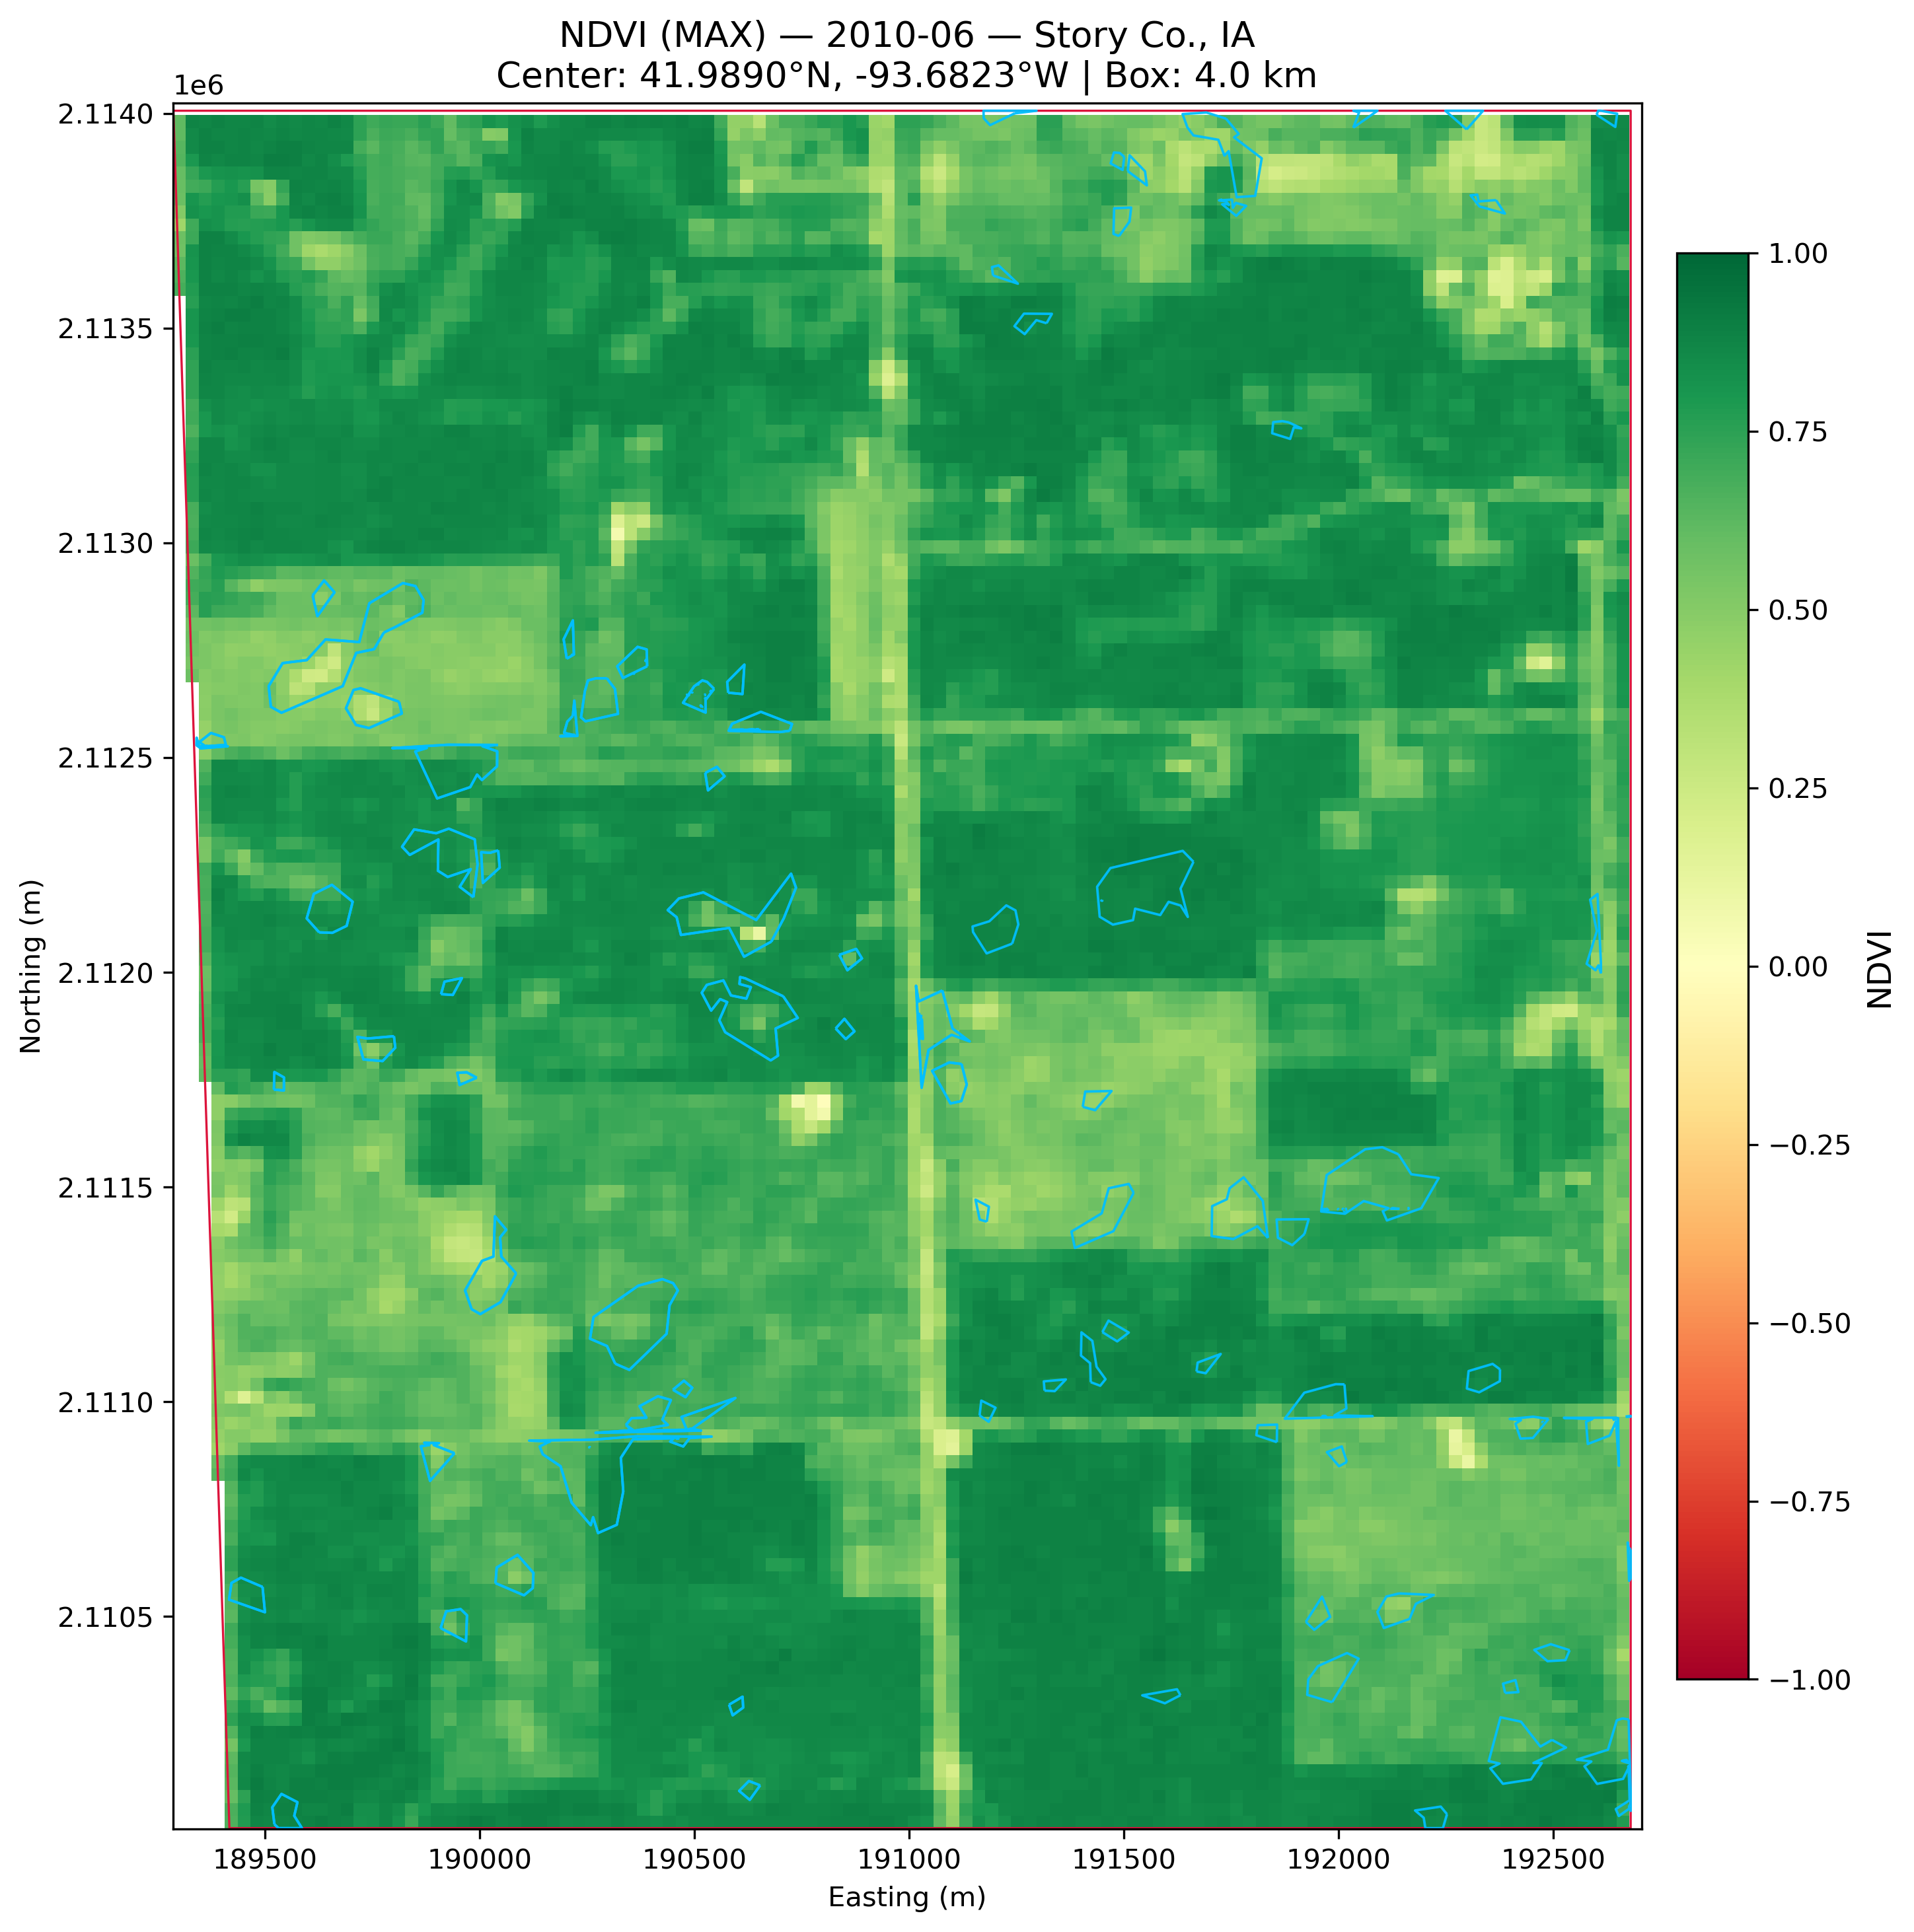

In [16]:
# --- NDVI (June 2010) near 41.9890°N, −93.6823°W (Story Co., IA), with historical wetland overlays ---

from pathlib import Path
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box, Point
from shapely.ops import unary_union, nearest_points
from pyproj import Transformer
import os

# ============ USER SETTINGS ============
YEAR   = 2010
MONTH  = "06"             # June (uses monthly NDVI MAX mosaic)
COUNTY_NAME = "Story"

# Precise center (approx. 6 mi south of Ames, as provided)
CENTER_LAT = 41.9890
CENTER_LON = -93.6823

# Square window size centered at the point (km).
# Decrease to zoom further into individual fields (e.g., 2.0–4.0 km)
BOX_SIZE_KM = 4.0

# Paths (Conowingo)
NDVI_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI"
WETLANDS_PATH = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "Historical_Wetlands_FILT/Historical_Wetlands_FILT_simp_5070.shp"

# Optional output (set to None to skip saving)
OUT_PNG = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "figures/ndvi_story_sw_overlay_2010_06.png"
# ======================================

# ---- Load NDVI mosaic
ndvi_path = NDVI_ROOT / f"{YEAR}" / f"{YEAR}_{MONTH}_NDVI_MAX_MOSAIC.tif"
if not ndvi_path.exists():
    raise FileNotFoundError(f"Missing NDVI mosaic: {ndvi_path}")

with rasterio.open(ndvi_path) as ds:
    ndvi_crs = ds.crs
    ndvi_nodata = ds.nodata if ds.nodata is not None else -9999.0

# ---- Load Story County (TIGER 2018, cartographic boundaries)
counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_500k.zip")
counties = counties[counties["STATEFP"] == "19"].copy()  # Iowa only
sel = counties[counties["NAME"].str.lower() == COUNTY_NAME.lower()].copy()
if sel.empty:
    raise ValueError(f"County named '{COUNTY_NAME}' not found in Iowa.")
sel = sel.to_crs(ndvi_crs)
county_geom = unary_union(sel.geometry.values)

# ---- Build center point in NDVI CRS
to_proj = Transformer.from_crs("EPSG:4326", ndvi_crs, always_xy=True)
x_c, y_c = to_proj.transform(CENTER_LON, CENTER_LAT)
center_pt = Point(x_c, y_c)

# If the center falls outside Story County, snap to the nearest point on/inside the county
if not county_geom.contains(center_pt):
    snap_on_geom, _ = nearest_points(county_geom, center_pt)
    center_pt = snap_on_geom
    # If still exactly on boundary, nudge slightly inside
    if not county_geom.contains(center_pt):
        center_pt = county_geom.buffer(1.0).intersection(center_pt.buffer(1.0)).centroid

# ---- Build square ROI and restrict to Story County
half = (BOX_SIZE_KM * 1000.0) / 2.0
roi_box = box(center_pt.x - half, center_pt.y - half, center_pt.x + half, center_pt.y + half)
roi_geom = county_geom.intersection(roi_box)
if roi_geom.is_empty:
    # small inward buffer to avoid slivers
    roi_geom = county_geom.buffer(-0.5).intersection(roi_box)
if roi_geom.is_empty:
    raise RuntimeError("ROI is empty after snapping—adjust BOX_SIZE_KM or center coordinates.")

roi_gdf = gpd.GeoDataFrame(geometry=[roi_geom], crs=ndvi_crs)

# ---- Clip NDVI to ROI
with rasterio.open(ndvi_path) as ds:
    ndvi_clip, clip_transform = rio_mask(ds, [roi_geom], crop=True, filled=True)
    ndvi = ndvi_clip[0].astype("float32")

# Clean/clamp NDVI to [-1, 1]
ndvi[(ndvi == ndvi_nodata) | (~np.isfinite(ndvi)) | (ndvi < -1.0) | (ndvi > 1.0)] = np.nan

# Plot extent (projected units)
H, W = ndvi.shape
left, top = clip_transform.c, clip_transform.f
px_w, px_h = clip_transform.a, clip_transform.e
right = left + W * px_w
bottom = top + H * px_h
extent_clip = [left, right, bottom, top]

# ---- Load & clip historical wetlands to ROI
wetlands = gpd.read_file(WETLANDS_PATH)
if wetlands.crs is None:
    # Set to your dataset's known CRS if missing
    wetlands = wetlands.set_crs("EPSG:5070", allow_override=True)
wetlands = wetlands.to_crs(ndvi_crs)
wetlands_clip = gpd.clip(wetlands, roi_gdf)

# ---- Figure-only, enlarged and high-DPI
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300)
im = ax.imshow(
    ndvi,
    origin="upper",
    extent=extent_clip,
    cmap="RdYlGn",
    vmin=-1.0, vmax=1.0
)

# Optional: ROI outline
roi_gdf.boundary.plot(ax=ax, color="crimson", linewidth=0.8)

# Wetland boundaries on top
if not wetlands_clip.empty:
    wetlands_clip.boundary.plot(ax=ax, linewidth=0.9, edgecolor="deepskyblue", alpha=0.95)

ax.set_title(f"NDVI (MAX) — {YEAR}-{MONTH} — {COUNTY_NAME} Co., IA\nCenter: {CENTER_LAT:.4f}°N, {CENTER_LON:.4f}°W | Box: {BOX_SIZE_KM:.1f} km", fontsize=13)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.tick_params(axis='both', labelsize=10)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("NDVI", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()

# Optional save
if OUT_PNG is not None:
    OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
    print(f"[OK] Saved figure → {OUT_PNG}")

plt.show()


In [ ]:
#EVI2

[OK] Saved figures →
  /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/figures/evi2_roi_2018_07.png
  /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/figures/evi2_roi_2018_07.jpg


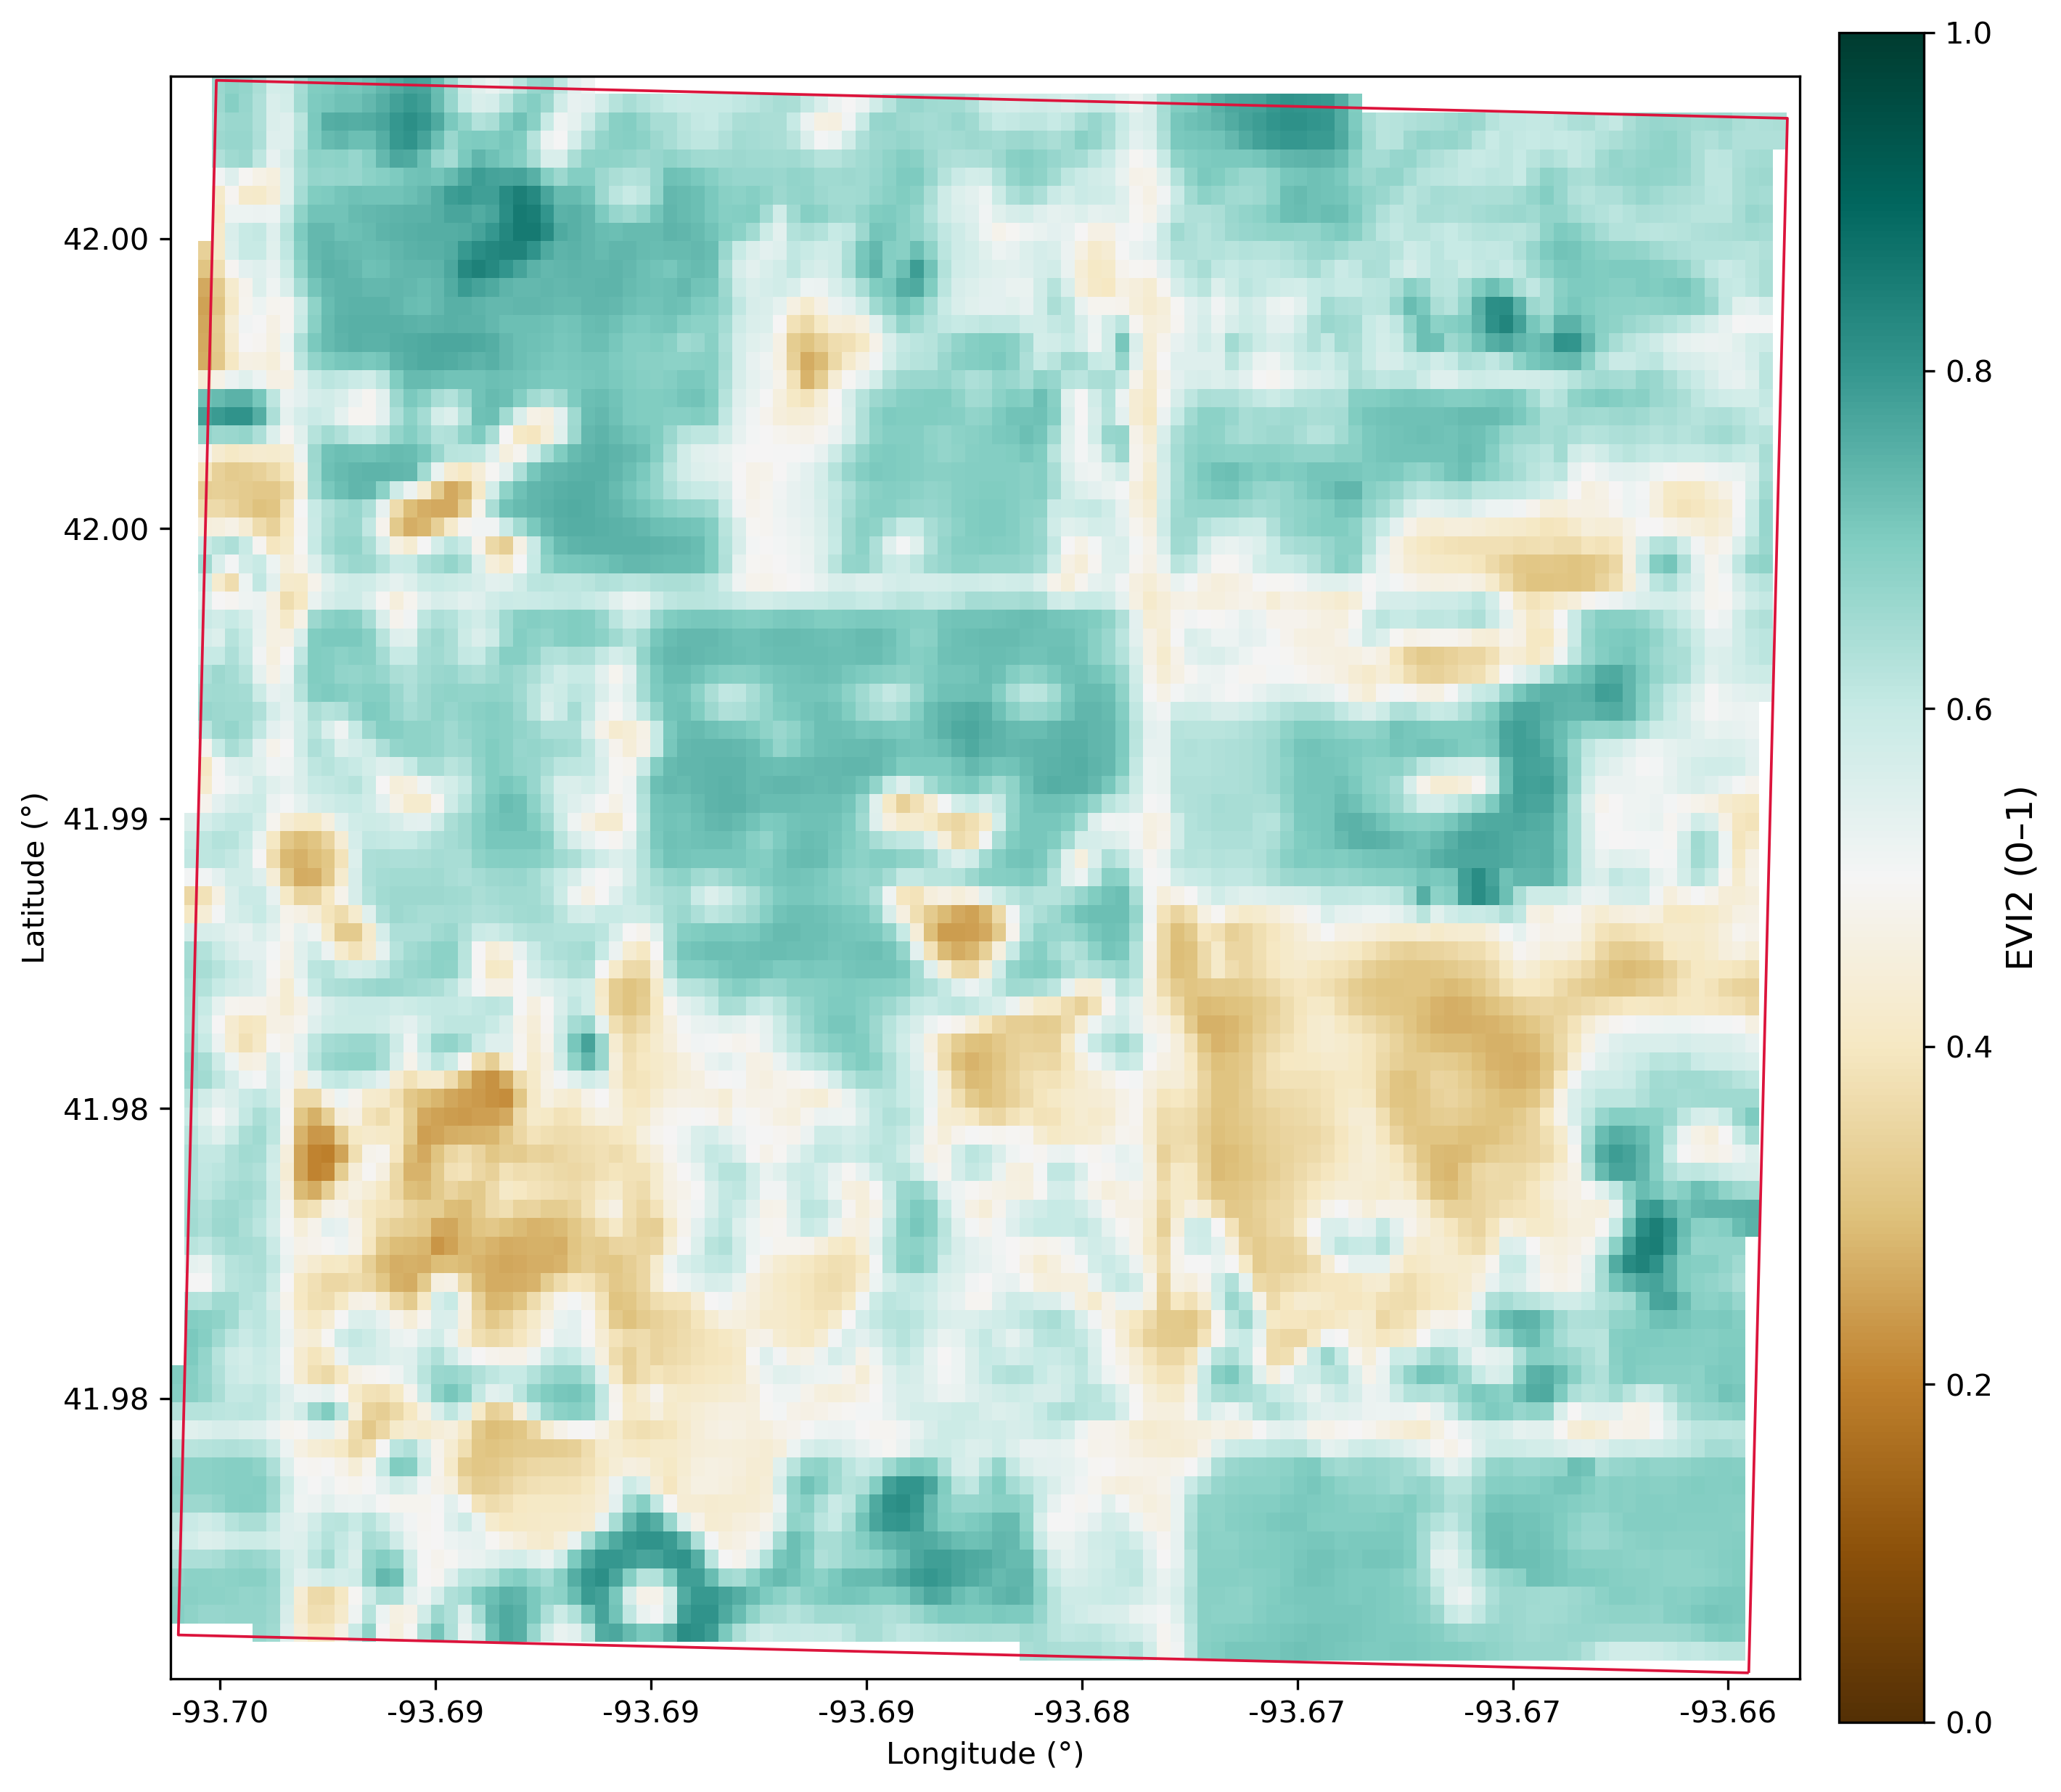

In [26]:
# --- EVI2 (July 2013) near 41.9890°N, −93.6823°W, square ROI without county/wetland constraints ---

from pathlib import Path
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from shapely.geometry import box, Point
from pyproj import Transformer
import geopandas as gpd

from matplotlib import colormaps
cmap = colormaps["BrBG"]

# ============ USER SETTINGS ============
YEAR   = 2018
MONTH  = "07"
CENTER_LAT = 41.9890
CENTER_LON = -93.6823
BOX_SIZE_KM = 3.0

MOSAIC_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI"
OUT_DIR     = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "figures"
# ======================================

# ---- Load EVI2 mosaic (your path convention)
evi2_path = MOSAIC_ROOT / f"{YEAR}" / f"{YEAR}_{MONTH}_MAX" / f"EVI2_{YEAR}_{MONTH}_MAX_MOSAIC.tif"
if not evi2_path.exists():
    raise FileNotFoundError(f"Missing EVI2 mosaic: {evi2_path}")

with rasterio.open(evi2_path) as ds:
    src_crs = ds.crs
    src_nodata = ds.nodata if ds.nodata is not None else -9999.0

# ---- Build center point in source CRS
to_proj = Transformer.from_crs("EPSG:4326", src_crs, always_xy=True)
x_c, y_c = to_proj.transform(CENTER_LON, CENTER_LAT)
center_pt = Point(x_c, y_c)

# ---- Build square ROI
half = (BOX_SIZE_KM * 1000.0) / 2.0
roi_box = box(center_pt.x - half, center_pt.y - half,
              center_pt.x + half, center_pt.y + half)

# ---- Clip EVI2 to ROI
with rasterio.open(evi2_path) as ds:
    evi2_clip, clip_transform = rio_mask(ds, [roi_box], crop=True, filled=True)
    evi2 = evi2_clip[0].astype("float32")

# ---- Clean EVI2
evi2[(evi2 == src_nodata) | (~np.isfinite(evi2)) |
     (evi2 < -0.2) | (evi2 > 1.2)] = np.nan

# ---- Reproject to WGS84 for lat/lon display
dst_crs = "EPSG:4326"
H, W = evi2.shape
left, bottom, right, top = array_bounds(H, W, clip_transform)

dst_transform, dst_width, dst_height = calculate_default_transform(
    src_crs, dst_crs, W, H,
    left=left, bottom=bottom, right=right, top=top
)

evi2_ll = np.full((dst_height, dst_width), np.nan, dtype="float32")
reproject(
    source=evi2,
    destination=evi2_ll,
    src_transform=clip_transform,
    src_crs=src_crs,
    src_nodata=np.nan,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    dst_nodata=np.nan,
    resampling=Resampling.bilinear,
)

# ---- Plot extent in lon/lat
minx, miny, maxx, maxy = array_bounds(
    evi2_ll.shape[0], evi2_ll.shape[1], dst_transform
)
extent_ll = [minx, maxx, miny, maxy]

# ---- ROI outline (WGS84)
roi_gdf_ll = gpd.GeoDataFrame(
    geometry=[roi_box], crs=src_crs
).to_crs(dst_crs)

# ---- Colormap
from matplotlib import colormaps
import os
cmap = colormaps["BrBG"]

# ---- Figure
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300)
im = ax.imshow(
    evi2_ll,
    origin="upper",
    extent=extent_ll,
    cmap=cmap,
    vmin=0.0, vmax=1.0
)

# ROI outline
roi_gdf_ll.boundary.plot(ax=ax, color="crimson", linewidth=0.9)

# ---- Formatting
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=10)

# ---- Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("EVI2 (0–1)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()

# ---- Save
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_png = OUT_DIR / f"evi2_roi_{YEAR}_{MONTH}.png"
out_jpg = OUT_DIR / f"evi2_roi_{YEAR}_{MONTH}.jpg"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_jpg, dpi=300, bbox_inches="tight")
print(f"[OK] Saved figures →\n  {out_png}\n  {out_jpg}")

plt.show()


[OK] Saved figures →
  /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/figures/ndvi_roi_2010_07.png
  /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/figures/ndvi_roi_2010_07.jpg


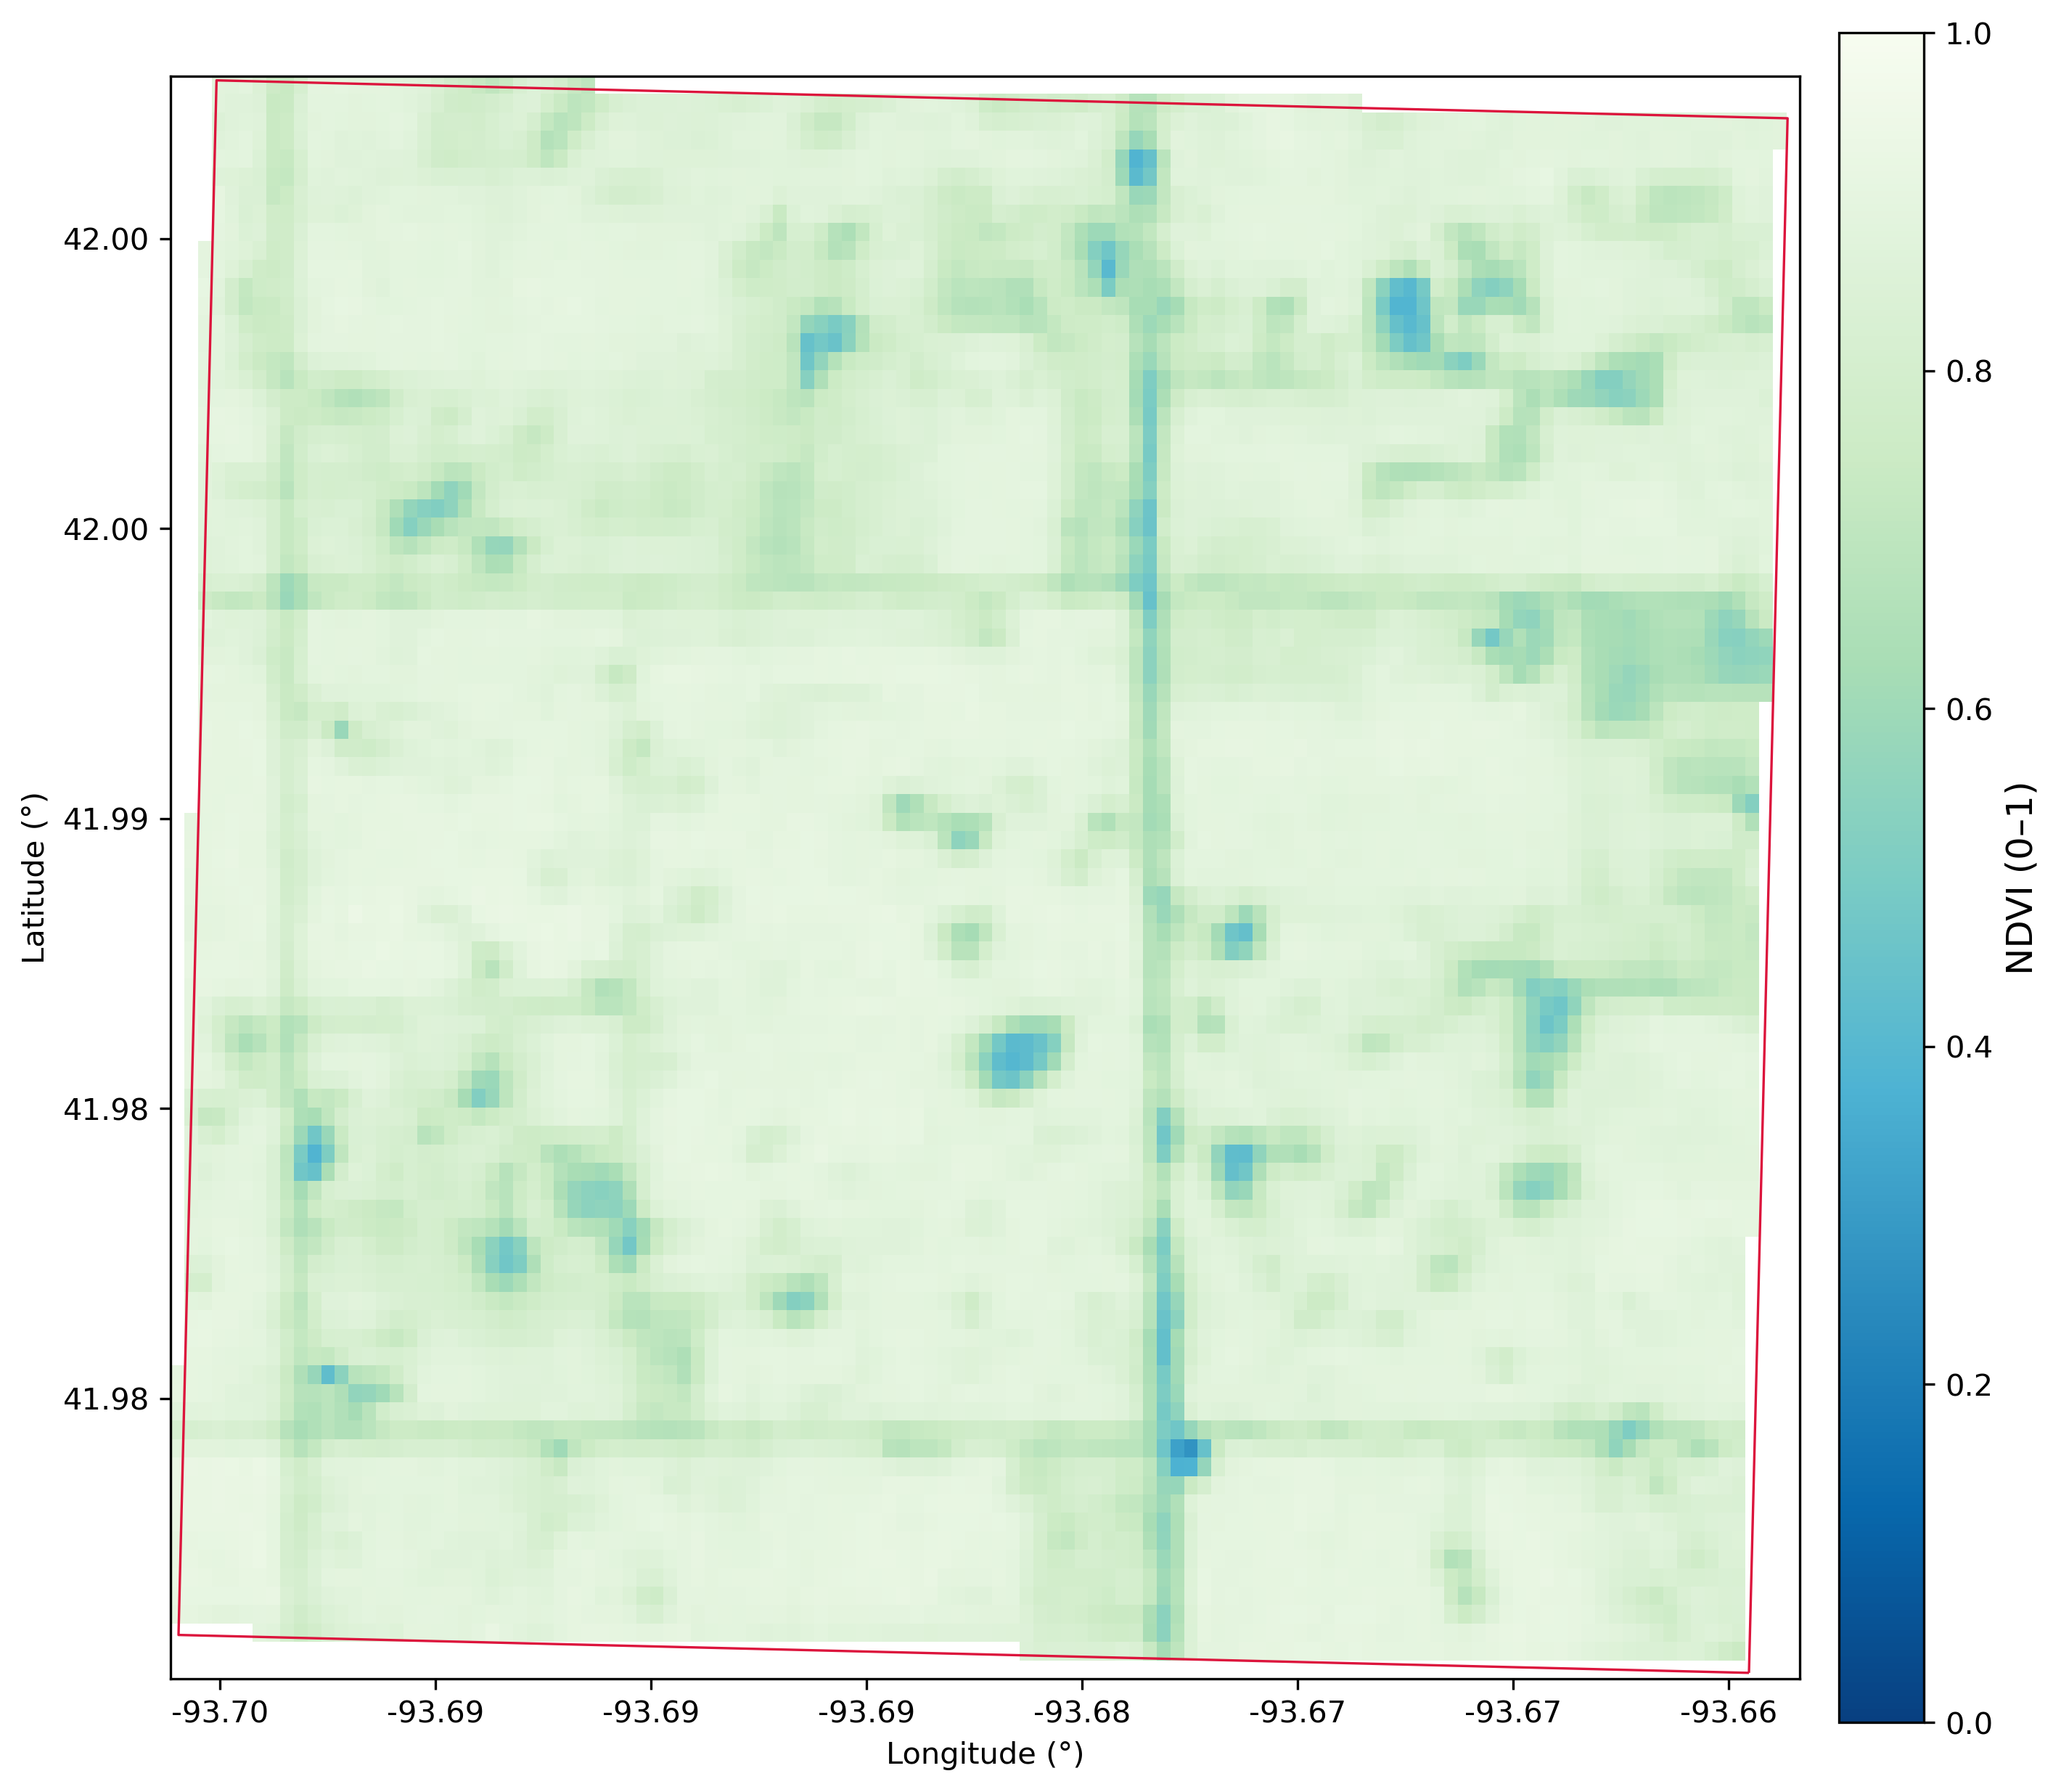

In [42]:
# --- NDVI (June 2010) near 41.9890°N, −93.6823°W, square ROI without county/wetland constraints ---
from pathlib import Path
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from shapely.geometry import box, Point
from pyproj import Transformer
import geopandas as gpd

# ============ USER SETTINGS ============
YEAR   = 2010
MONTH  = "07"             # June (uses monthly NDVI MAX mosaic)
CENTER_LAT = 41.9890
CENTER_LON = -93.6823
BOX_SIZE_KM = 3.0         # Square window size centered at the point (km)
NDVI_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI"
OUT_DIR = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "figures"
# ======================================

# ---- Load NDVI mosaic
ndvi_path = NDVI_ROOT / f"{YEAR}" / f"{YEAR}_{MONTH}_NDVI_MAX_MOSAIC.tif"
if not ndvi_path.exists():
    raise FileNotFoundError(f"Missing NDVI mosaic: {ndvi_path}")

with rasterio.open(ndvi_path) as ds:
    ndvi_crs = ds.crs
    ndvi_nodata = ds.nodata if ds.nodata is not None else -9999.0

# ---- Build center point in NDVI CRS
to_proj = Transformer.from_crs("EPSG:4326", ndvi_crs, always_xy=True)
x_c, y_c = to_proj.transform(CENTER_LON, CENTER_LAT)
center_pt = Point(x_c, y_c)

# ---- Build square ROI (no county restriction)
half = (BOX_SIZE_KM * 1000.0) / 2.0
roi_box = box(center_pt.x - half, center_pt.y - half, center_pt.x + half, center_pt.y + half)

# ---- Clip NDVI to ROI
with rasterio.open(ndvi_path) as ds:
    ndvi_clip, clip_transform = rio_mask(ds, [roi_box], crop=True, filled=True)
    ndvi = ndvi_clip[0].astype("float32")
    src_crs = ds.crs

# ---- Clean NDVI and constrain to [0, 1]
ndvi[(ndvi == ndvi_nodata) | (~np.isfinite(ndvi)) | (ndvi < 0.0) | (ndvi > 1.0)] = np.nan

# ---- Reproject to WGS84 for lat/lon display
dst_crs = "EPSG:4326"
H, W = ndvi.shape
left, bottom, right, top = array_bounds(H, W, clip_transform)

dst_transform, dst_width, dst_height = calculate_default_transform(
    src_crs, dst_crs, W, H, left=left, bottom=bottom, right=right, top=top
)

ndvi_ll = np.full((dst_height, dst_width), np.nan, dtype="float32")
reproject(
    source=ndvi,
    destination=ndvi_ll,
    src_transform=clip_transform,
    src_crs=src_crs,
    src_nodata=np.nan,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    dst_nodata=np.nan,
    resampling=Resampling.bilinear,
)

# ---- Plot extent in lon/lat
minx, miny, maxx, maxy = array_bounds(ndvi_ll.shape[0], ndvi_ll.shape[1], dst_transform)
extent_ll = [minx, maxx, miny, maxy]

# ---- Use reversed ColorBrewer YlGn (light yellow → dark green)
from matplotlib.colors import ListedColormap
from matplotlib import colormaps
import os
cmap = colormaps["GnBu_r"]  # reversed version (light yellow → dark green)
# cmap = colormaps["YlGn"]  # reversed version (light yellow → dark green)

# ---- Figure setup
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300)
im = ax.imshow(
    ndvi_ll,
    origin="upper",
    extent=extent_ll,
    cmap=cmap,
    vmin=0.0, vmax=1.0
)

# ---- ROI outline (in WGS84)
roi_gdf = gpd.GeoDataFrame(geometry=[roi_box], crs=src_crs).to_crs(dst_crs)
roi_gdf.boundary.plot(ax=ax, color="crimson", linewidth=0.8)

# ---- Formatting
#ax.set_title(
#    f"NDVI (MAX) — {YEAR}-{MONTH}\nCenter: {CENTER_LAT:.4f}°N, {abs(CENTER_LON):.4f}°W | Box: {BOX_SIZE_KM:.1f} km",
#    fontsize=13
#)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

# Format tick labels (two decimals, no scientific notation)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=10)

# ---- Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("NDVI (0–1)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()

# ---- Save figure (both PNG and JPEG)
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_png = OUT_DIR / f"ndvi_roi_{YEAR}_{MONTH}.png"
out_jpg = OUT_DIR / f"ndvi_roi_{YEAR}_{MONTH}.jpg"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_jpg, dpi=300, bbox_inches="tight")
print(f"[OK] Saved figures →\n  {out_png}\n  {out_jpg}")

plt.show()


[OK] Saved figure → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/figures/ndvi_roi_2010_06_wetlands.png


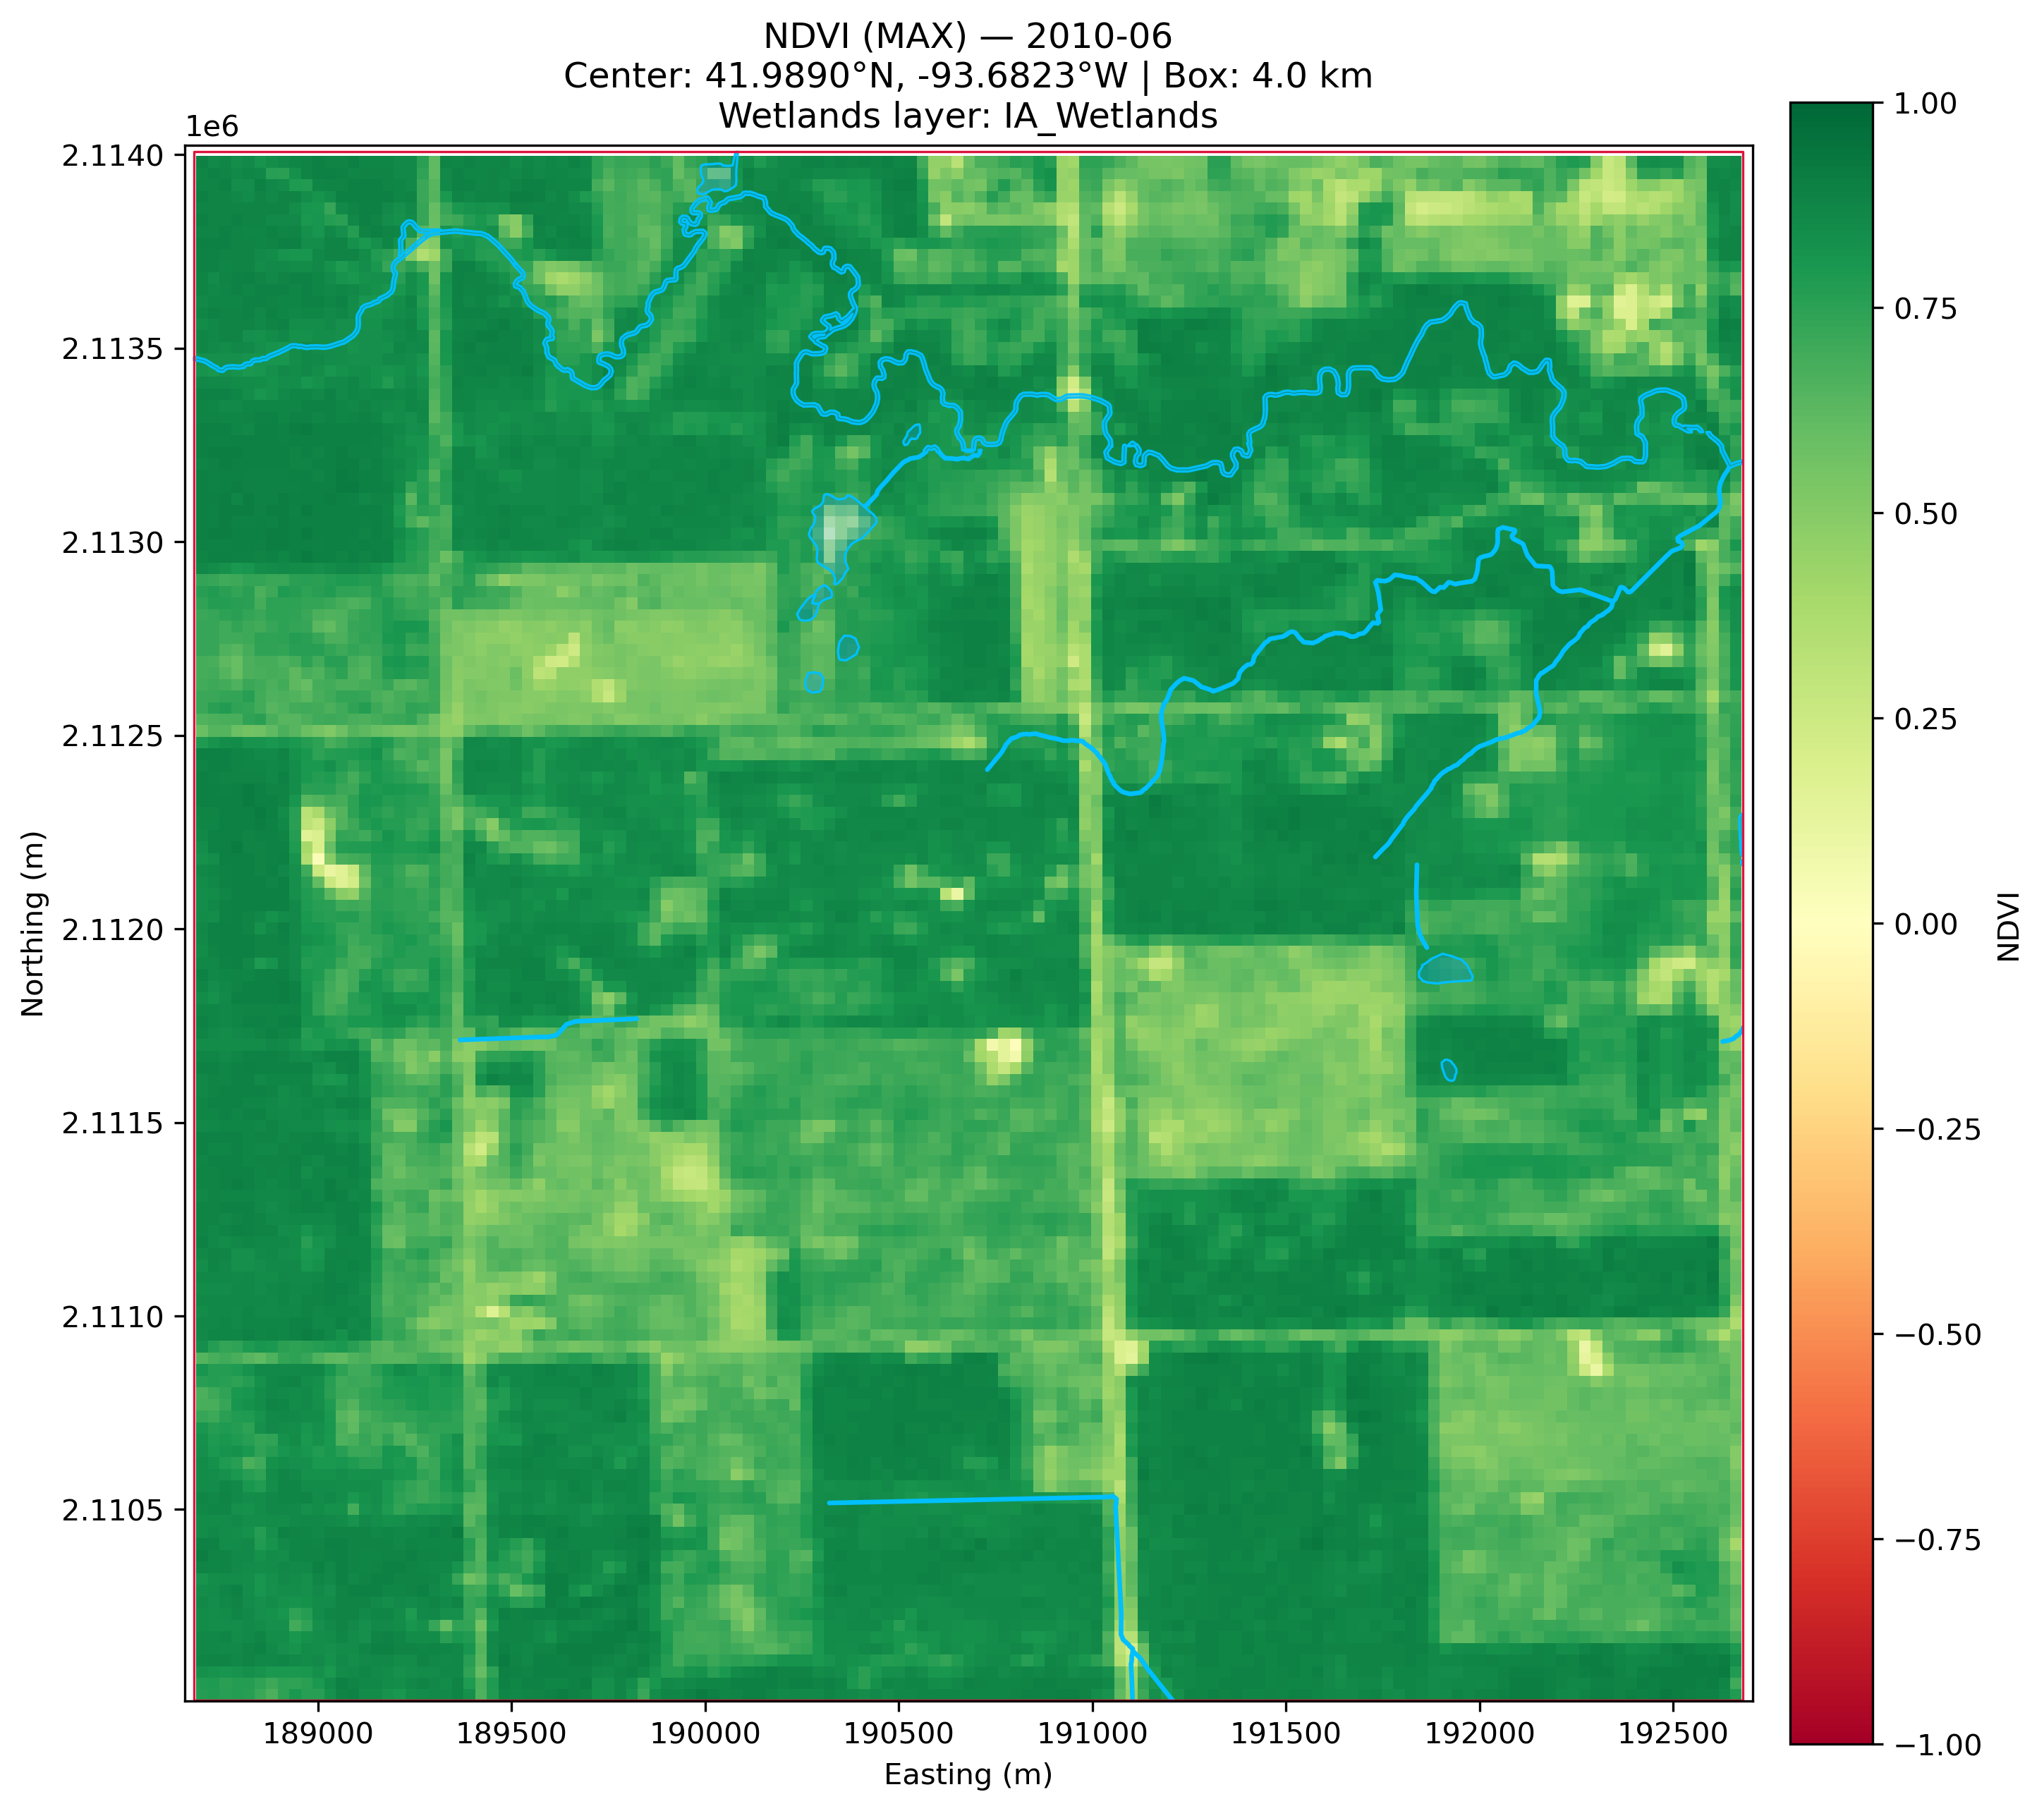

In [35]:
# --- NDVI (June 2010) near 41.9890°N, −93.6823°W, square ROI + Iowa wetlands overlay (explicit layer) ---

from pathlib import Path
import warnings

import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import shapely
from pyproj import Transformer
import os

# ============ USER SETTINGS ============
YEAR   = 2010
MONTH  = "06"   # June (monthly NDVI MAX mosaic)

CENTER_LAT = 41.9890
CENTER_LON = -93.6823
BOX_SIZE_KM = 4.0

NDVI_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI"
WETLANDS_GPKG = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NWI/IA_Wetlands_Geopackage.gpkg"
WETLANDS_LAYER = "IA_Wetlands"  # explicit layer to avoid auto-picking

OUT_PNG = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "figures/ndvi_roi_2010_06_wetlands.png"
# ======================================

# Silence noisy multi-layer warning on metadata peek
warnings.filterwarnings(
    "ignore",
    message=r".*More than one layer found.*IA_Wetlands_Geopackage\.gpkg.*"
)

def clean_geoms(gdf, grid=None):
    g = gdf.loc[gdf.geometry.notnull()].copy()
    g = g[~g.geometry.is_empty].copy()
    if grid is not None:
        g["geometry"] = g.geometry.apply(lambda geom: shapely.set_precision(geom, grid))
    def _repair(geom):
        if shapely.is_valid(geom):
            return geom
        fixed = shapely.make_valid(geom)
        if fixed.is_empty:
            fixed = geom.buffer(0)
        return fixed
    g["geometry"] = g.geometry.apply(_repair)
    g = g.explode(index_parts=False, ignore_index=True)
    g = g[g.geometry.notnull()]
    g = g[~g.geometry.is_empty]
    return g

# ---- NDVI + ROI ----
ndvi_path = NDVI_ROOT / f"{YEAR}" / f"{YEAR}_{MONTH}_NDVI_MAX_MOSAIC.tif"
if not ndvi_path.exists():
    raise FileNotFoundError(f"Missing NDVI mosaic: {ndvi_path}")

with rasterio.open(ndvi_path) as ds:
    ndvi_crs = ds.crs
    ndvi_nodata = ds.nodata if ds.nodata is not None else -9999.0

# Center point -> NDVI CRS
to_proj = Transformer.from_crs("EPSG:4326", ndvi_crs, always_xy=True)
x_c, y_c = to_proj.transform(CENTER_LON, CENTER_LAT)

half = (BOX_SIZE_KM * 1000.0) / 2.0
roi_box = box(x_c - half, y_c - half, x_c + half, y_c + half)
roi_gdf = gpd.GeoDataFrame(geometry=[roi_box], crs=ndvi_crs)

# Clip NDVI to ROI
with rasterio.open(ndvi_path) as ds:
    ndvi_clip, clip_transform = rio_mask(ds, [roi_box], crop=True, filled=True)
    ndvi = ndvi_clip[0].astype("float32")

ndvi[(ndvi == ndvi_nodata) | (~np.isfinite(ndvi)) | (ndvi < -1.0) | (ndvi > 1.0)] = np.nan

H, W = ndvi.shape
left, top = clip_transform.c, clip_transform.f
px_w, px_h = clip_transform.a, clip_transform.e
right = left + W * px_w
bottom = top + H * px_h
extent_clip = [left, right, bottom, top]

# ---- Wetlands (explicit layer, bbox read, CRS-safe clip) ----
if not WETLANDS_GPKG.exists():
    raise FileNotFoundError(f"Wetlands GeoPackage not found: {WETLANDS_GPKG}")

xmin, ymin, xmax, ymax = roi_gdf.total_bounds
wetlands = gpd.read_file(WETLANDS_GPKG, layer=WETLANDS_LAYER, bbox=(xmin, ymin, xmax, ymax))

# If layer lacks CRS, assume EPSG:5070 (CONUS Albers), common for NWI exports
if wetlands.crs is None:
    wetlands = wetlands.set_crs("EPSG:5070", allow_override=True)

# Clean + keep polygons
wetlands = clean_geoms(wetlands, grid=0.01)
wetlands = wetlands[wetlands.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# Clip in wetlands CRS (reproject ROI → wetlands CRS), then project back to NDVI CRS
roi_in_wet_crs = roi_gdf.to_crs(wetlands.crs)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*invalid value encountered in intersection.*")
    wetlands_clip = gpd.clip(wetlands, roi_in_wet_crs)

wetlands_clip = wetlands_clip.to_crs(ndvi_crs)

# ---- Plot ----
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300)

im = ax.imshow(
    ndvi, origin="upper", extent=extent_clip,
    cmap="RdYlGn", vmin=-1.0, vmax=1.0
)

# ROI outline
roi_gdf.boundary.plot(ax=ax, color="crimson", linewidth=0.8)

# Wetlands overlay — fill + outline for visibility
if not wetlands_clip.empty:
    wetlands_clip.plot(ax=ax, facecolor=(0, 0.6, 1.0, 0.25), edgecolor="deepskyblue", linewidth=0.8)
else:
    print("[WET] No polygonal wetlands intersect the ROI in this layer.")

ax.set_title(
    f"NDVI (MAX) — {YEAR}-{MONTH}\n"
    f"Center: {CENTER_LAT:.4f}°N, {CENTER_LON:.4f}°W | Box: {BOX_SIZE_KM:.1f} km\n"
    f"Wetlands layer: {WETLANDS_LAYER}",
    fontsize=12
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("NDVI")

plt.tight_layout()

if OUT_PNG is not None:
    OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
    print(f"[OK] Saved figure → {OUT_PNG}")

plt.show()
